# Version with water under the prism

# Interferometric Reflectivity Dip: optimal parameters determination for the beam narrowing effect

This notebook aims at determining the optimal parameters of the system to target, in order to maximise the beam narrowing effect. The adjustable parameter are the waist of the beam at reflection and the central incidence of the beam.

This notebook takes advantages of multiprocessor computing, it runs way faster than the base one.

### Importation of the needed libraries

PyMoosh is a open source, user-friendly library for the optical study of multilayered structures, written in Python. The "my_module" library corresponds to a module which contains home made functions needed for this work.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.fft import fft2, fftshift, ifft2
from scipy.integrate import trapezoid
import PyMoosh as PM
import my_module as my_mod
from joblib import Parallel, delayed
from tqdm import tqdm
import multiprocessing
# if you want to use a GPU in addition of the CPU
# import torch
# device = torch.device("mps")  # GPU Apple (Metal)

font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 18}

plt.rc('font', **font)

SAVE_MODE = True # state variable to set if the plots are saved in separated files
save_formats = ["pdf", "svg"] # list with the formats to use to save plots

# define the number of CPU core to use for multiprocessing
total_cores = multiprocessing.cpu_count()
reserved_cores = 4  # number of CPU core reserved for the system
n_jobs = max(1, total_cores - reserved_cores)

### Optimal waist determination

In the following the waist that maximise the effect is searched via a scan of the possible waists, assuming a 44.1° central incidence of the beam. The reflection coefficient do not depend on the waists and can be determined once for all the configuration.

In [2]:
# initialisation of the needed parameters, other than the waists, 
n1 = 1 # air refractive index
n2 = 1.515  # glass refractive index
wavelength = 632.8
k0 = 2 * np.pi / wavelength
N = 100
alpha0 = 0
beta0 = 0
x0 = 0
y0 = 0
inc = 73.38
d = 400000

# the x and y-axes considered
x = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
y = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
# grids of the axes
X, Y = np.meshgrid(x, y)

# definition of the spectral grid
pask = 2 * np.pi / d  # definition of the spectral step
a = np.arange(-N, N + 1) * pask  # alpha (kx) range in nm-1
b = a  # beta (ky) range in nm-1
A, B = np.meshgrid(a, b)  # alpha and beta grid

# reflection
kz = ((n2 * k0) ** 2 - A**2 - B**2) ** (1 / 2)  # determination of the wave vector z component (kz or gamma) for all incident plane wave
theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2)/ (n2 * k0))  # array with the incidence angle for all incident plane wave
cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)  # initialisation of the array of reflection coefficient for all incident plane wave, with complexe numbers
# definition of the structure on which the reflection is done
# get the material from refractiveindex database (RII) when possible
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, 47, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)
# determination of the reflection coefficients for each plane wave
for i in range(len(a)):
    for j in range(len(b)):
        r, t, R, T = PM.coefficient(structure, wavelength, theta[i,j], 1)
        cr[i, j] = r


Check that all the plane wave considered have an angle that allow to "hit" the plan convexe lens on a spherical part (the sides of the lens are truncated) 

angle_lim=90-np.rad2deg(np.arctan(1.8/12.7))
print(angle_lim)

print(len(np.rad2deg(theta)[np.rad2deg(theta)>angle_lim]))
print(np.size(theta))

angle, r, t, R, T = PM.angular(structure, wavelength,1, 0, 90,1000)

plt.figure(figsize=(12,8))
plt.plot(angle, np.abs(r));

cr1D = cr[N,:]

plt.figure(figsize=(12,8))
plt.plot(a,np.abs(cr1D))
plt.title(fr"Reflection coefficient module in $k_x$ plane (for a central incidence of {inc}°)")
plt.xlabel(r"$\alpha$ in $\mathrm{nm}^{-1}$")
plt.ylabel(fr"Module of the reflection coefficient")
plt.grid()
plt.xlim(-0.001,0.001);

fig=plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A, B, np.abs(cr), cmap='hsv', edgecolor='none',rcount=2*N+1,ccount=2*N+1,vmin=np.min(abs(cr)),vmax=np.max(abs(cr)))
col=fig.colorbar(surf)
ax.set_xlabel(r"$\alpha$ in $\mathrm{nm}^{-1}$")
ax.set_ylabel(r"$\beta$ in $\mathrm{nm}^{-1}$")
col.set_label("Module of the reflection coefficient")
ax.set_title(fr"Reflection coefficient module (for a central incidence of {inc}°)");

U1 = my_mod.gauss2D(X, Y, 207000, 207000, x0, y0, alpha0, beta0) # spatial beam before reflection
U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
U1ki=cr*U1k # spectral beam after reflection
U1i=ifft2(U1ki) # spatial beam after reflection

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
contour = ax.contourf(X, Y, np.abs(U1), levels=500, cmap="jet")
cbar = fig.colorbar(contour)
cbar.set_label("Magnetic field module")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title("Magnetic field module before reflection")

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
contour = ax.contourf(X, Y, np.abs(U1i), levels=500, cmap="jet")
cbar = fig.colorbar(contour)
cbar.set_label("Magnetic field module")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title("Magnetic field module after reflection");

Determination of the enlargement (and other quantities) as function of the waist.

In [3]:
w_range = 5690 * np.linspace(1, 50, int((50-1)/0.1)+1)  # range of waist considered

# list of the saved quantities
ELx=[]
ELy=[]
DECx=[]
DECy=[]

for w in w_range:
    wx=w
    wy=w
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0) # spatial beam before reflection
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
    U1ki=cr*U1k # spectral beam after reflection
    U1i=ifft2(U1ki) # spatial beam after reflection
    # determination of the barycentre of the beam on x and y for the incoming and the reflected beam
    bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    # determination of the shift
    decx=bxU1i-bxU1
    decy=byU1i-byU1
    # determination of the enlargement (in absolute and relative form)
    elarrelatx = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
    elarrelaty = (trapezoid(trapezoid(((Y - decy)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((Y**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
    # save of the shifts and enlargements
    DECx.append(decx)
    DECy.append(decy)
    ELx.append(elarrelatx)
    ELy.append(elarrelaty)   

Plot of the results.

The waist that maximize the beam narrowing is 46089.00000000001 with a relative enlargement of 0.75083741996639


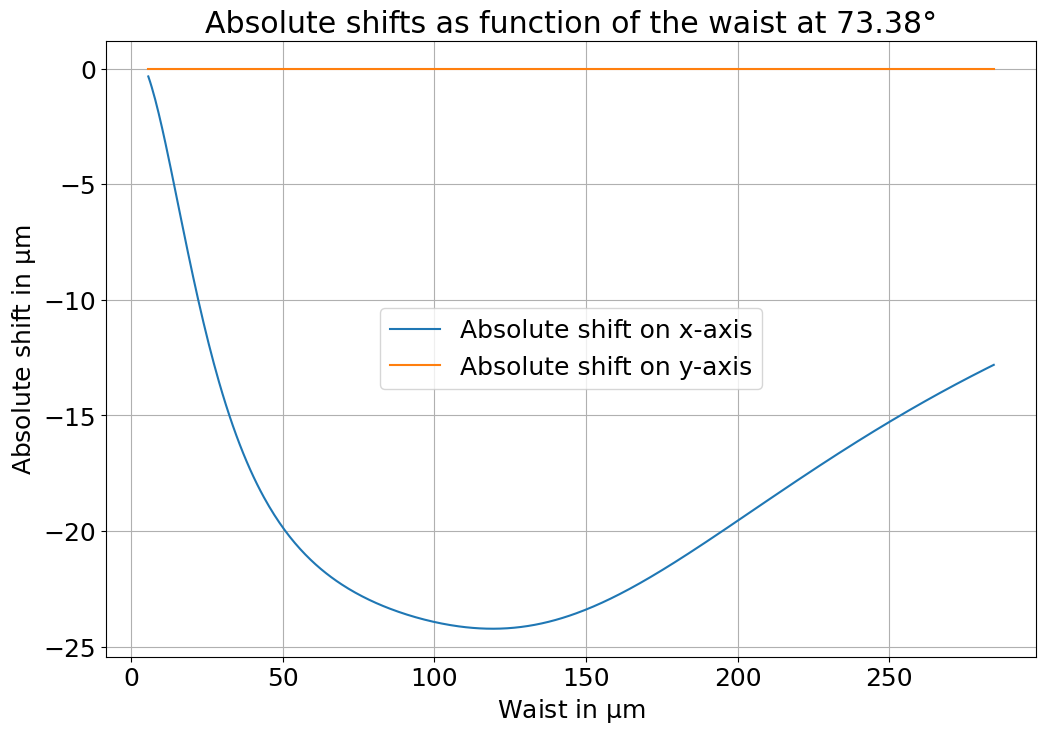

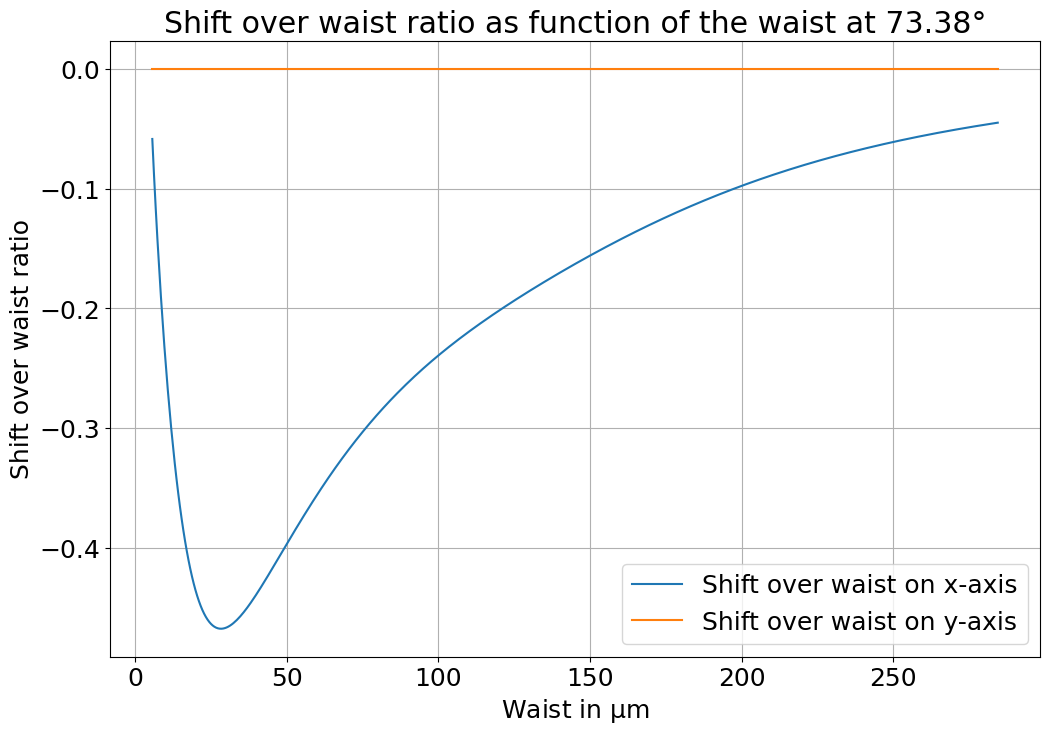

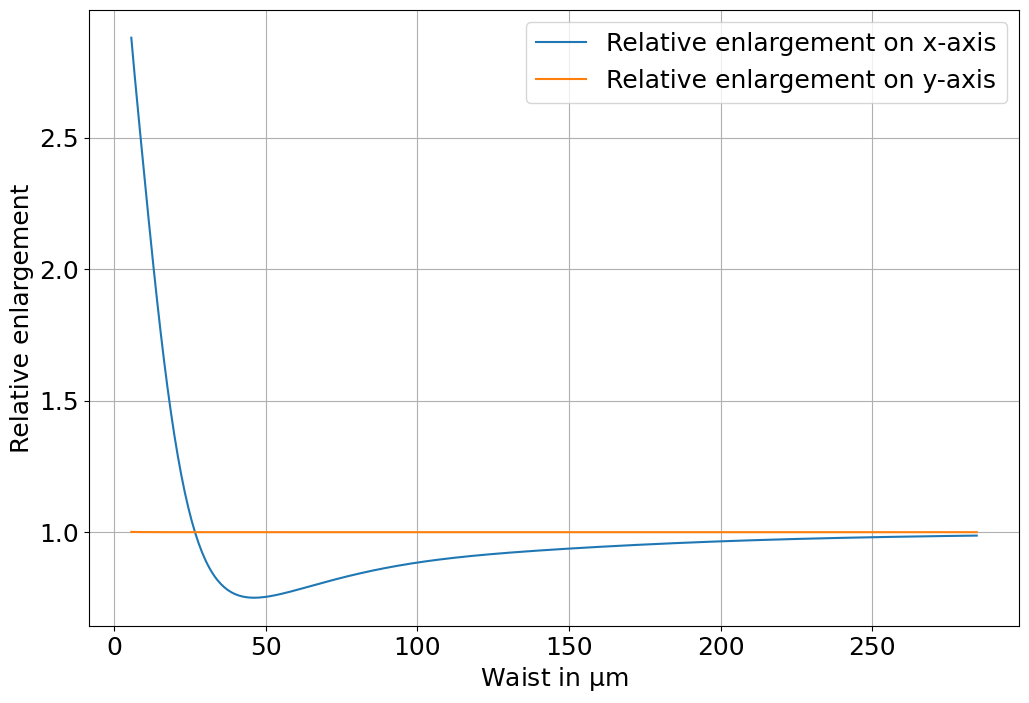

In [5]:
plt.figure(figsize=(12,8))
plt.plot(w_range/1000, np.array(DECx)/1000, label="Absolute shift on x-axis")
plt.plot(w_range/1000, np.array(DECy)/1000, label="Absolute shift on y-axis")
plt.title(f"Absolute shifts as function of the waist at {inc}°")
plt.xlabel(r"Waist in $\mathrm{\mu m}$")
plt.ylabel(r"Absolute shift in $\mathrm{\mu m}$")
plt.grid()
plt.legend()
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/optimisation/absolute_shifts_f_w.{file_ext}", bbox_inches="tight")

plt.figure(figsize=(12,8))
plt.plot(w_range/1000, (np.array(DECx)/1000)/(w_range/1000), label="Shift over waist on x-axis")
plt.plot(w_range/1000, (np.array(DECy)/1000)/(w_range/1000), label="Shift over waist on y-axis")
plt.title(f"Shift over waist ratio as function of the waist at {inc}°")
plt.xlabel(r"Waist in $\mathrm{\mu m}$")
plt.ylabel("Shift over waist ratio")
plt.grid()
plt.legend()
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/optimisation/shifts_over_w_f_w.{file_ext}", bbox_inches="tight")
    
plt.figure(figsize=(12,8))
plt.plot(w_range/1000, ELx, label="Relative enlargement on x-axis")
plt.plot(w_range/1000, ELy, label="Relative enlargement on y-axis")
# plt.title(f"Relative enlargements vs waist ({inc}° incidence)")
plt.xlabel(r"Waist in $\mathrm{\mu m}$")
plt.ylabel("Relative enlargement")
plt.grid()
plt.legend();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/optimisation/rel_enlargement_f_w.{file_ext}", bbox_inches="tight")

w_best=w_range[np.argmin(ELx)]
print(f"The waist that maximize the beam narrowing is {w_best} with a relative enlargement of {np.min(ELx)}")

### Optimal incidence determination

The optimal incidence is determined on the same principle as the optimal waist, but here the reflection coefficients must be redetermined for each angle.

In [6]:
# initialisation of the needed parameters, other than the incidence,
n1 = 1 # air refractive index
n2 = 1.515  # glass refractive index
wavelength = 632.8
k0 = 2 * np.pi / wavelength
N = 100
alpha0 = 0
beta0 = 0
x0 = 0
y0 = 0
w = w_best
wx = w
wy = w
d = 400000

# the x and y-axes considered
x = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
y = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
# grids of the axes
X, Y = np.meshgrid(x, y)

# definition of the spectral grid
pask = 2 * np.pi / d  # definition of the spectral step
a = np.arange(-N, N + 1) * pask  # alpha (kx) range in nm-1
b = a  # beta (ky) range in nm-1
A, B = np.meshgrid(a, b)  # alpha and beta grid

# definition of the structure on which the reflection is done
# get the material from refractiveindex database (RII) when possible
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, 47, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)

Determination of the enlargements (and other quantities) as function of the incidence angle.

In [9]:
inc_range=np.linspace(70.5,74.5, int((74.5-70.5)/0.01)+1) # range of incidence considered
# inc_range=np.linspace(55,85, int((85-55)/0.01)+1) # range of incidence considered

# function to use in multiprocessing (CPU)
def process_inc(structure, wavelength, inc, w, A, B, X, Y, x, y):
    k0 = 2 * np.pi / wavelength
    n2 = 1.515
    kz = np.sqrt((n2 * k0)**2 - A**2 - B**2)

    theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc)))**2 + B**2) / (n2 * k0))

    cr = np.zeros_like(A, dtype=complex)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            r, t, R, T = PM.coefficient(structure, wavelength, theta[i, j], 1)
            cr[i, j] = r
            if (i == N and j == N):
                R_central = R  # Store the reflectivity for the central plane wave
    wx=w
    wy=w
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0) # spatial beam before reflection
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
    U1ki=cr*U1k # spectral beam after reflection
    U1i=ifft2(U1ki) # spatial beam after reflection
    # determination of the barycentre of the beam on x and y for the incoming and the reflected beam
    bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    # determination of the shift
    decx=bxU1i-bxU1
    decy=byU1i-byU1
    # determination of the enlargement (in absolute and relative form)
    elarrelatx = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
    elarrelaty = (trapezoid(trapezoid(((Y - decy)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((Y**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
    # save of the shifts and enlargements
    return inc, elarrelatx, elarrelaty, decx, decy, R_central

# parallel computation (on inc)
results = Parallel(n_jobs=n_jobs, backend="loky")(delayed(process_inc)(structure, wavelength, inc, w, A, B, X, Y, x, y) for inc in tqdm(inc_range, desc="Scan of all the incidences"))

# build the final arrays
ELx = np.zeros((len(inc_range)))
ELy = np.zeros((len(inc_range)))
DECx = np.zeros((len(inc_range)))
DECy = np.zeros((len(inc_range)))
R_central = np.zeros((len(inc_range)))

inc_index = {val: idx for idx, val in enumerate(inc_range)}

for inc, ELx_val, ELy_val, DECx_val, DECy_val, R_val in results:
    i = inc_index[inc]
    ELx[i] = ELx_val
    ELy[i] = ELy_val
    DECx[i] =DECx_val
    DECy[i] =DECy_val
    R_central[i] = R_val
    


Scan of all the incidences: 100%|██████████| 401/401 [01:35<00:00,  4.20it/s]


Plot of the results.

The incidence that maximize the beam narrowing is 73.38 with a relative enlargement of 0.75083741996639


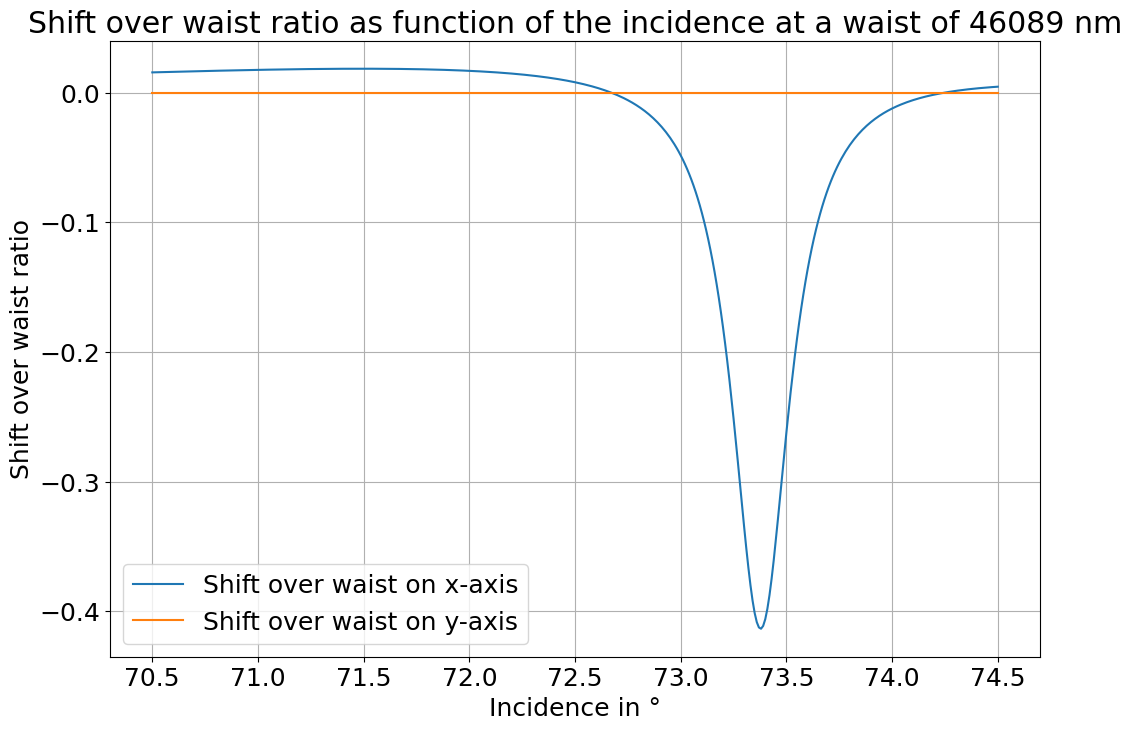

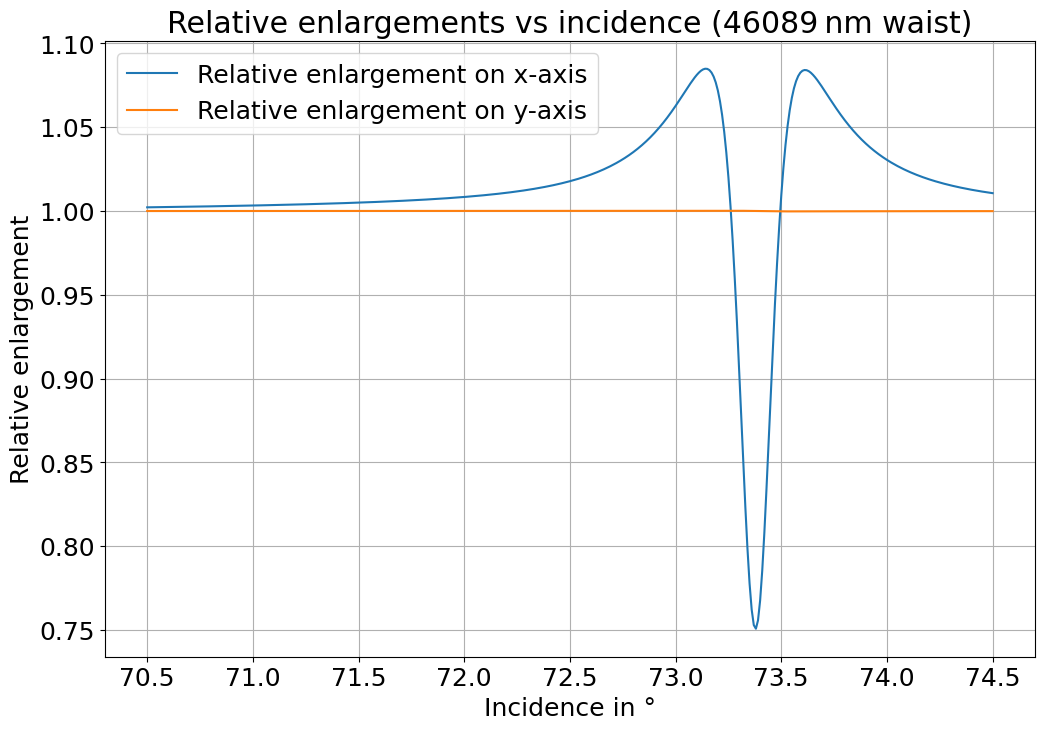

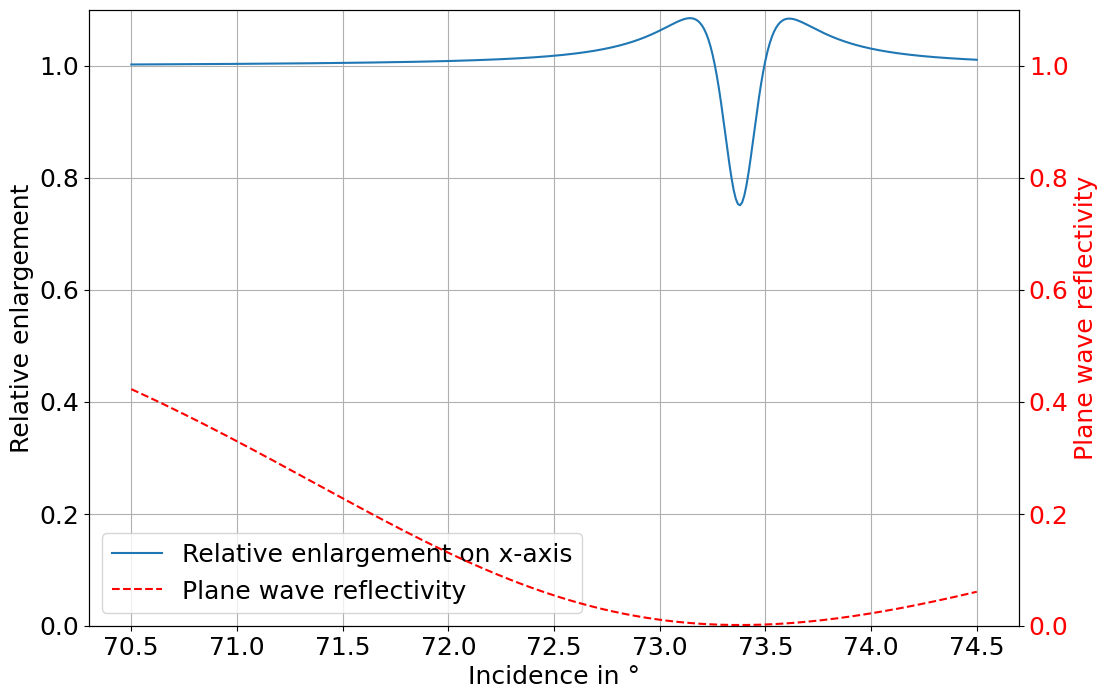

In [10]:
plt.figure(figsize=(12,8))
plt.plot(inc_range, DECx/w, label="Shift over waist on x-axis")
plt.plot(inc_range, DECy/w, label="Shift over waist on y-axis")
plt.title(f"Shift over waist ratio as function of the incidence at a waist of {w:.0f} nm")
plt.xlabel("Incidence in °")
plt.ylabel("Shift over waist ratio")
plt.grid()
plt.legend()
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/optimisation/shifts_over_w_f_inc.{file_ext}", bbox_inches="tight")

plt.figure(figsize=(12,8))
plt.plot(inc_range, ELx, label="Relative enlargement on x-axis")
plt.plot(inc_range, ELy, label="Relative enlargement on y-axis")
plt.title(f"Relative enlargements vs incidence ({w:.0f} nm waist)")
plt.xlabel("Incidence in °")
plt.ylabel("Relative enlargement")
plt.grid()
plt.legend();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/optimisation/rel_enlargement_f_inc.{file_ext}", bbox_inches="tight")

incidence_best=inc_range[np.argmin(ELx)]
print(f"The incidence that maximize the beam narrowing is {incidence_best} with a relative enlargement of {np.min(ELx)}")

fig, ax1 = plt.subplots(figsize=(12, 8))
ax1.plot(inc_range, ELx, label="Relative enlargement on x-axis")
# ax1.plot(inc_range, ELy, label="Relative enlargement on y-axis")
ax1.set_ylim(0,1.1)
ax1.set_xlabel("Incidence in °")
ax1.set_ylabel("Relative enlargement")
ax1.grid()
ax2 = ax1.twinx()
ax2.plot(inc_range, R_central, 'r--', label="Plane wave reflectivity")
ax2.set_ylim(0,1.1)
ax2.set_ylabel("Plane wave reflectivity", color='r')
ax2.tick_params(axis='y', labelcolor='r')
# plt.title(f"Relative enlargements vs incidence ({w:.0f} nm waist)")
# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2);
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/optimisation/rel_enlargement_and_R_f_inc.{file_ext}", bbox_inches="tight")

### Check : optimal waist and angle together

Here the two parameters are varying together in order to check the single optimisation results.

In [11]:
# initialisation of the needed parameters, other than the incidence,
n1 = 1 # air refractive index
n2 = 1.515  # glass refractive index
wavelength = 632.8
k0 = 2 * np.pi / wavelength
N = 100
alpha0 = 0
beta0 = 0
x0 = 0
y0 = 0
d = 400000

# the x and y-axes considered
x = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
y = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
# grids of the axes
X, Y = np.meshgrid(x, y)

# definition of the spectral grid
pask = 2 * np.pi / d  # definition of the spectral step
a = np.arange(-N, N + 1) * pask  # alpha (kx) range in nm-1
b = a  # beta (ky) range in nm-1
A, B = np.meshgrid(a, b)  # alpha and beta grid

# definition of the structure on which the reflection is done
# get the material from refractiveindex database (RII) when possible
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, 47, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)

Determination of the enlargement as function of both the incidence angle and the waist.

In [12]:
# function to use in multiprocessing (CPU)
def process_inc(structure, wavelength, inc, w_range, A, B, X, Y, x, y):
    k0 = 2 * np.pi / wavelength
    n2 = 1.515
    kz = np.sqrt((n2 * k0)**2 - A**2 - B**2)

    theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc)))**2 + B**2) / (n2 * k0))

    cr = np.zeros_like(A, dtype=complex)
    ELx = []
    ELy = []
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            r, t, R, T = PM.coefficient(structure, wavelength, theta[i, j], 1)
            cr[i, j] = r
    for w in w_range:
        wx=w
        wy=w
        U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0) # spatial beam before reflection
        U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
        U1ki=cr*U1k # spectral beam after reflection
        U1i=ifft2(U1ki) # spatial beam after reflection
        # determination of the barycentre of the beam on x and y for the incoming and the reflected beam
        bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
        byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
        bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
        byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
        # determination of the shift
        decx=bxU1i-bxU1
        decy=byU1i-byU1
        # determination of the enlargement (in absolute and relative form)
        elarrelatx = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
        elarrelaty = (trapezoid(trapezoid(((Y - decy)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((Y**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
        # save of the shifts and enlargements
        ELx.append(elarrelatx)
        ELy.append(elarrelaty)
        
    return inc, ELx, ELy

inc_range=np.linspace(70.5,74.5, int((74.5-70.5)/0.01)+1) # range of incidence considered
w_range = 5690 * np.linspace(1, 50, int((50-1)/0.1)+1)  # range of waist considered

# list of the saved quantities
ELx2D=[]
ELy2D=[]

# parallel computation (on inc)
results = Parallel(n_jobs=n_jobs, backend="loky")(delayed(process_inc)(structure, wavelength, inc, w_range, A, B, X, Y, x, y) for inc in tqdm(inc_range, desc="Scan of all the incidences"))
# build the relative enlargement maps
ELx2D = np.zeros((len(inc_range), len(w_range)))
ELy2D = np.zeros((len(inc_range), len(w_range)))

inc_index = {val: idx for idx, val in enumerate(inc_range)}

for inc, ELx_row, ELy_row in results:
    i = inc_index[inc]
    ELx2D[i, :] = ELx_row
    ELy2D[i, :] = ELy_row


Scan of all the incidences: 100%|██████████| 401/401 [02:43<00:00,  2.45it/s]


The incidence and waist which maximize the beam narrowing are 73.38° and 46089.00000000001 nm with a relative enlargement of 0.75083741996639


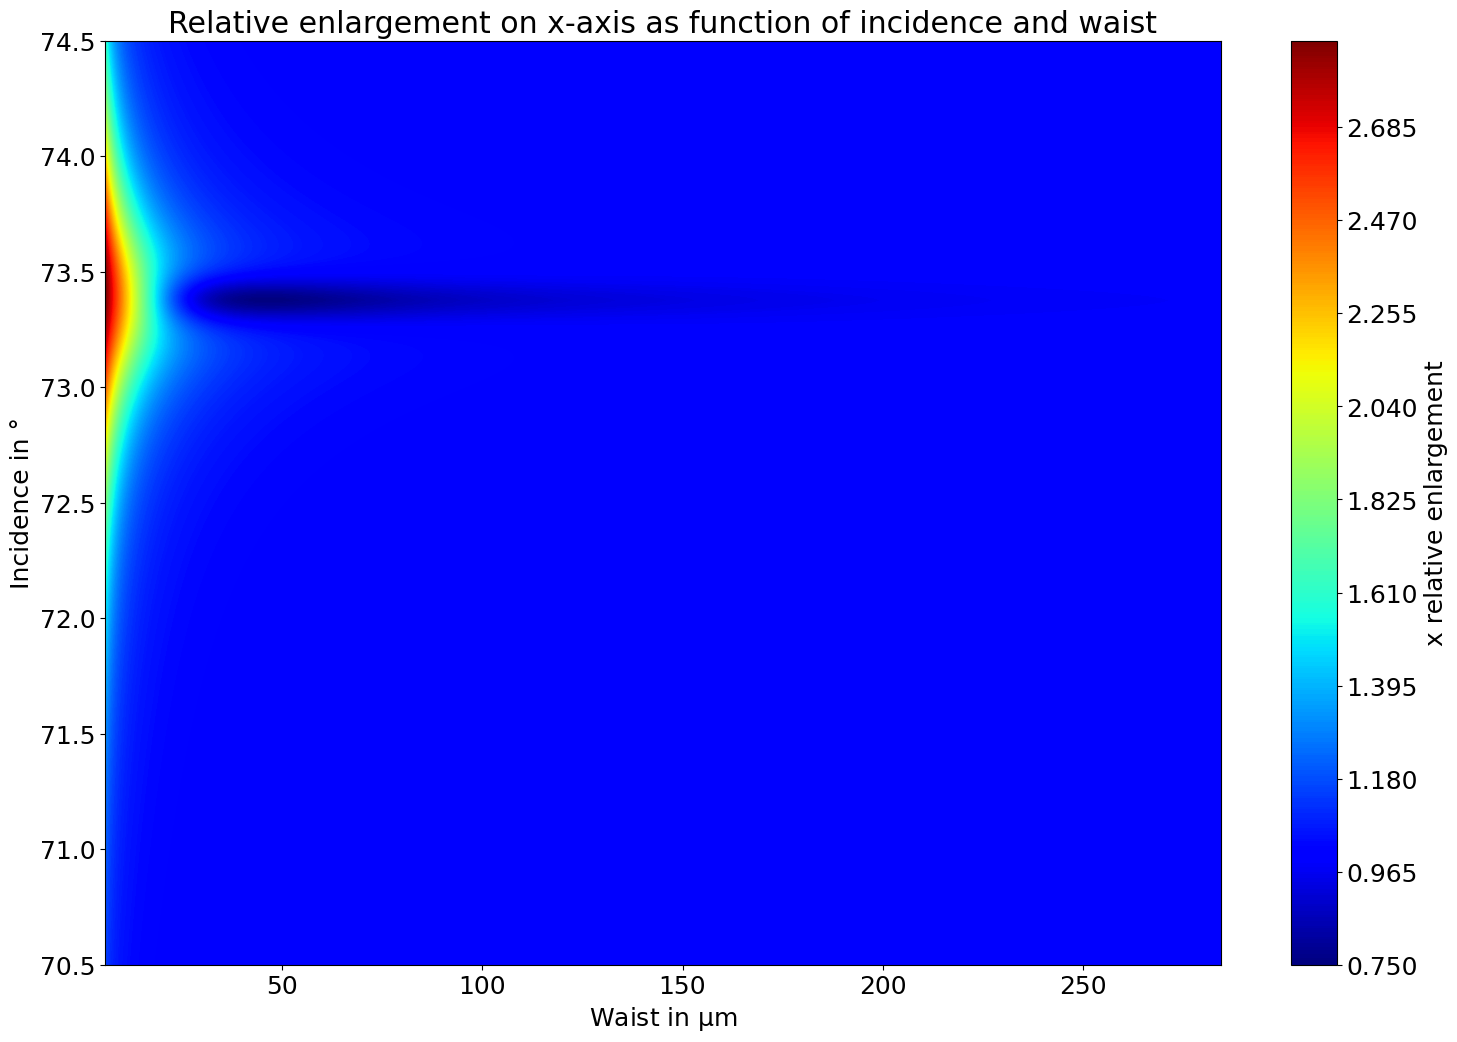

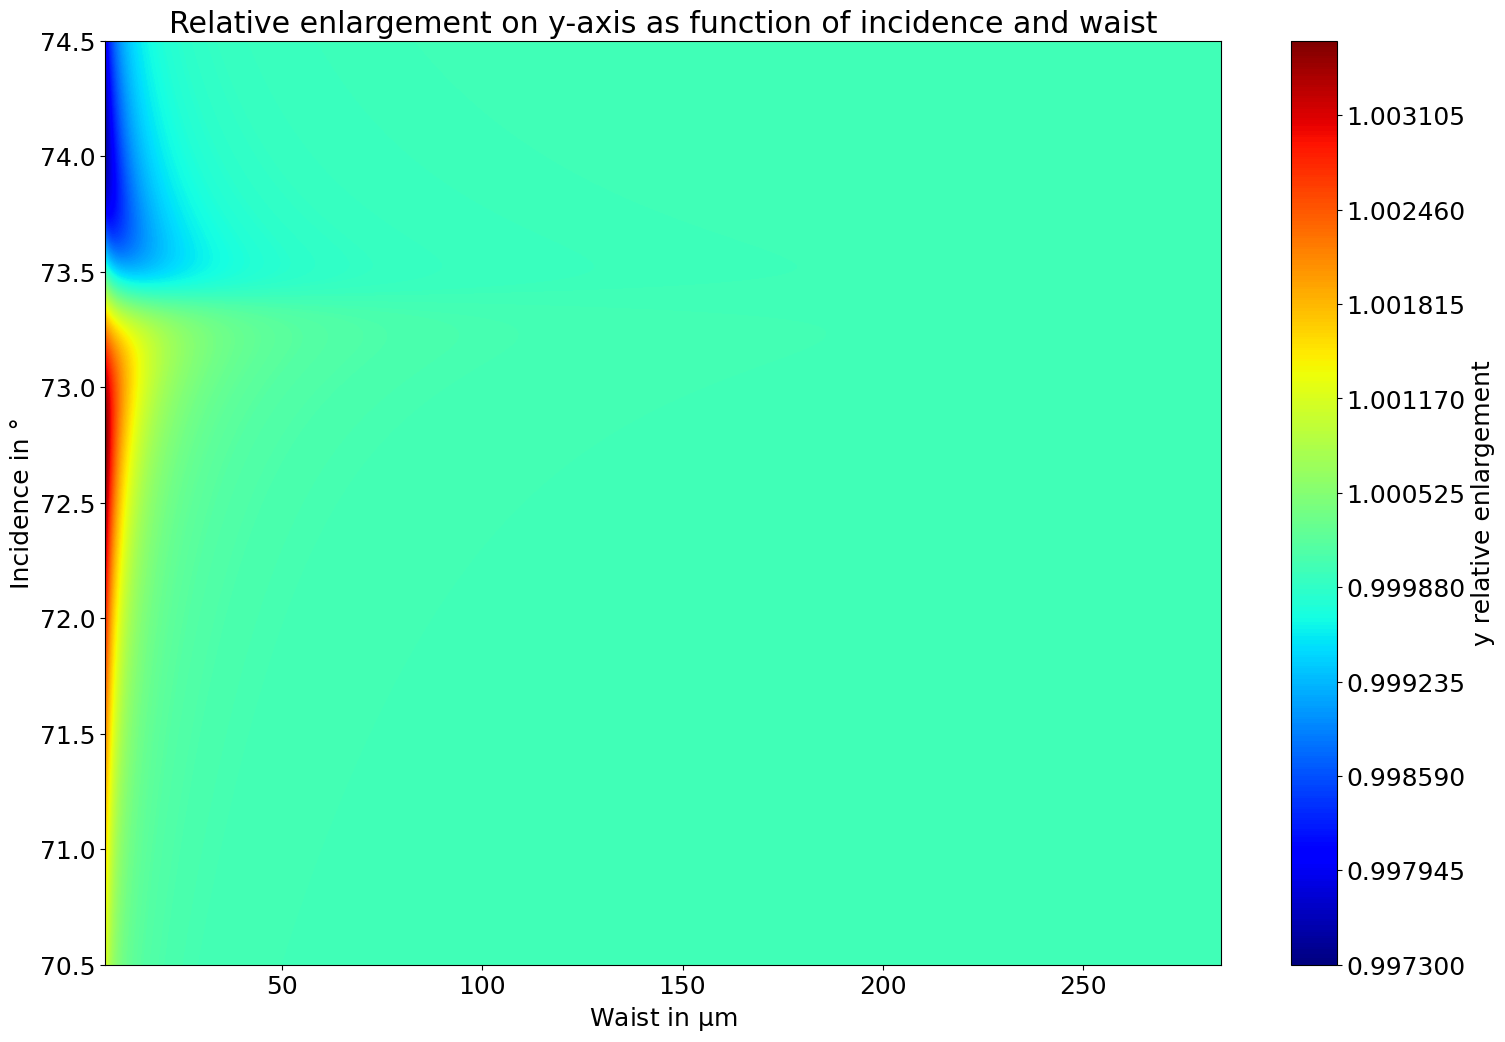

In [13]:
w_grid, inc_grid = np.meshgrid(w_range, inc_range)

fig = plt.figure(figsize=(18, 12))
ax1 = fig.add_subplot(111)
contour1 = ax1.contourf(w_grid/1000, inc_grid, np.array(ELx2D), levels=500, cmap="jet")
contour1.set_edgecolor("face")
cbar1 = fig.colorbar(contour1, ax=ax1)
cbar1.set_label("x relative enlargement")
ax1.set_ylabel("Incidence in °")
ax1.set_xlabel(r"Waist in $\mathrm{\mu m}$")
ax1.set_title("Relative enlargement on x-axis as function of incidence and waist")
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/optimisation/x_rel_enlargement_f_inc_and_w.{file_ext}", bbox_inches="tight")

fig = plt.figure(figsize=(18, 12))
ax2 = fig.add_subplot(111)
contour2 = ax2.contourf(w_grid/1000,inc_grid, np.array(ELy2D), levels=500, cmap="jet")
contour2.set_edgecolor("face")
cbar2 = fig.colorbar(contour2, ax=ax2)
cbar2.set_label("y relative enlargement")
ax2.set_ylabel("Incidence in °")
ax2.set_xlabel(r"Waist in $\mathrm{\mu m}$")
ax2.set_title("Relative enlargement on y-axis as function of incidence and waist")
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/optimisation/y_rel_enlargement_f_inc_and_w.{file_ext}", bbox_inches="tight")

index_best_inc, index_best_w = np.unravel_index(np.argmin(np.array(ELx2D)), np.array(ELx2D).shape)

print(f"The incidence and waist which maximize the beam narrowing are {inc_grid[index_best_inc,index_best_w]}° and {w_grid[index_best_inc,index_best_w]} nm with a relative enlargement of {np.min(ELx2D)}")

### Optimal gold layer thickness

Here the optimal gold layer thickness is determined by  comparing the best enlargement associated to each configuration (from a scan on the incidence angle and the waist together).

Scan of all the incidences: 100%|██████████| 401/401 [02:53<00:00,  2.31it/s]


20 nm of gold: the incidence and waist which maximize the beam narrowing are 71.37° and 3414.0 nm with a relative enlargement of 0.9676325220677467


Scan of all the incidences: 100%|██████████| 401/401 [02:51<00:00,  2.34it/s]


25 nm of gold: the incidence and waist which maximize the beam narrowing are 71.82° and 3414.0 nm with a relative enlargement of 0.9402600258193905


Scan of all the incidences: 100%|██████████| 401/401 [02:54<00:00,  2.29it/s]


...

49 nm of gold: the incidence and waist which maximize the beam narrowing are 73.46° and 17070.0 nm with a relative enlargement of 0.7556582743301751


Scan of all the incidences: 100%|██████████| 401/401 [02:54<00:00,  2.29it/s]


50 nm of gold: the incidence and waist which maximize the beam narrowing are 73.49° and 13087.0 nm with a relative enlargement of 0.7595329869044157


Scan of all the incidences: 100%|██████████| 401/401 [02:57<00:00,  2.26it/s]


55 nm of gold: the incidence and waist which maximize the beam narrowing are 73.68° and 6828.0 nm with a relative enlargement of 0.788715171213298


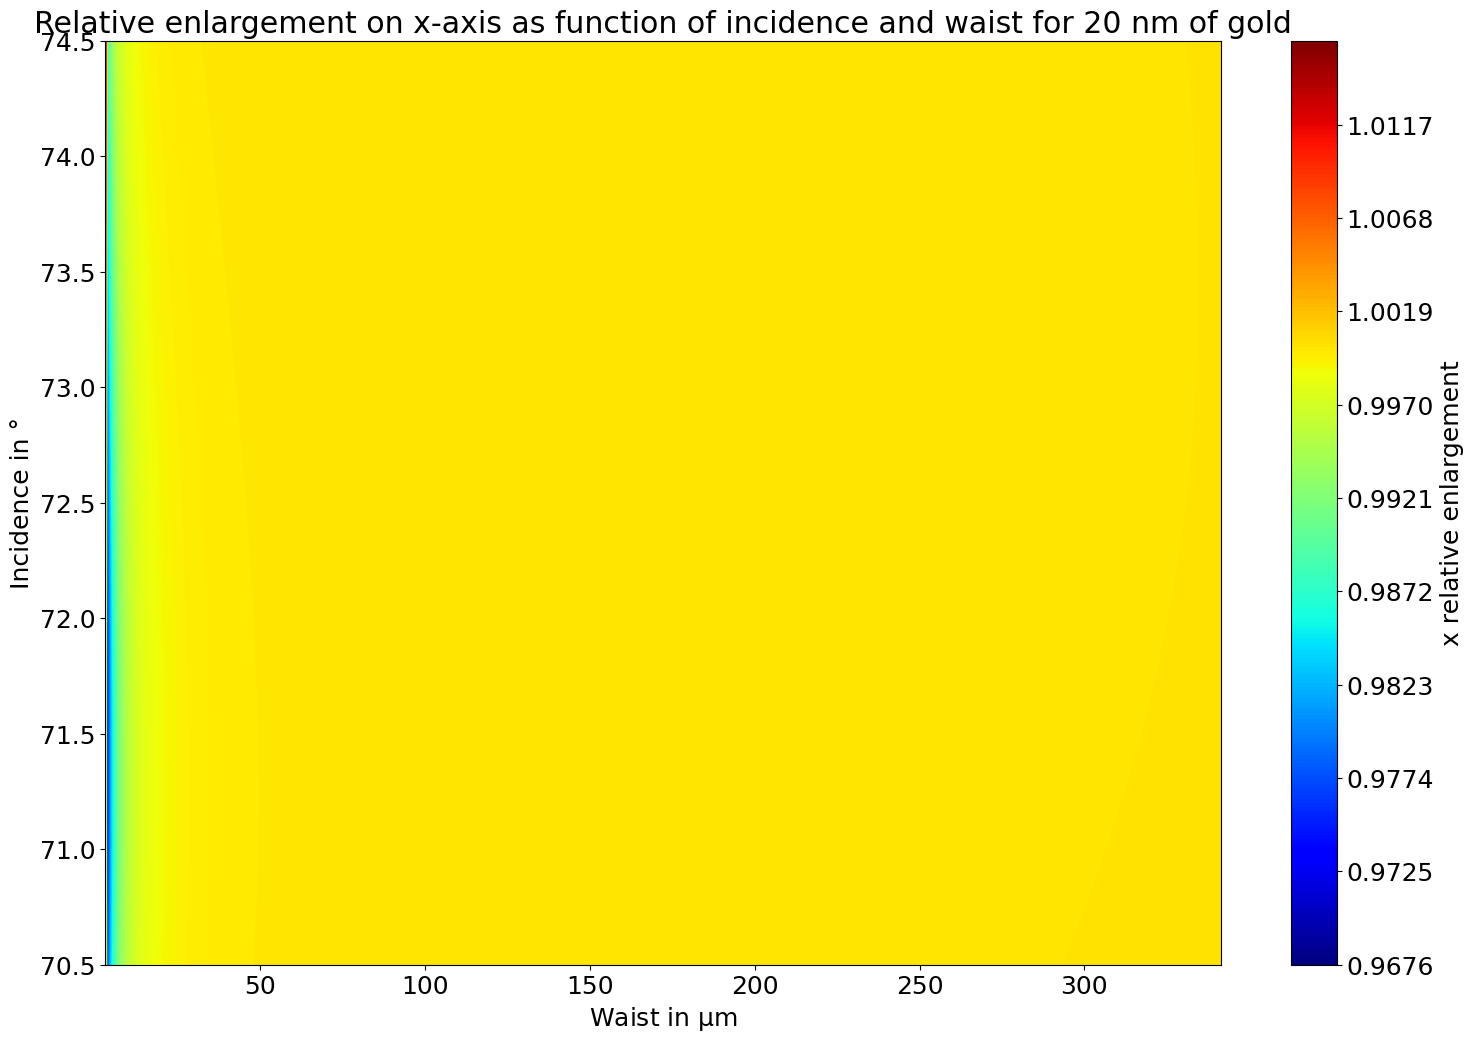

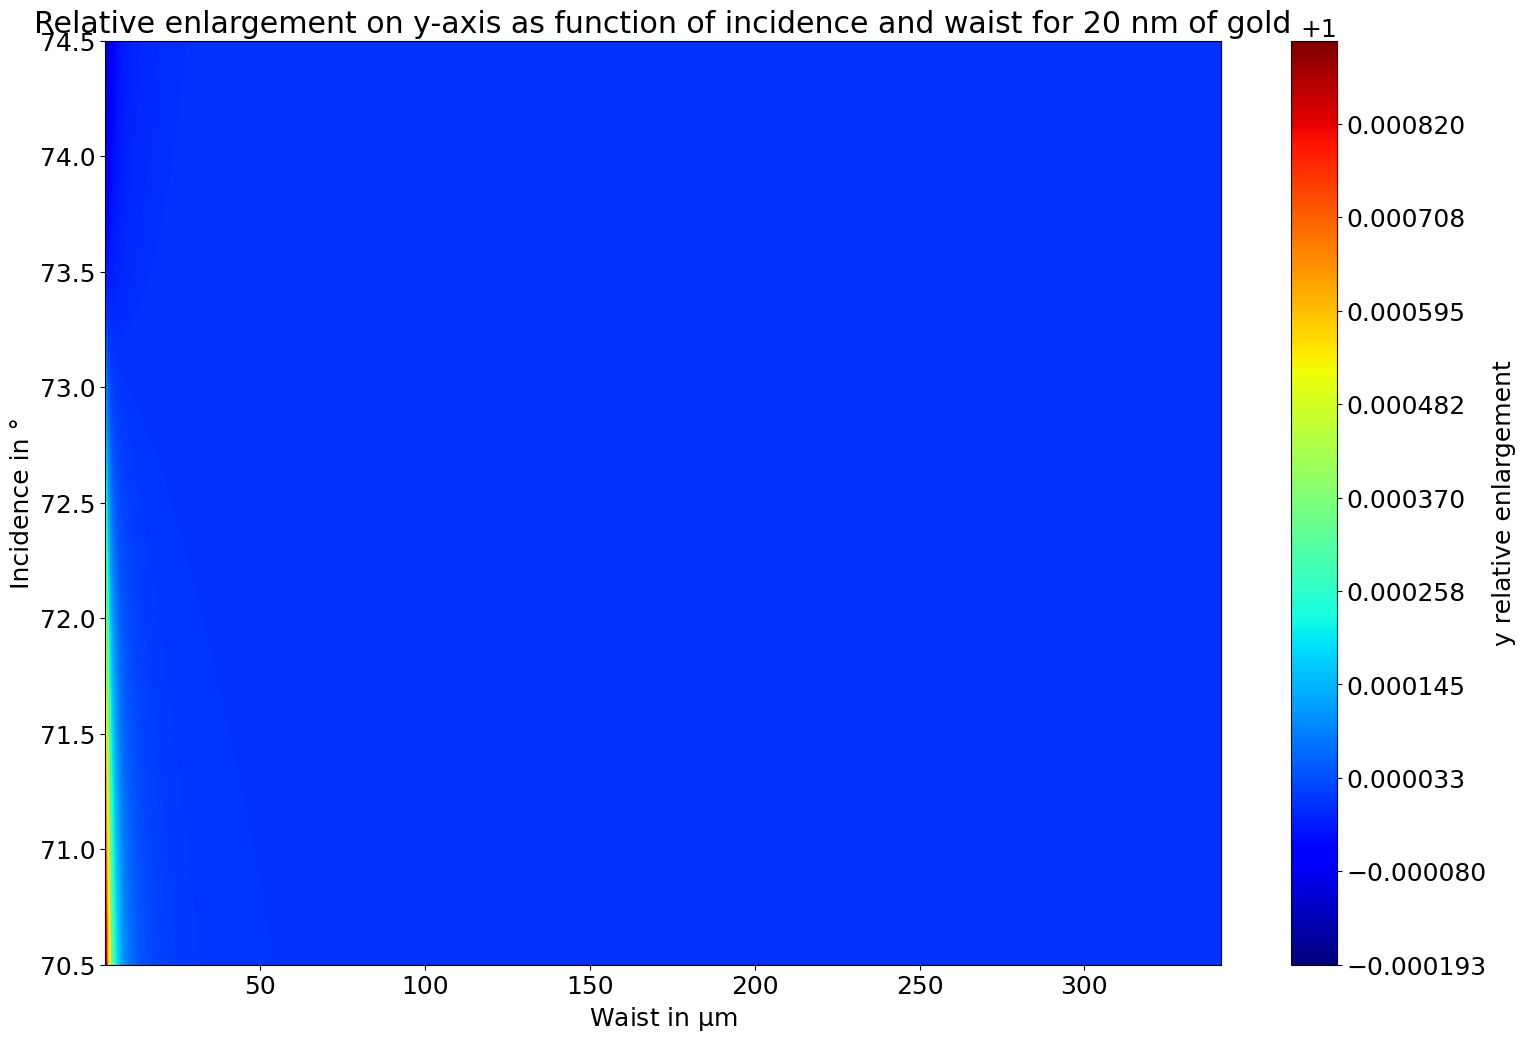

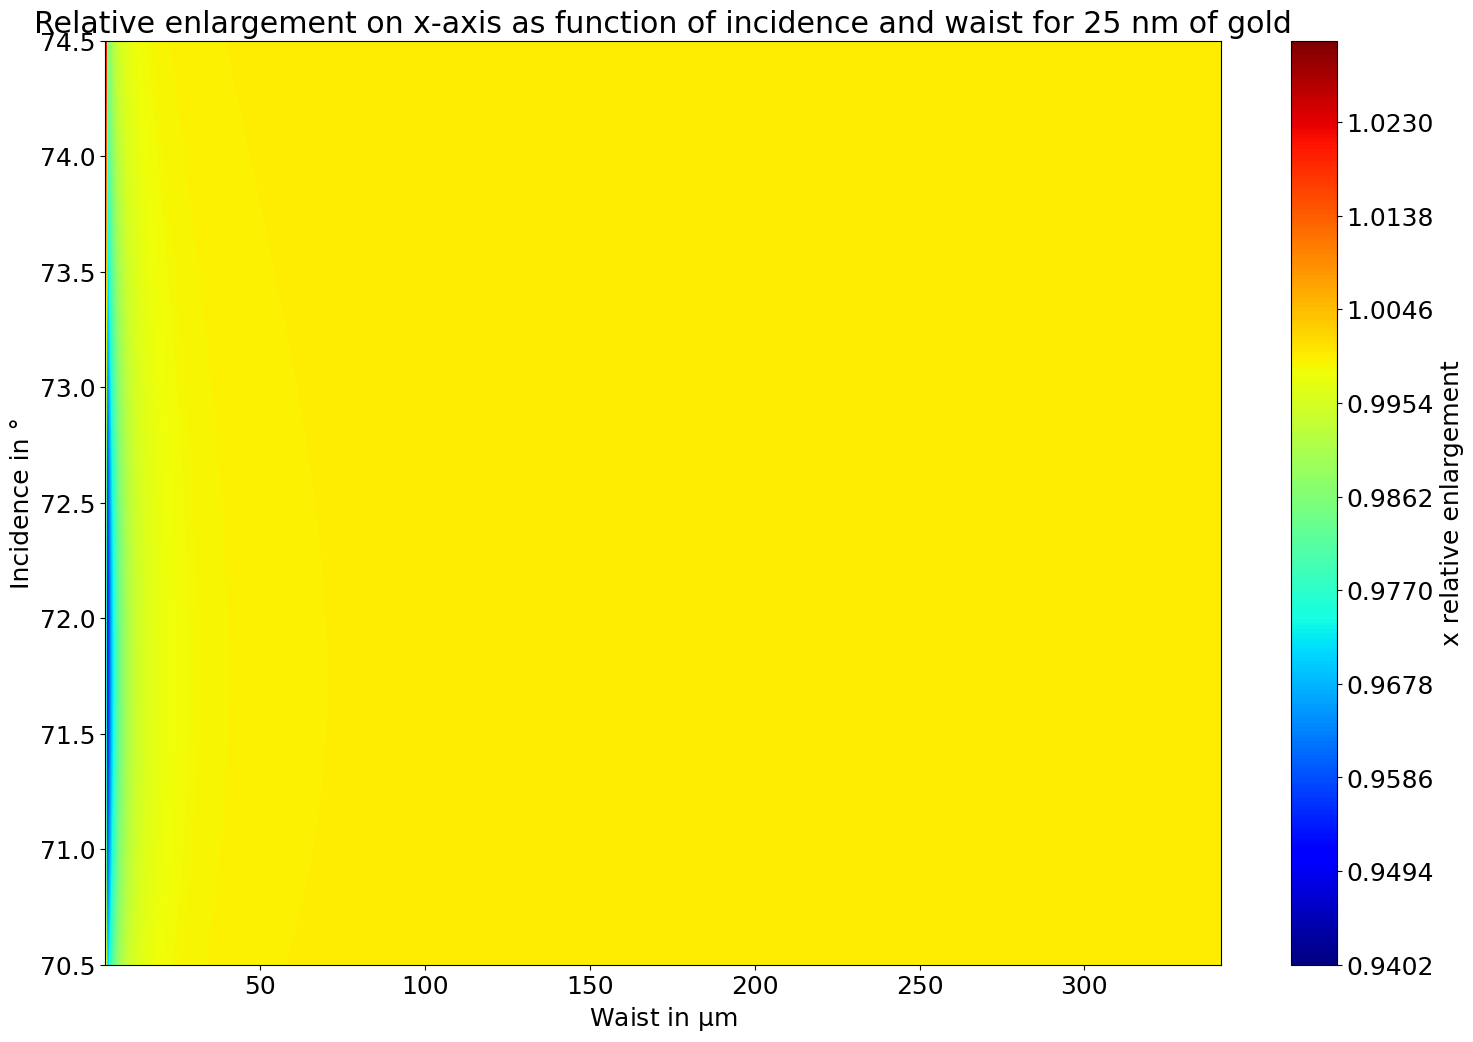

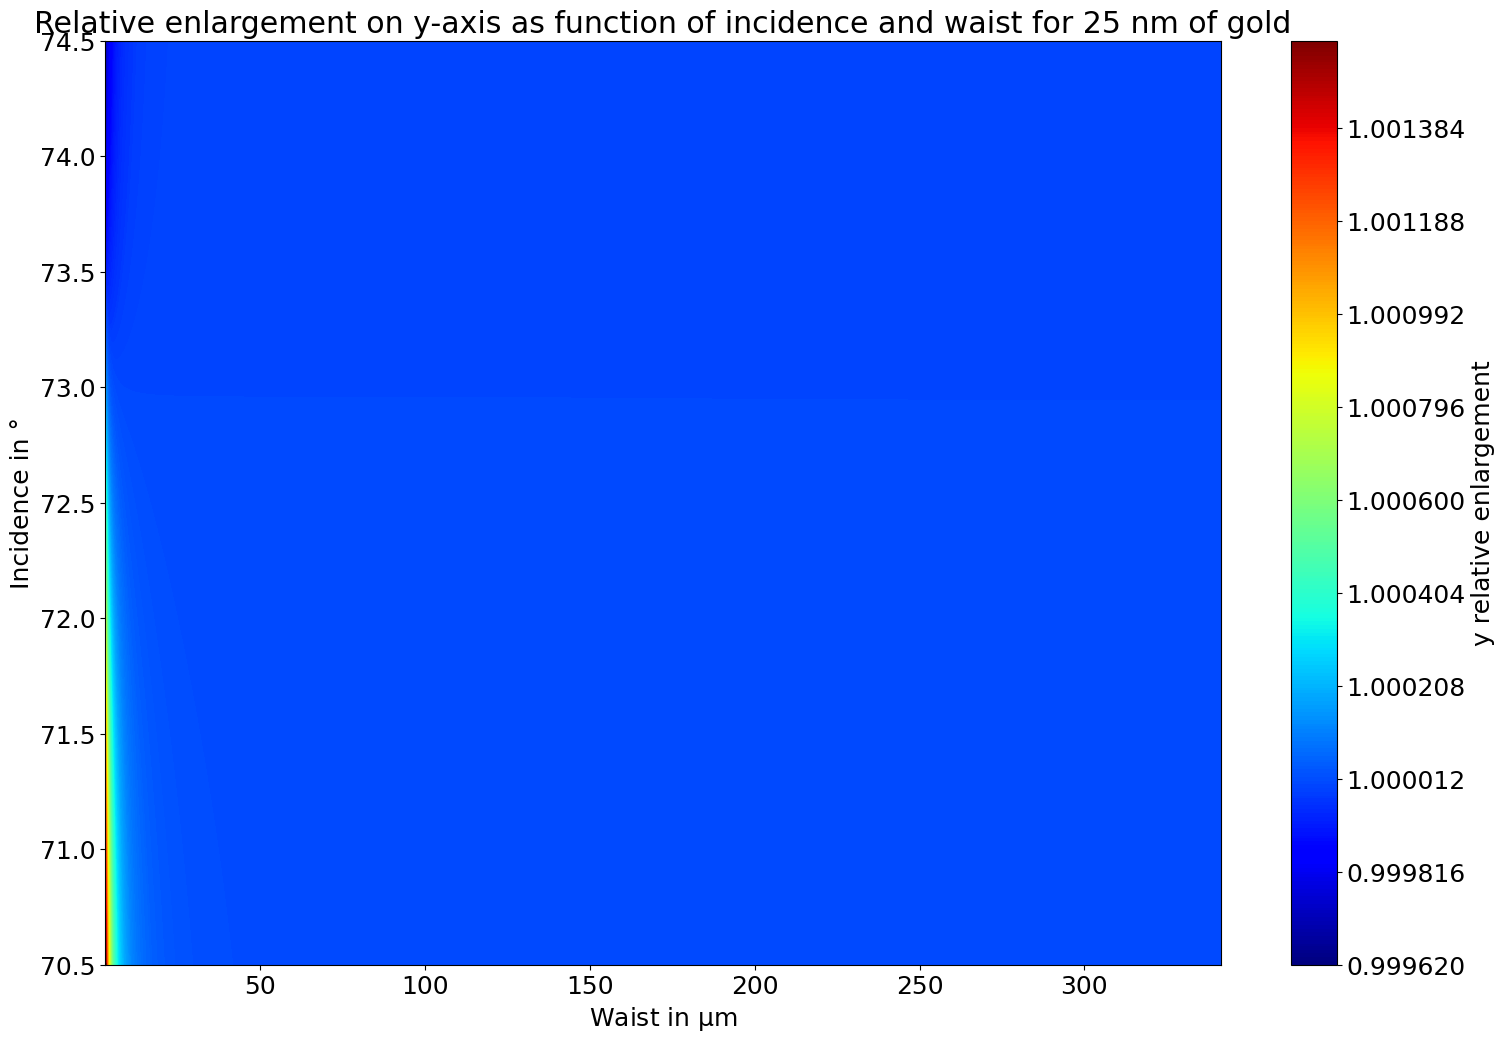

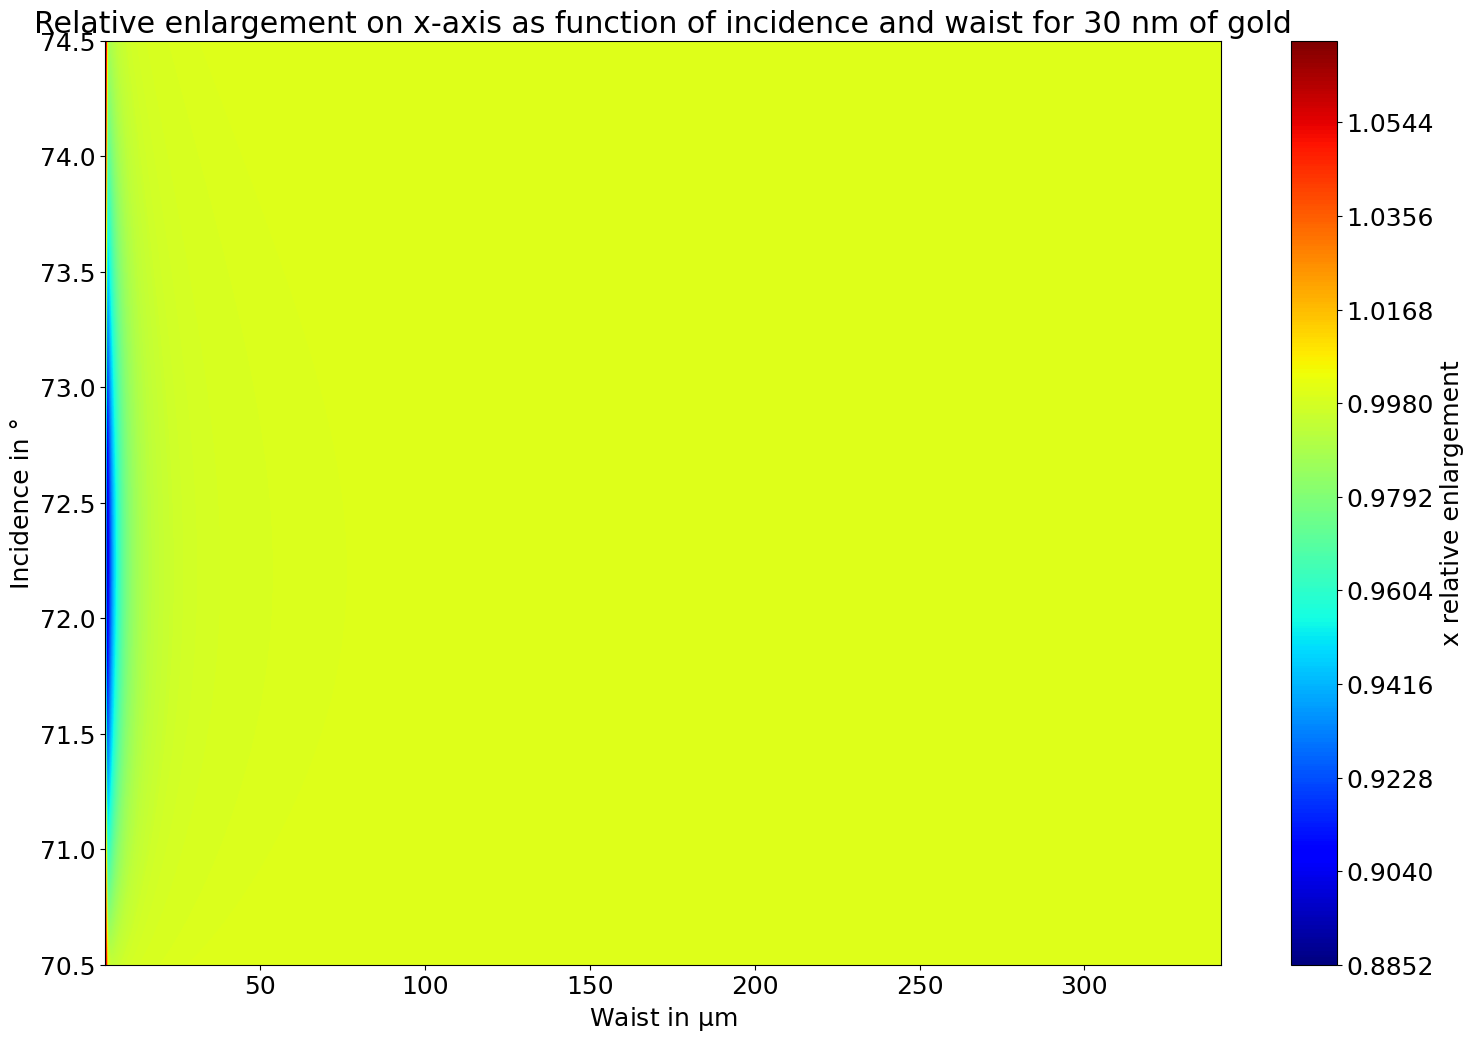

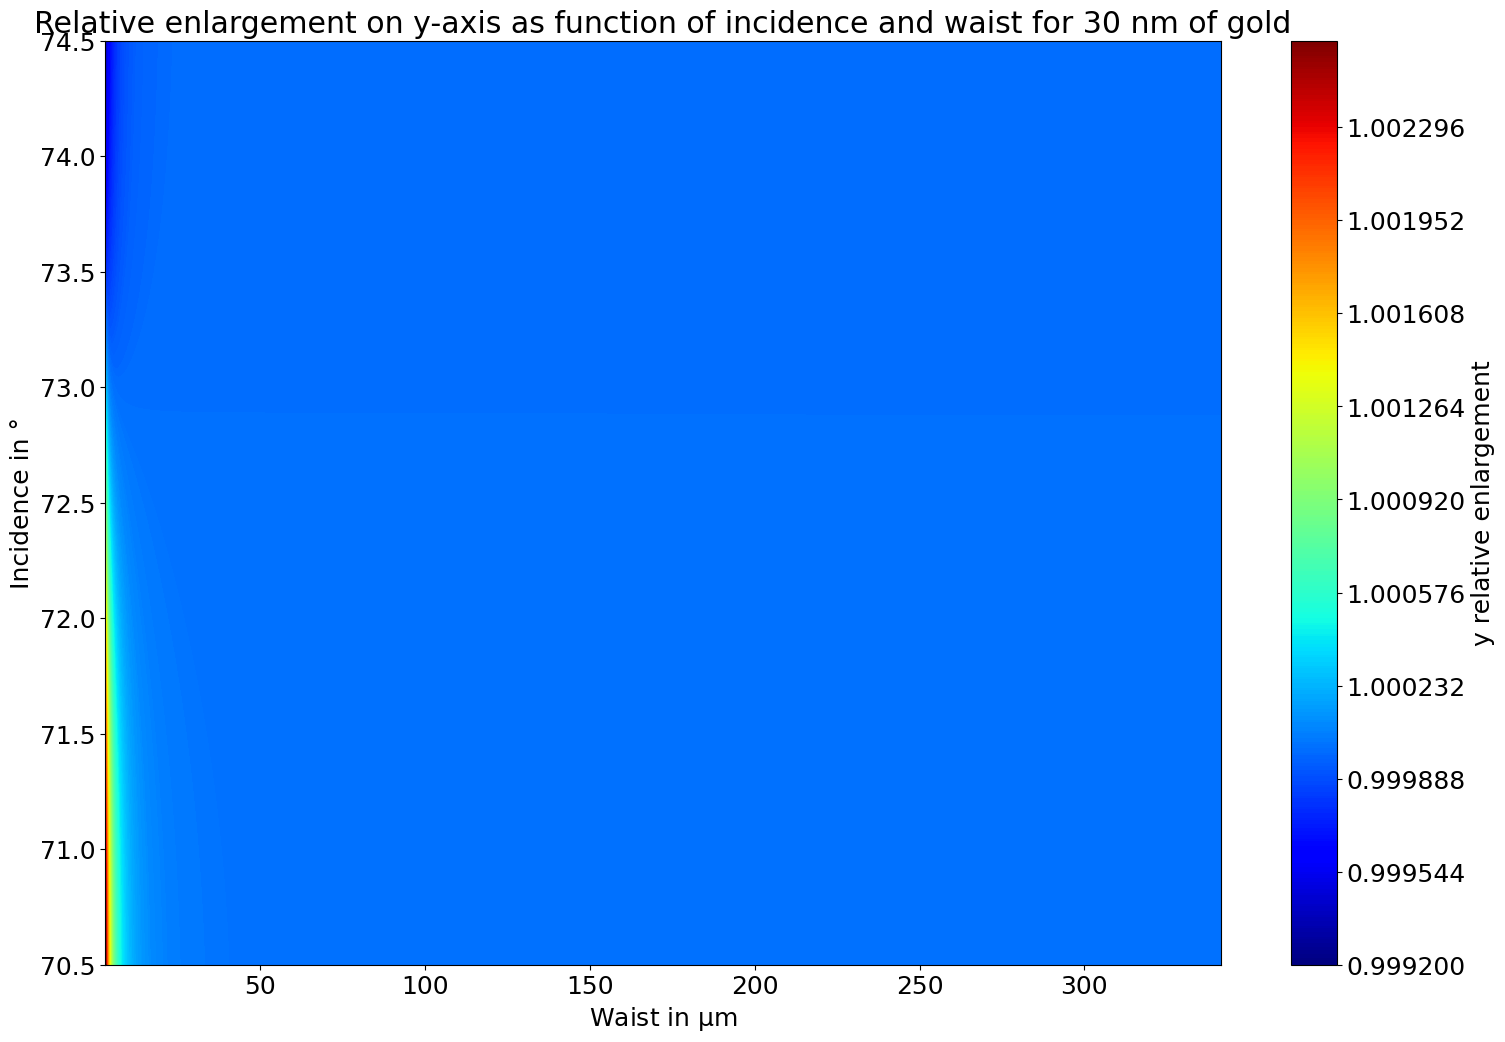

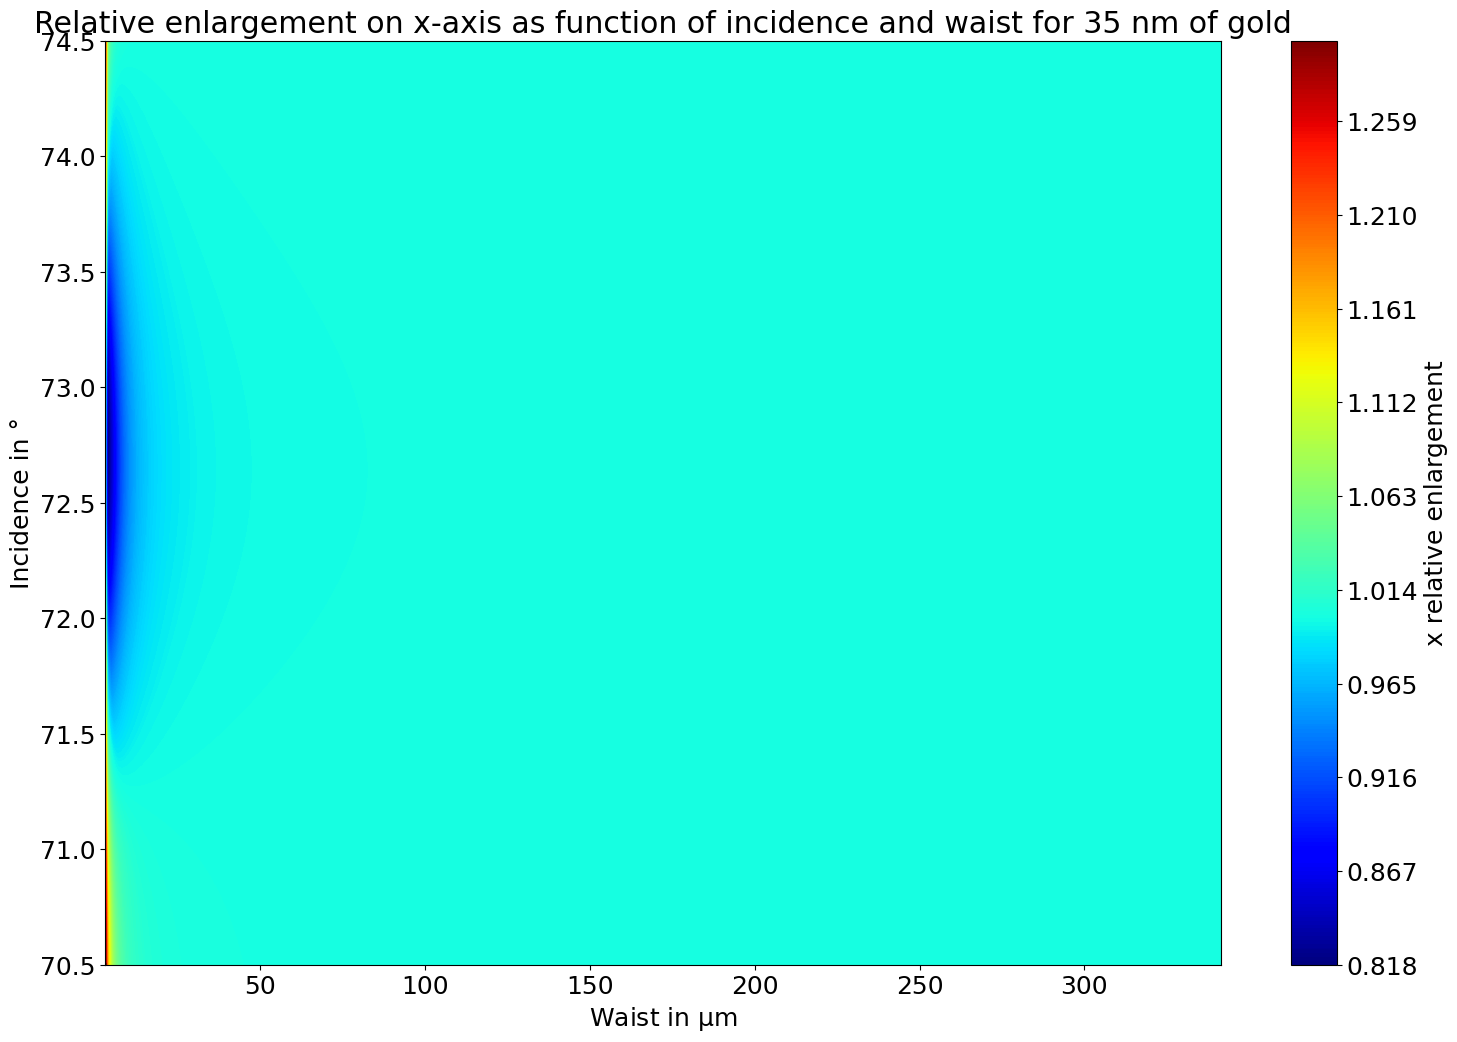

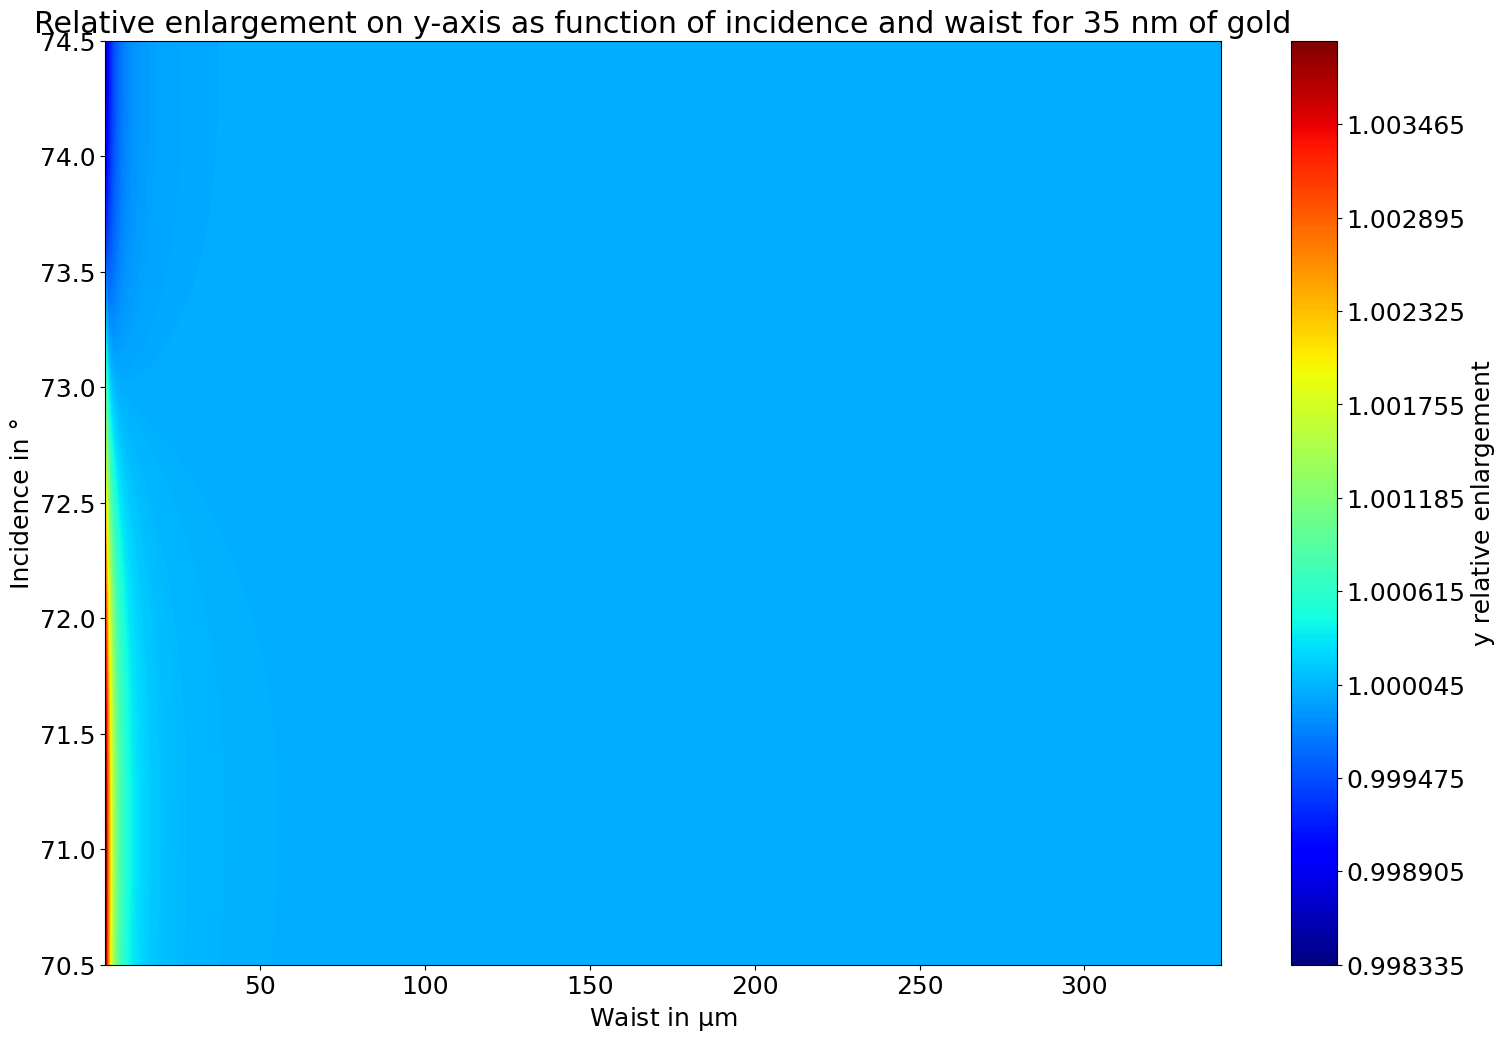

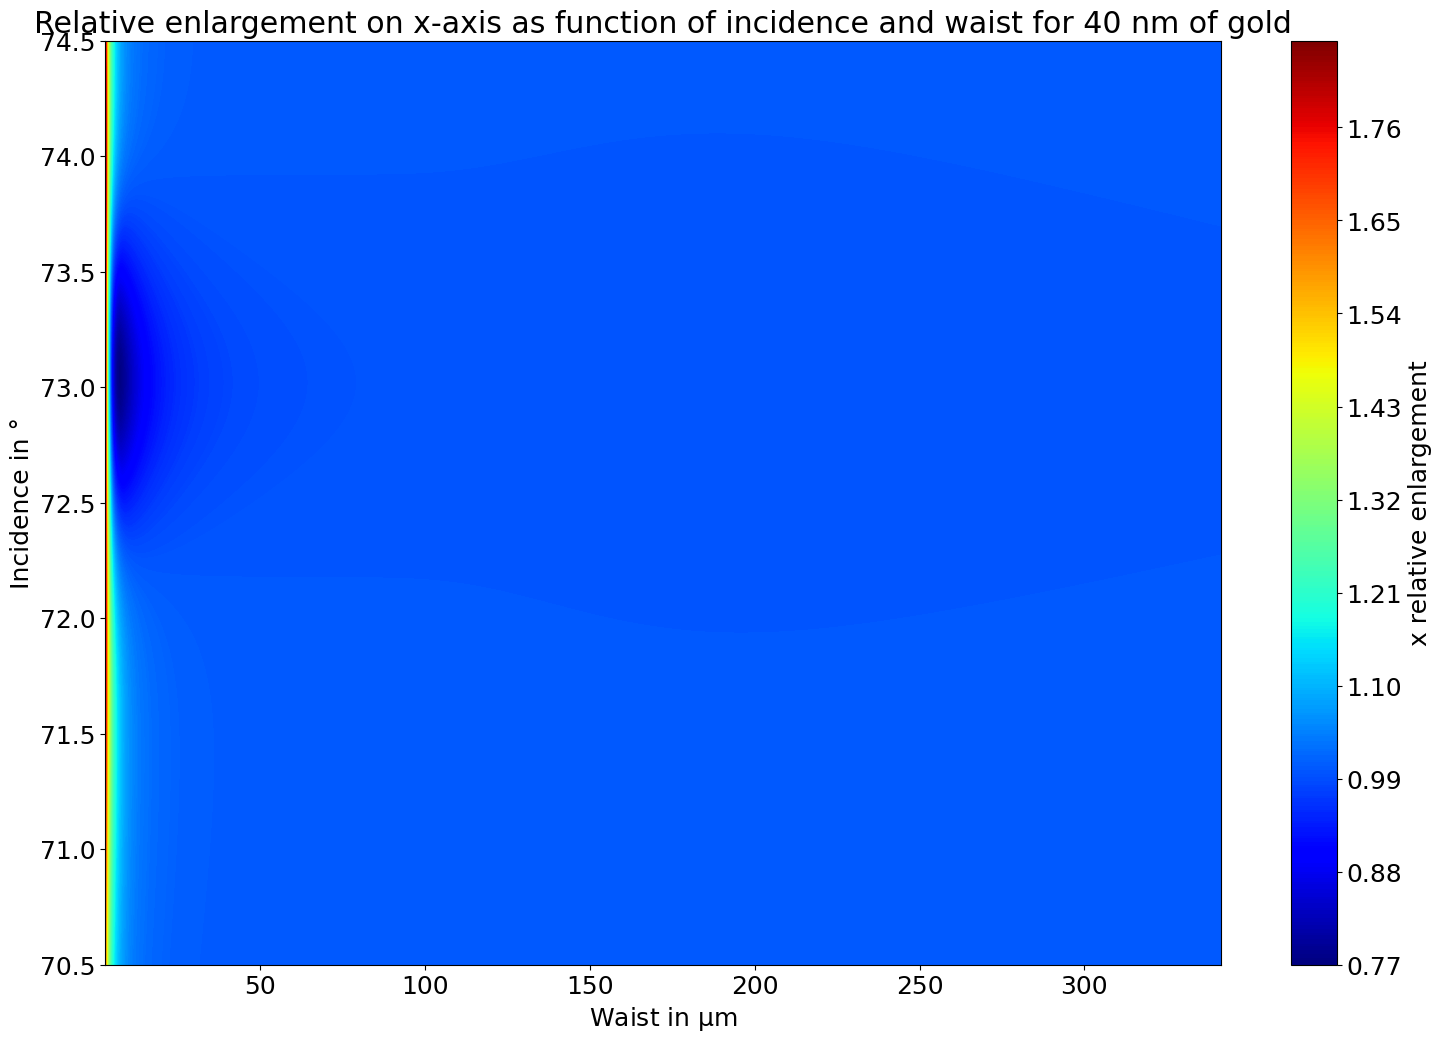

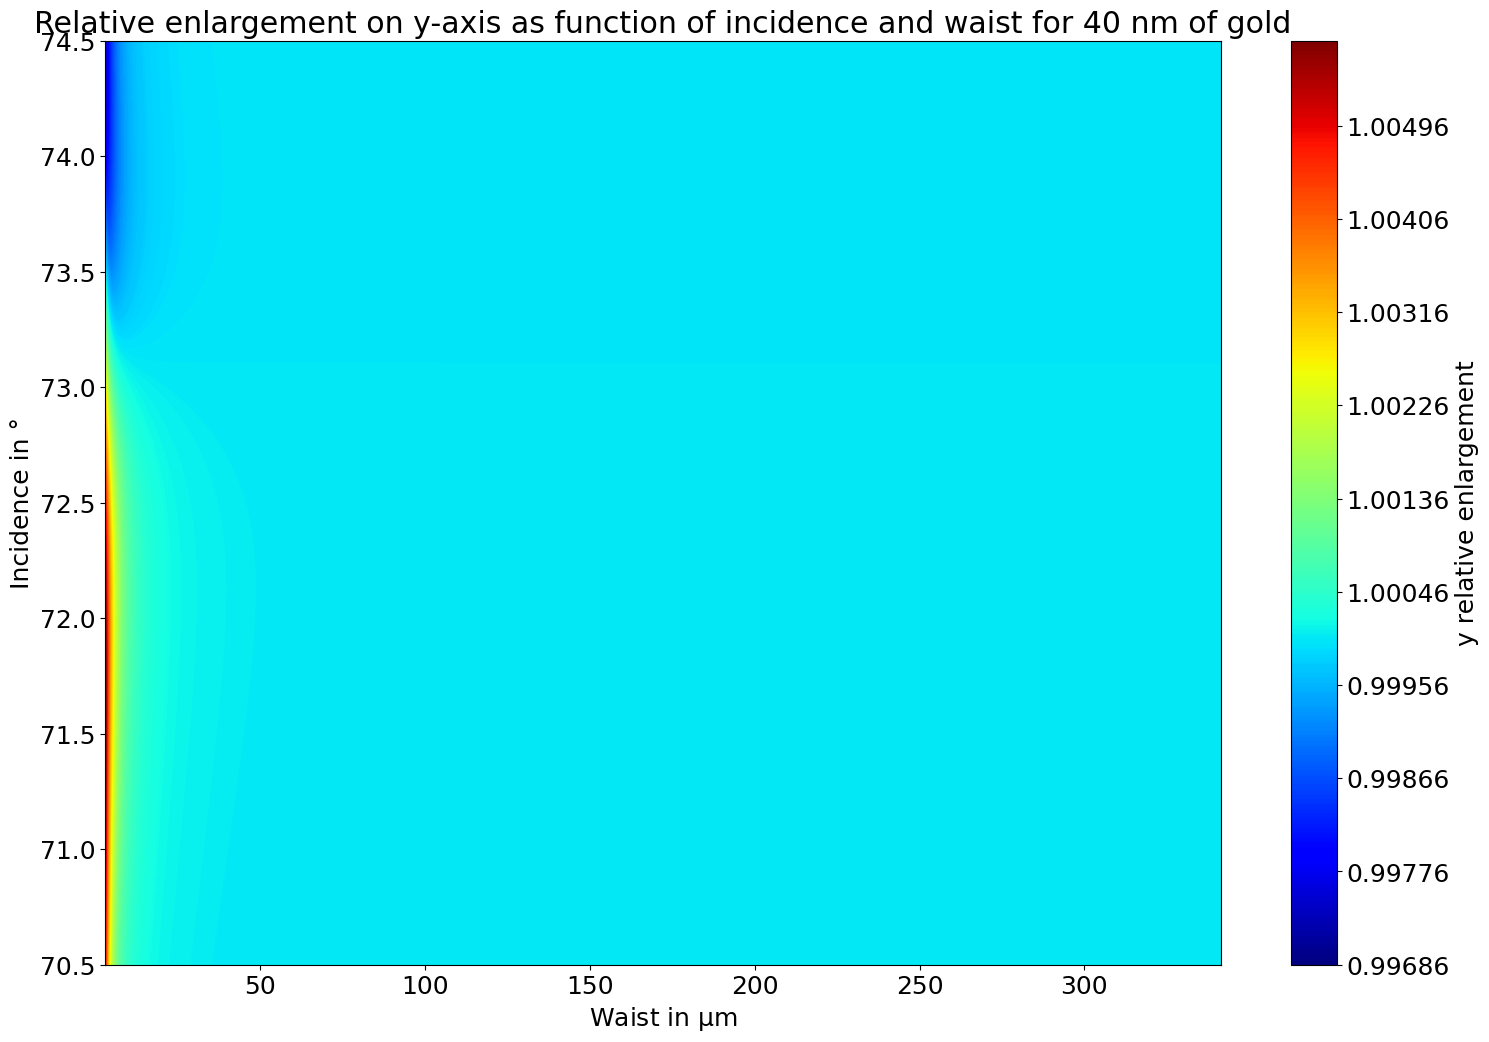

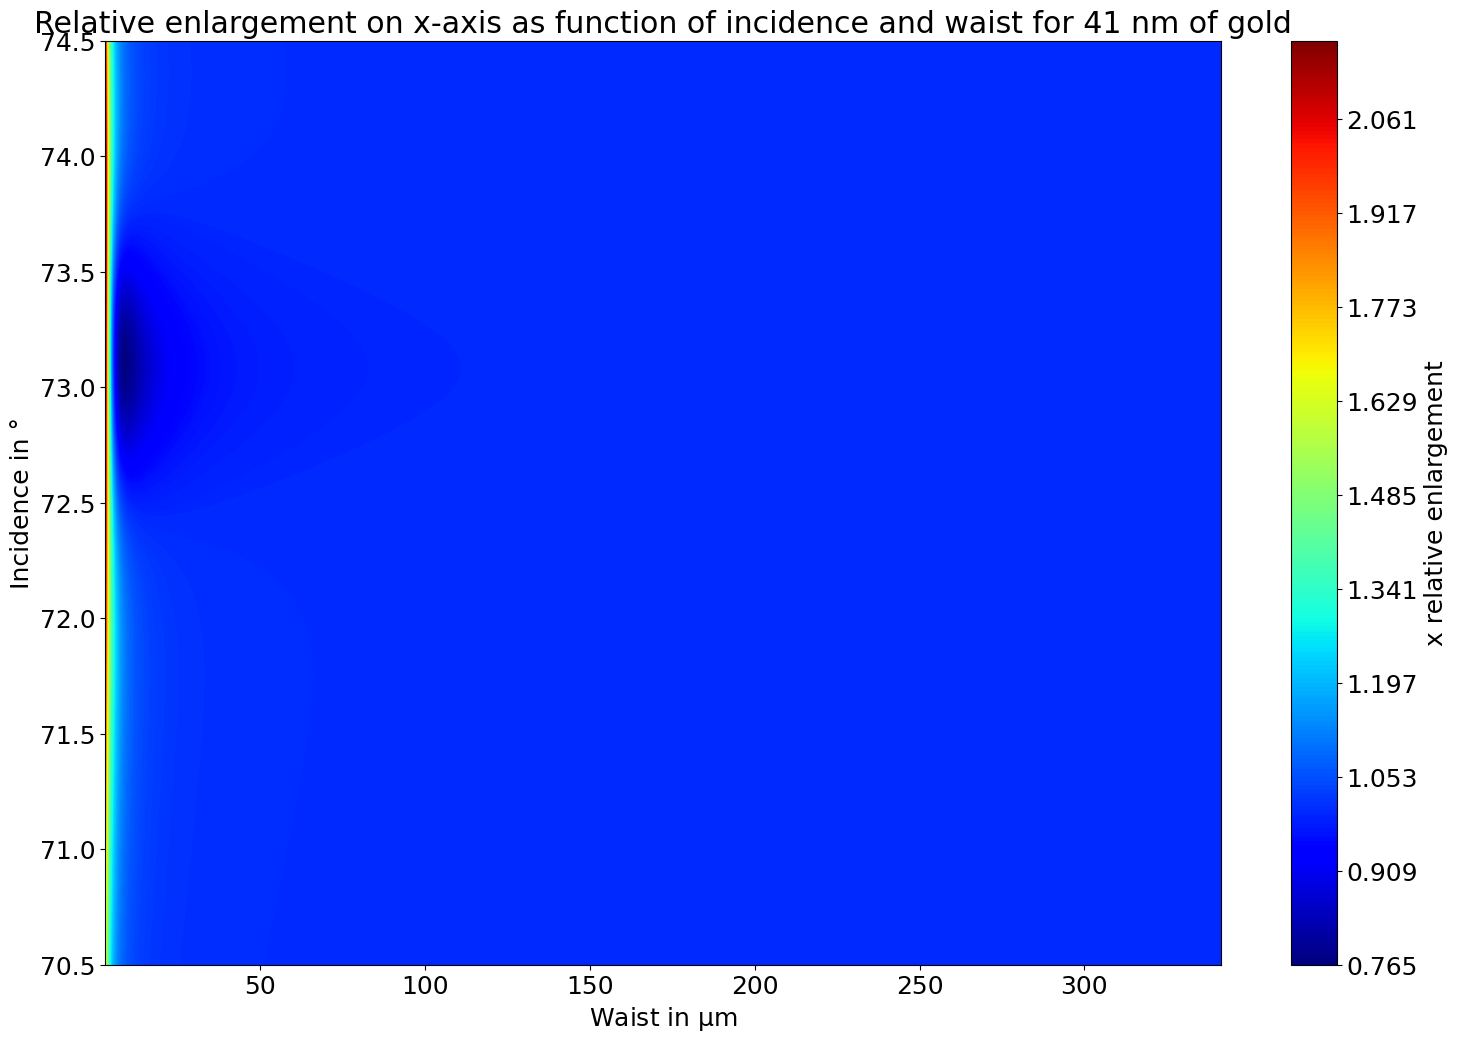

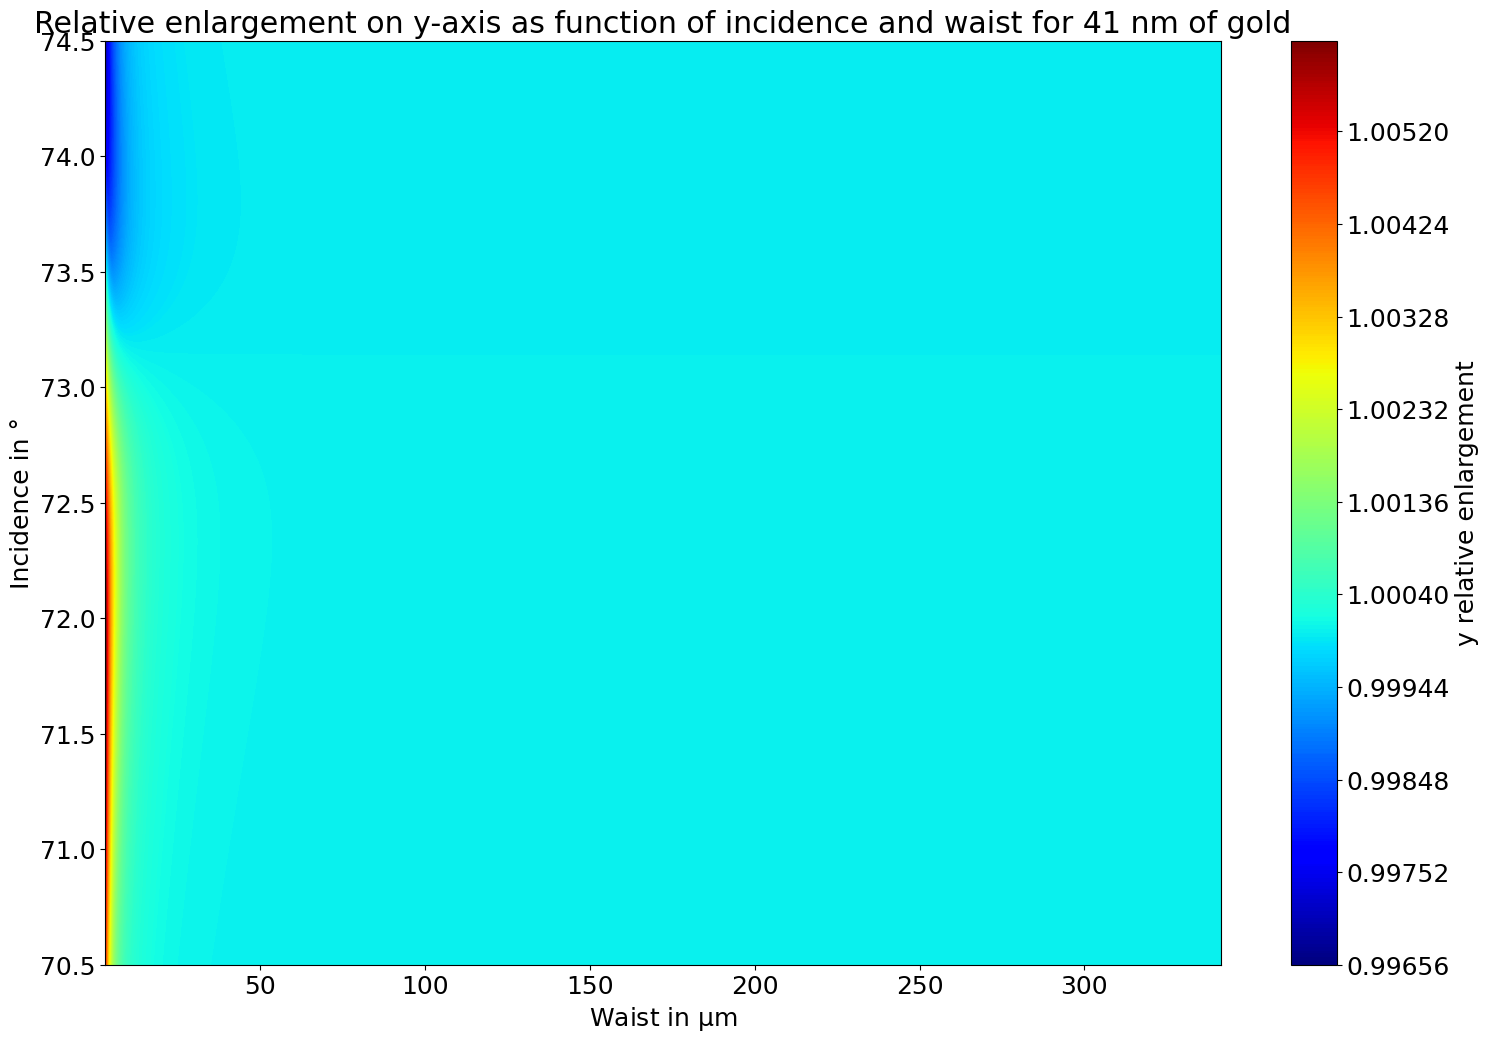

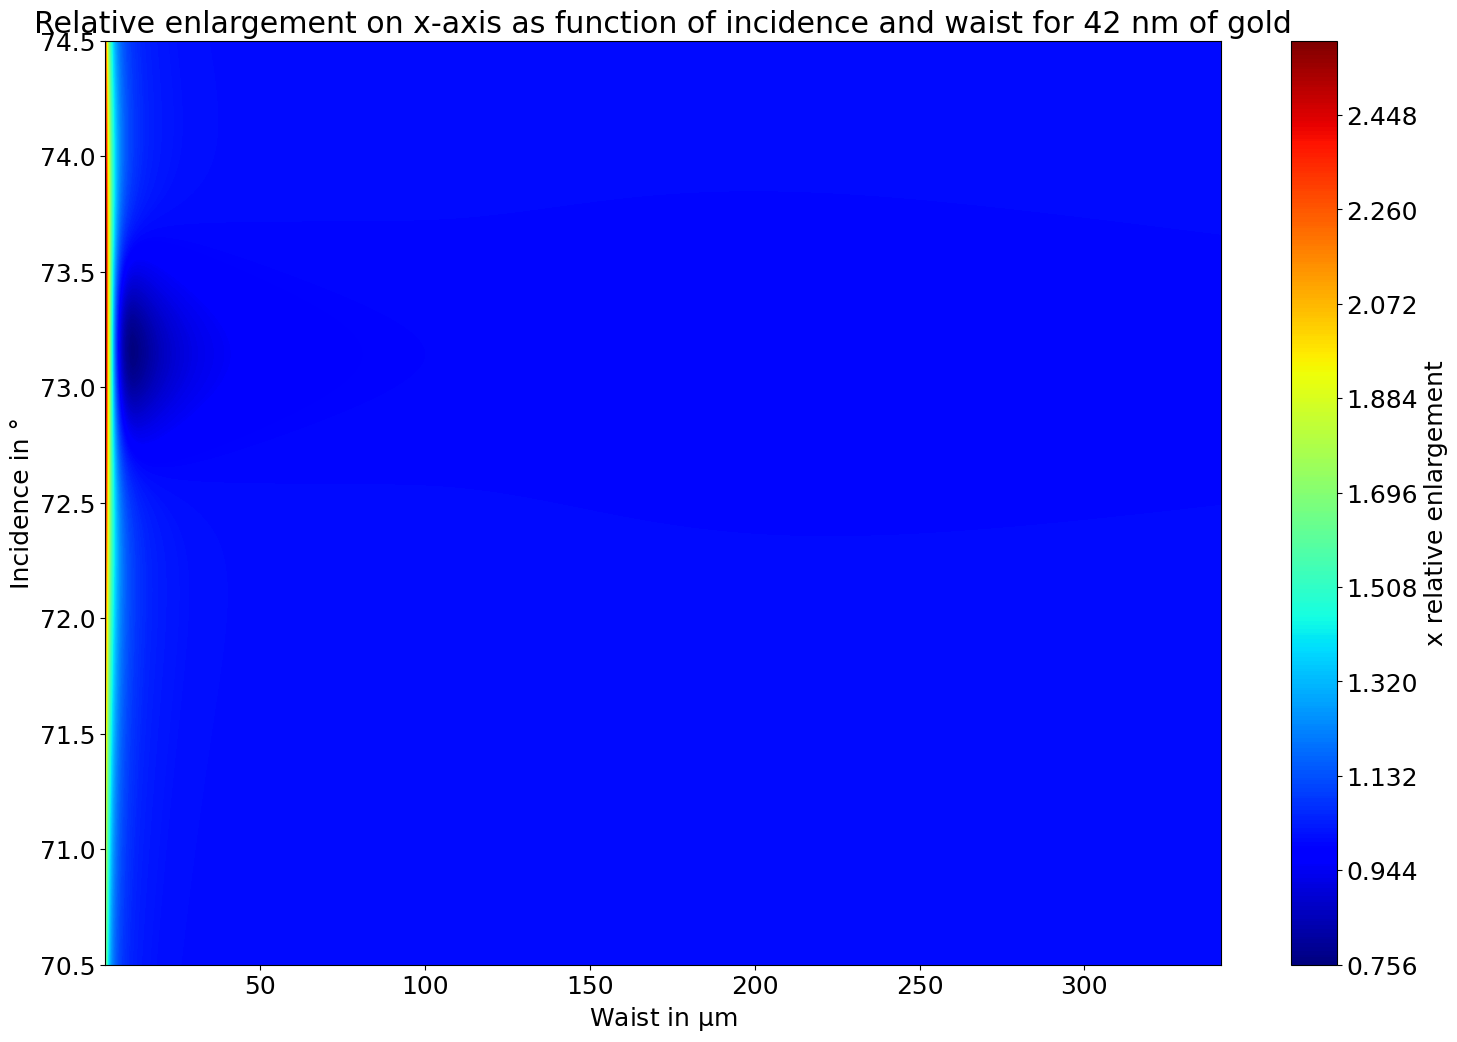

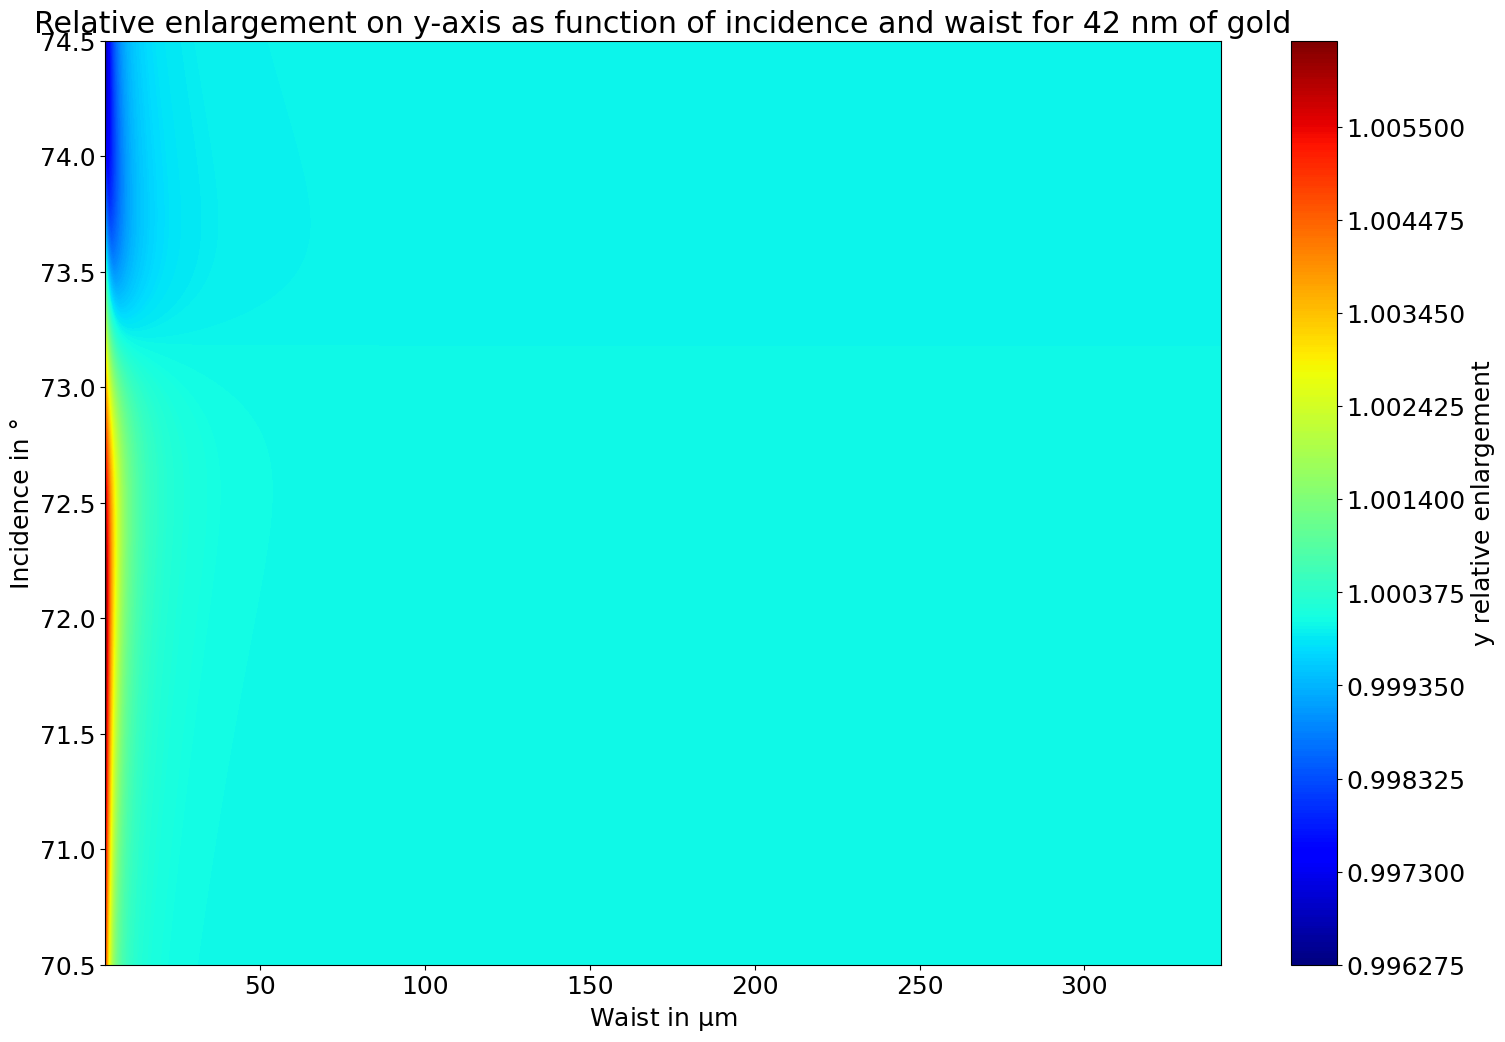

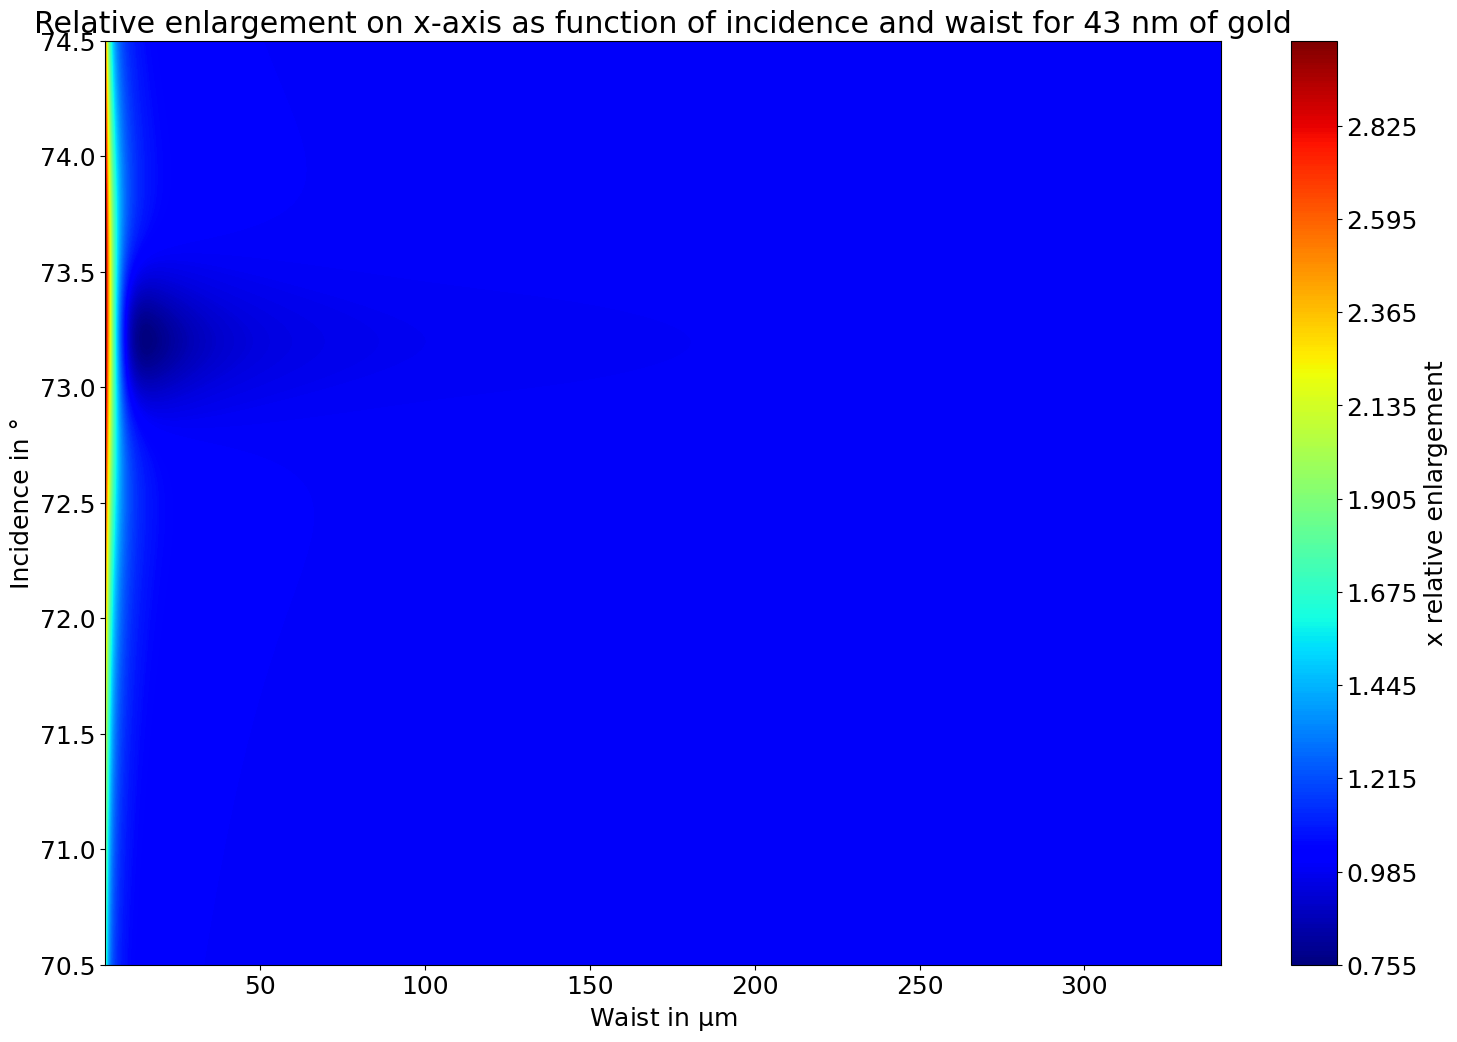

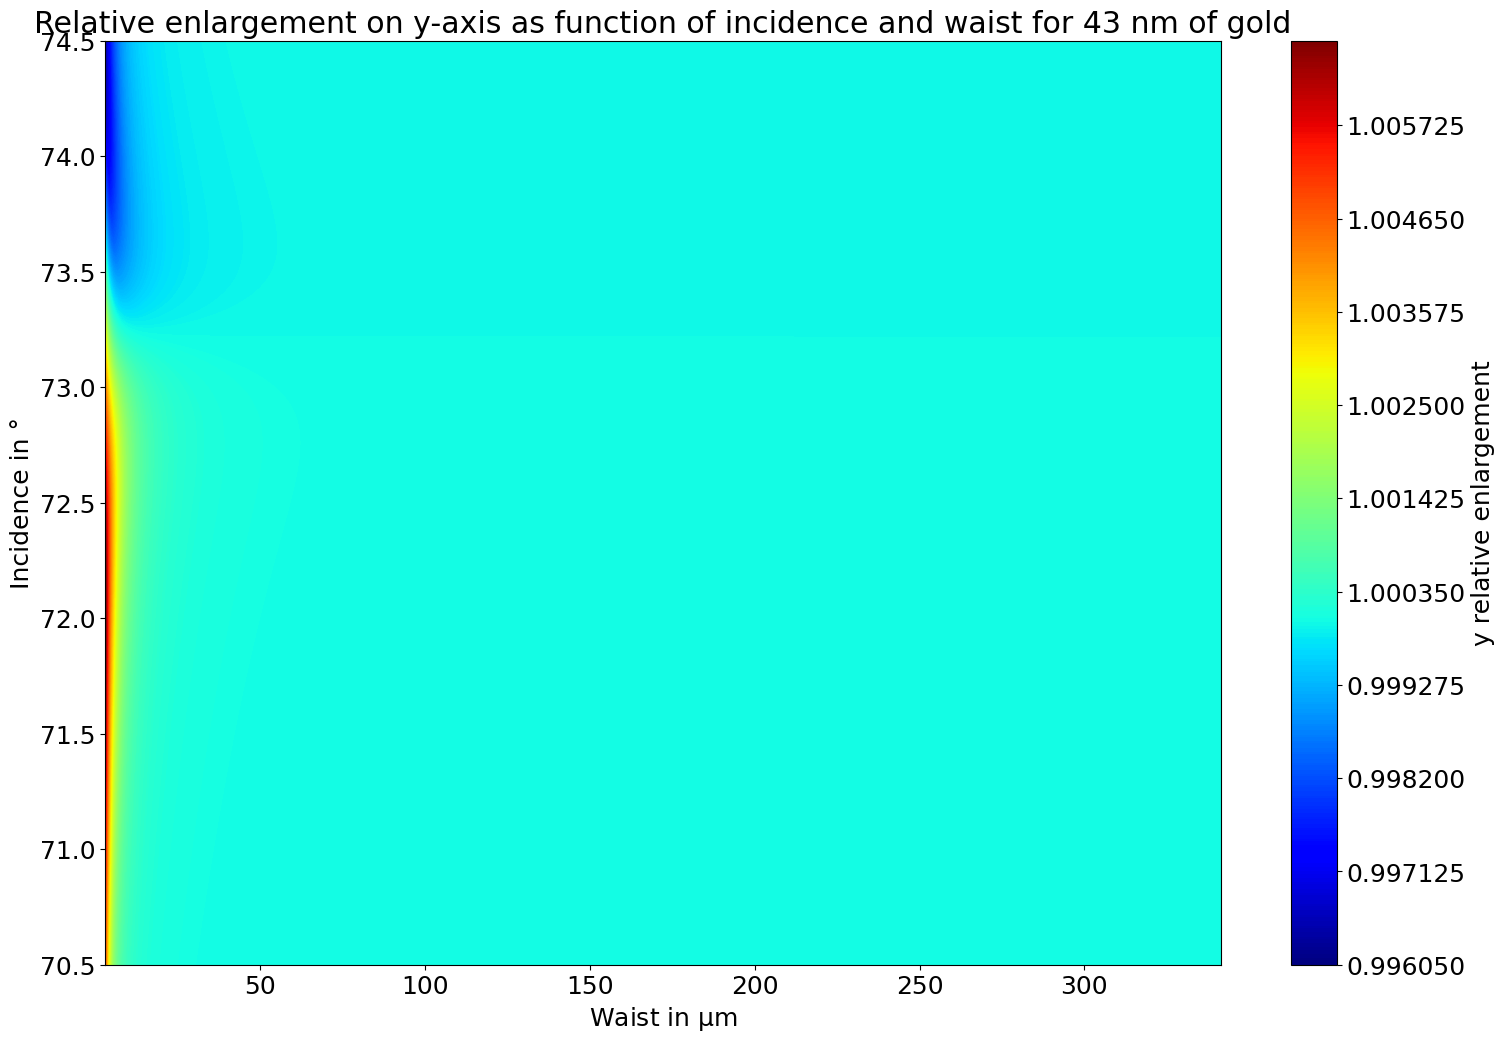

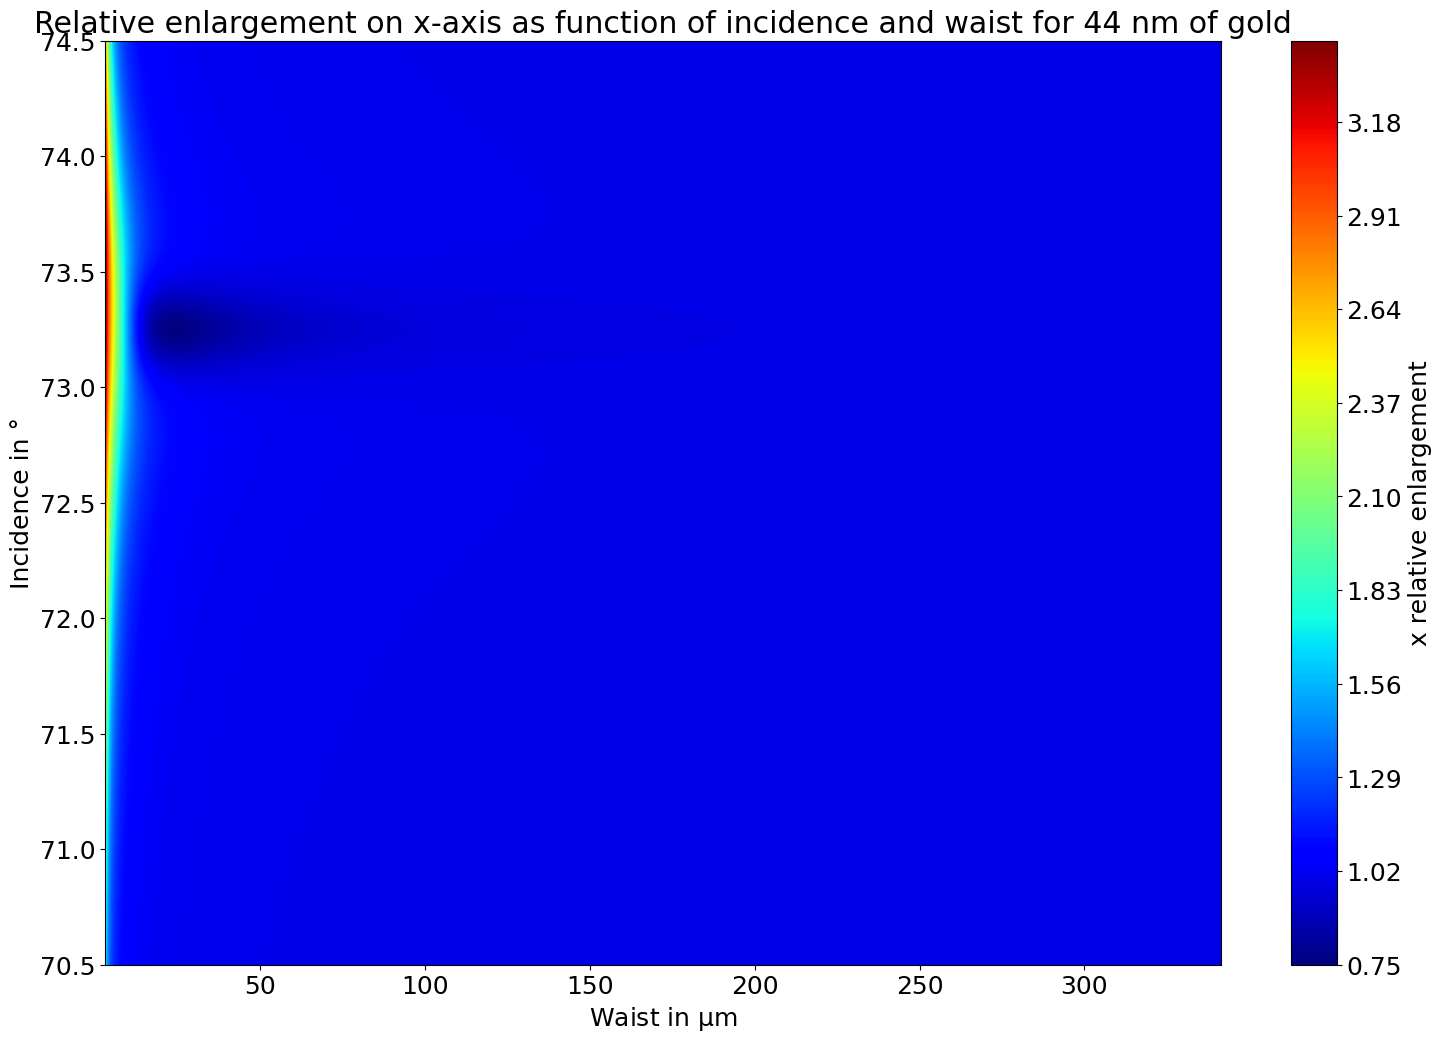

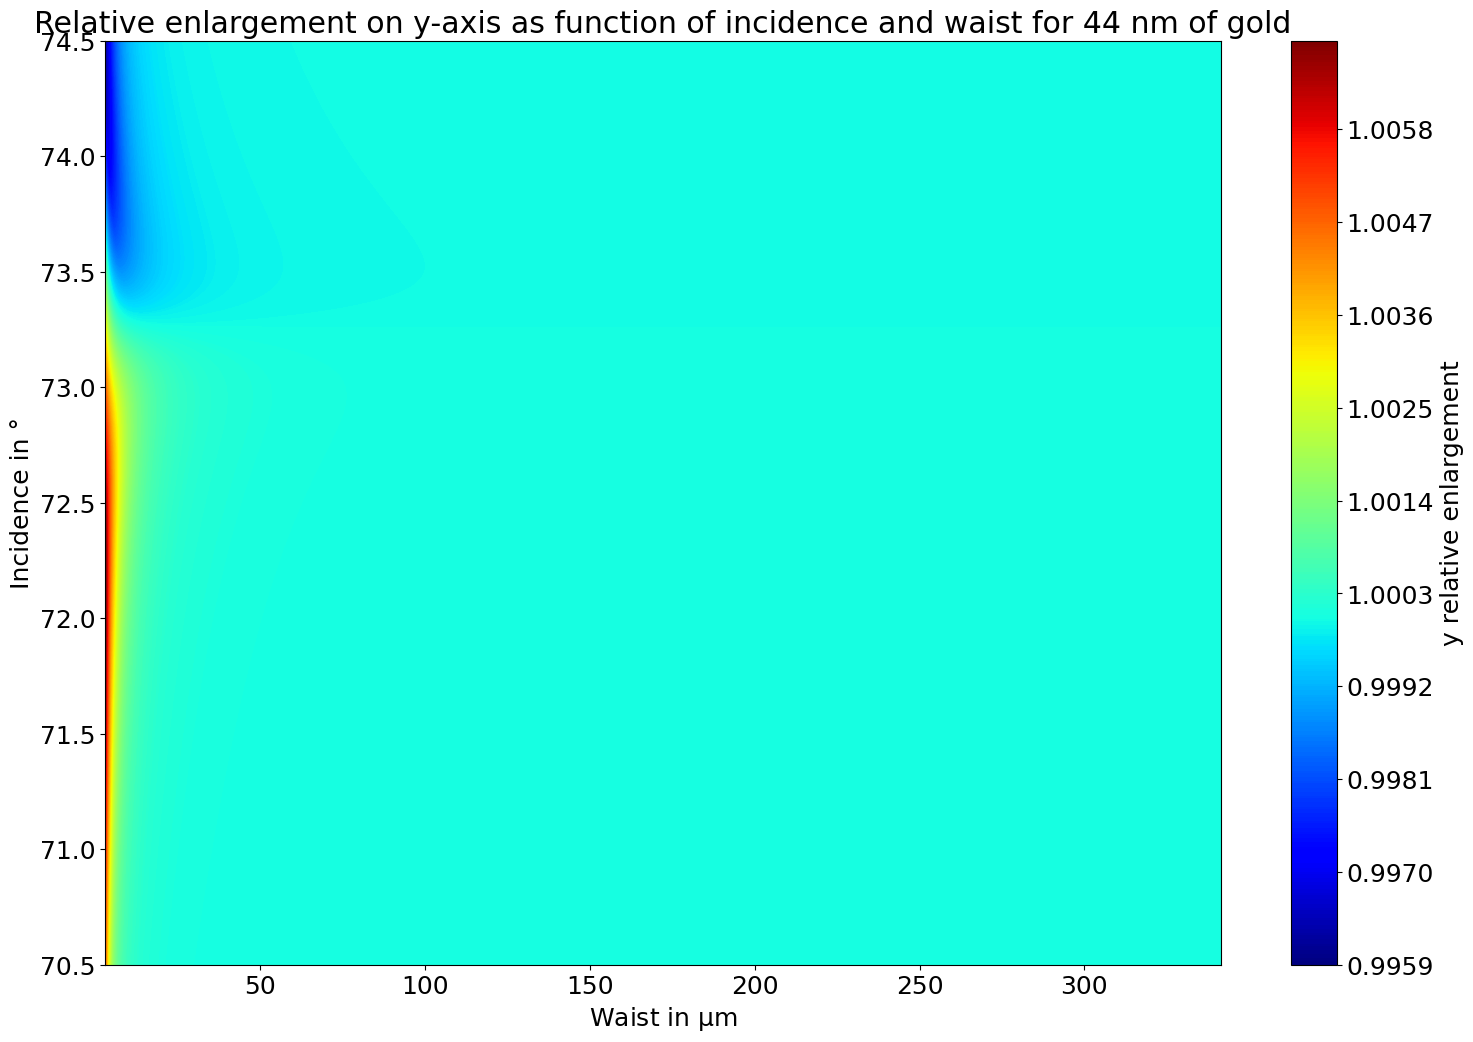

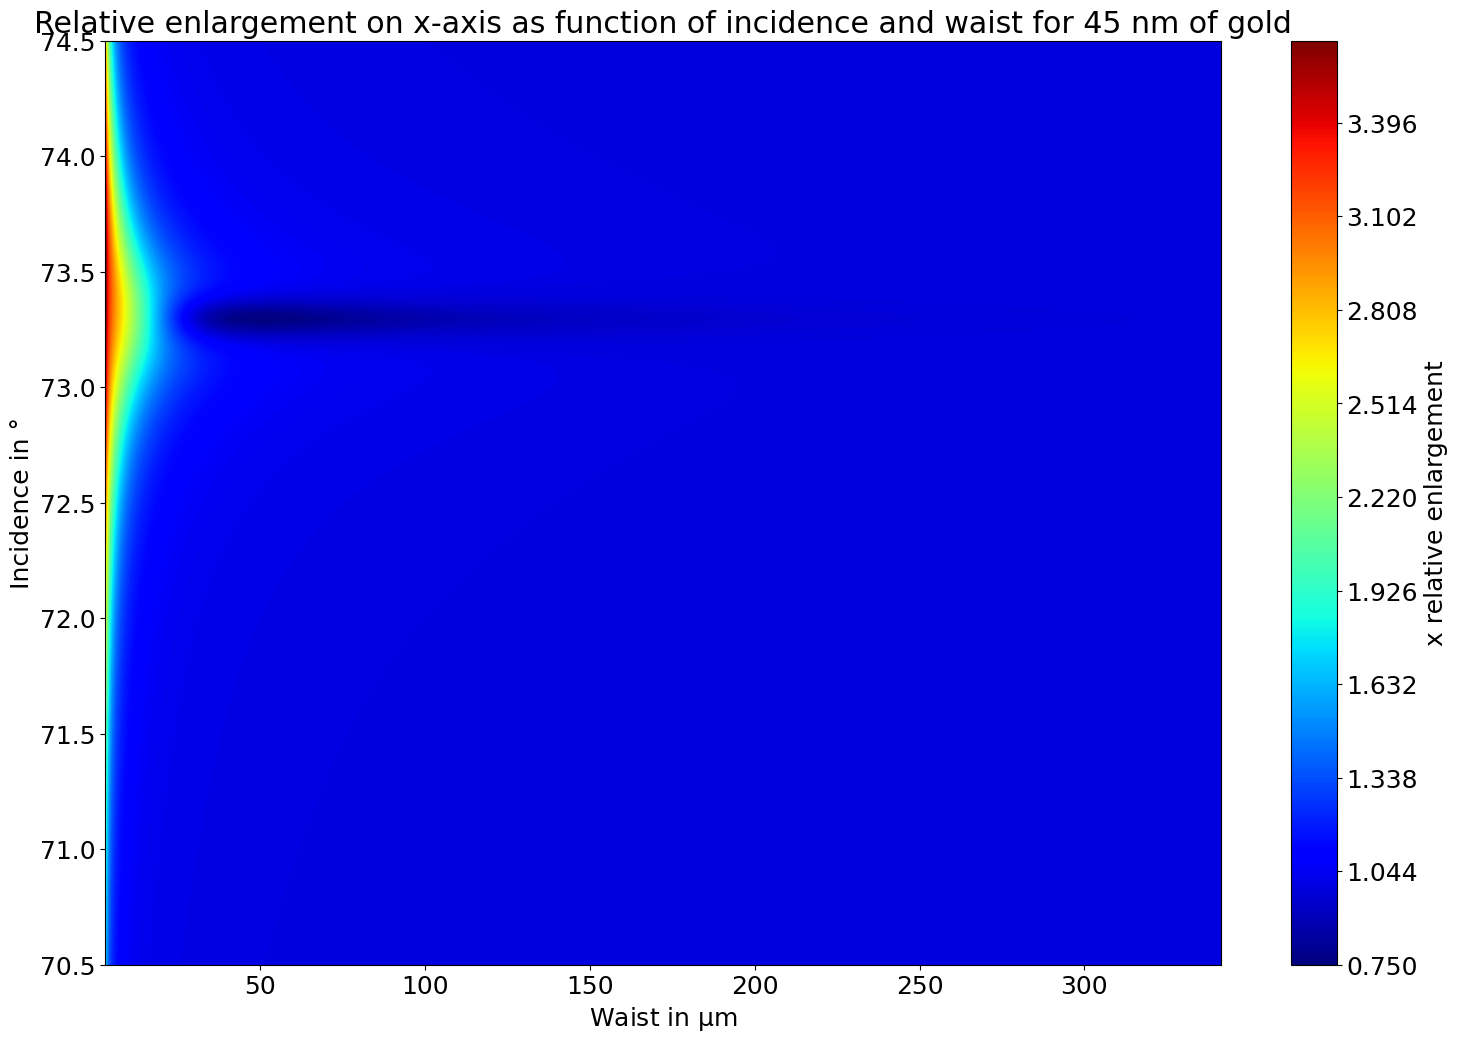

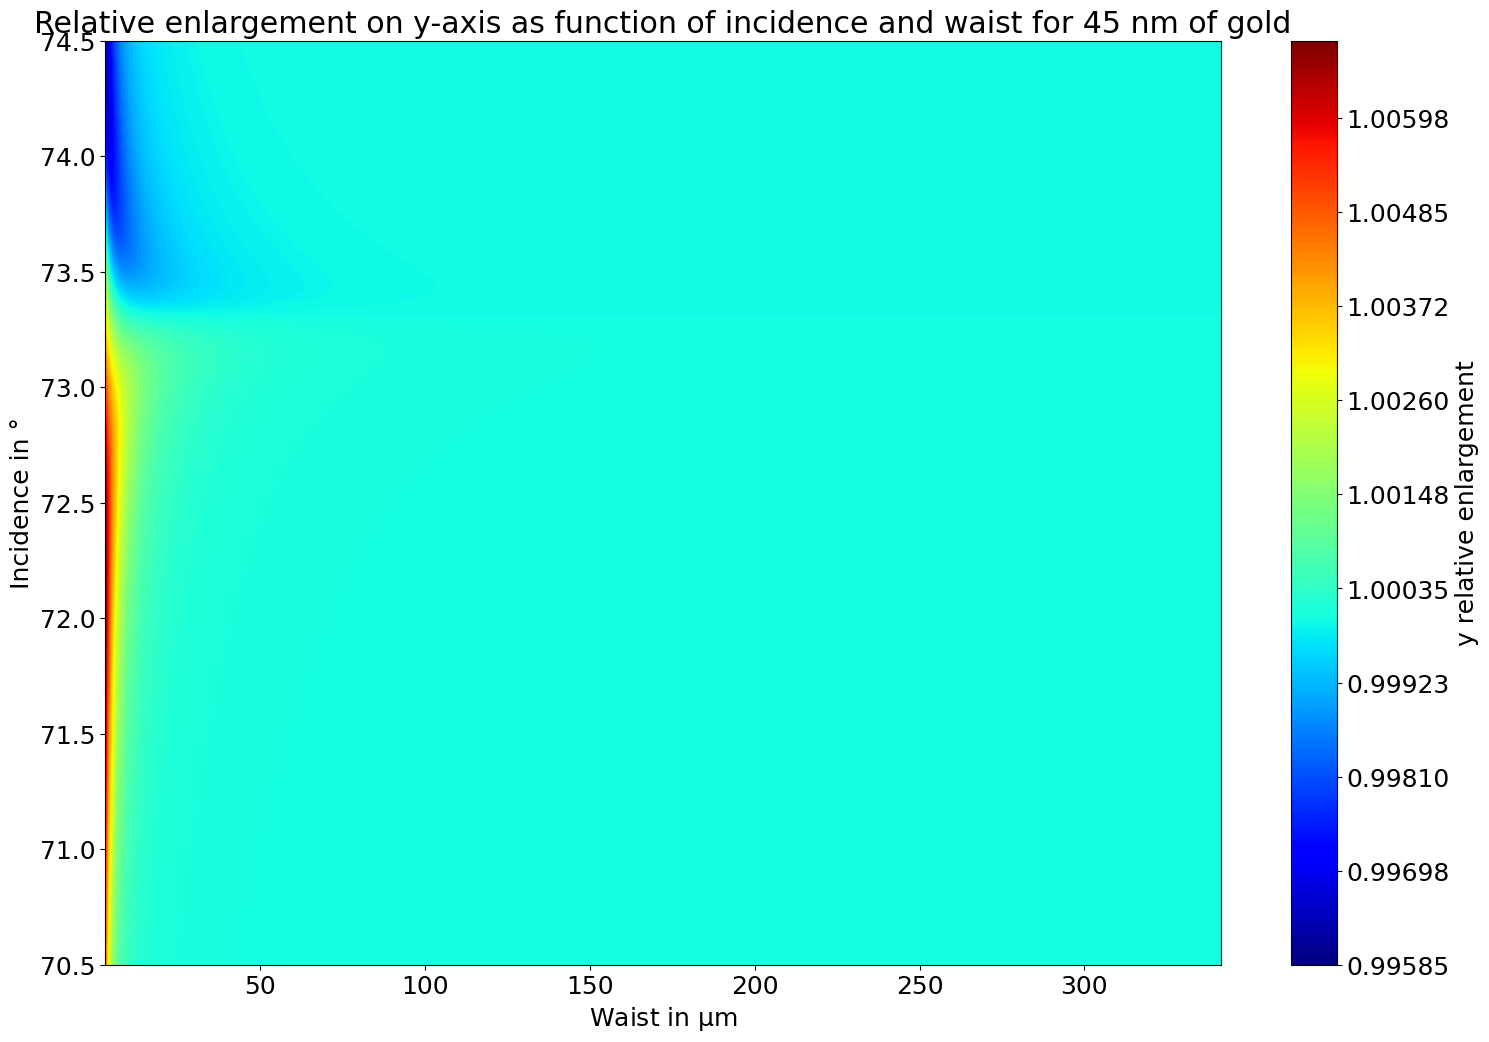

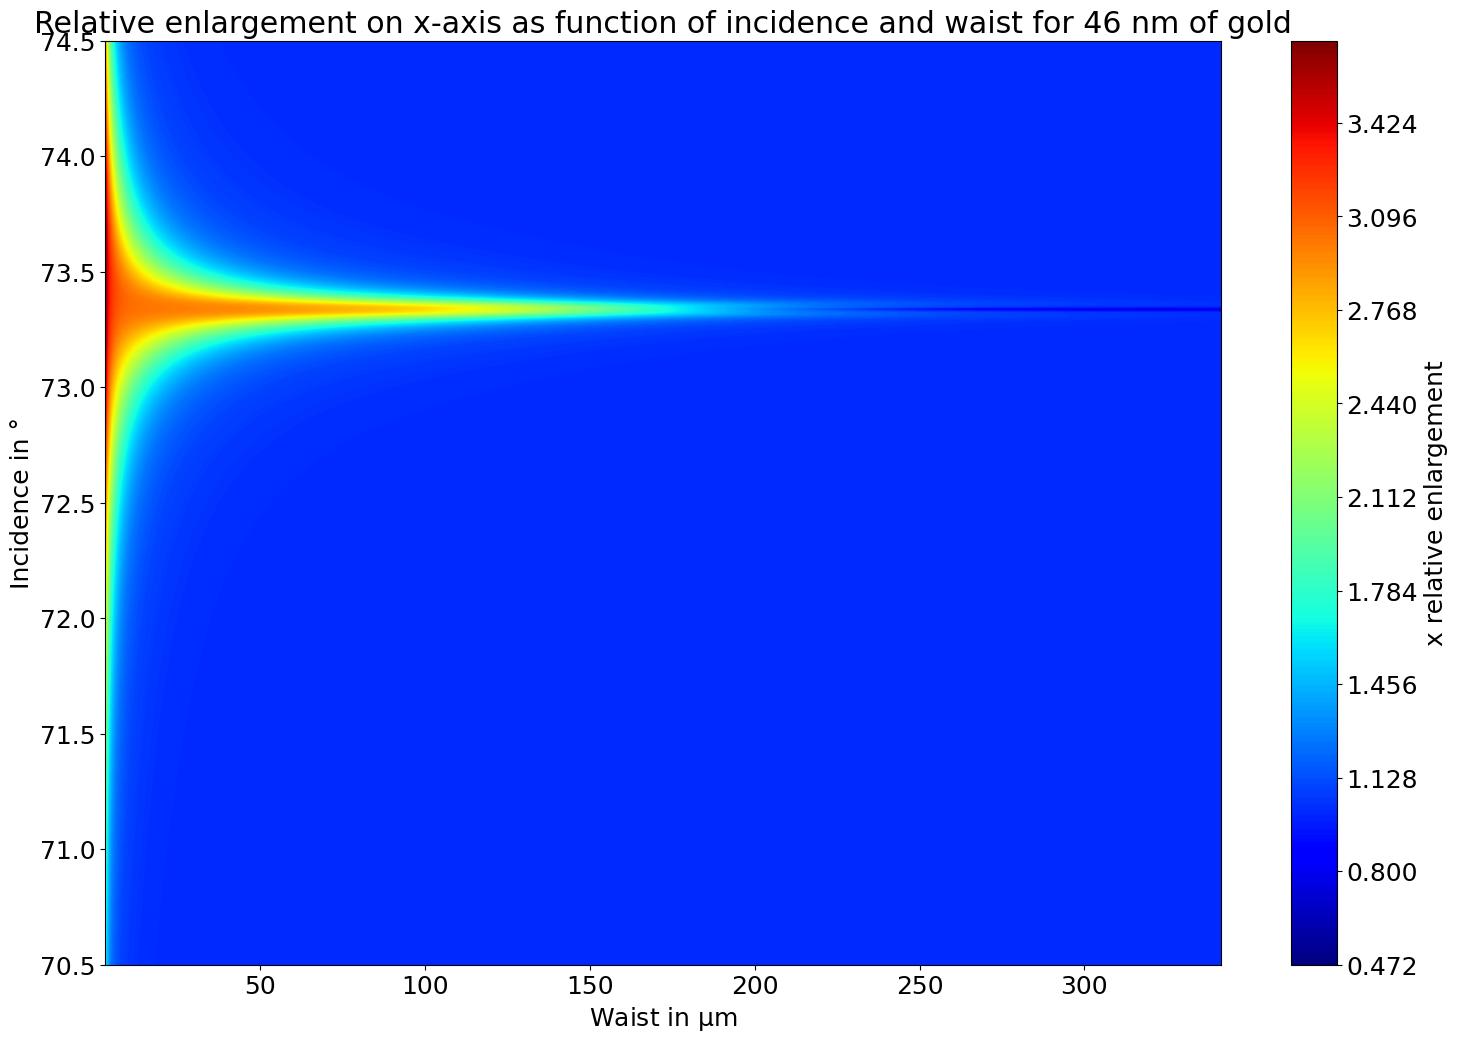

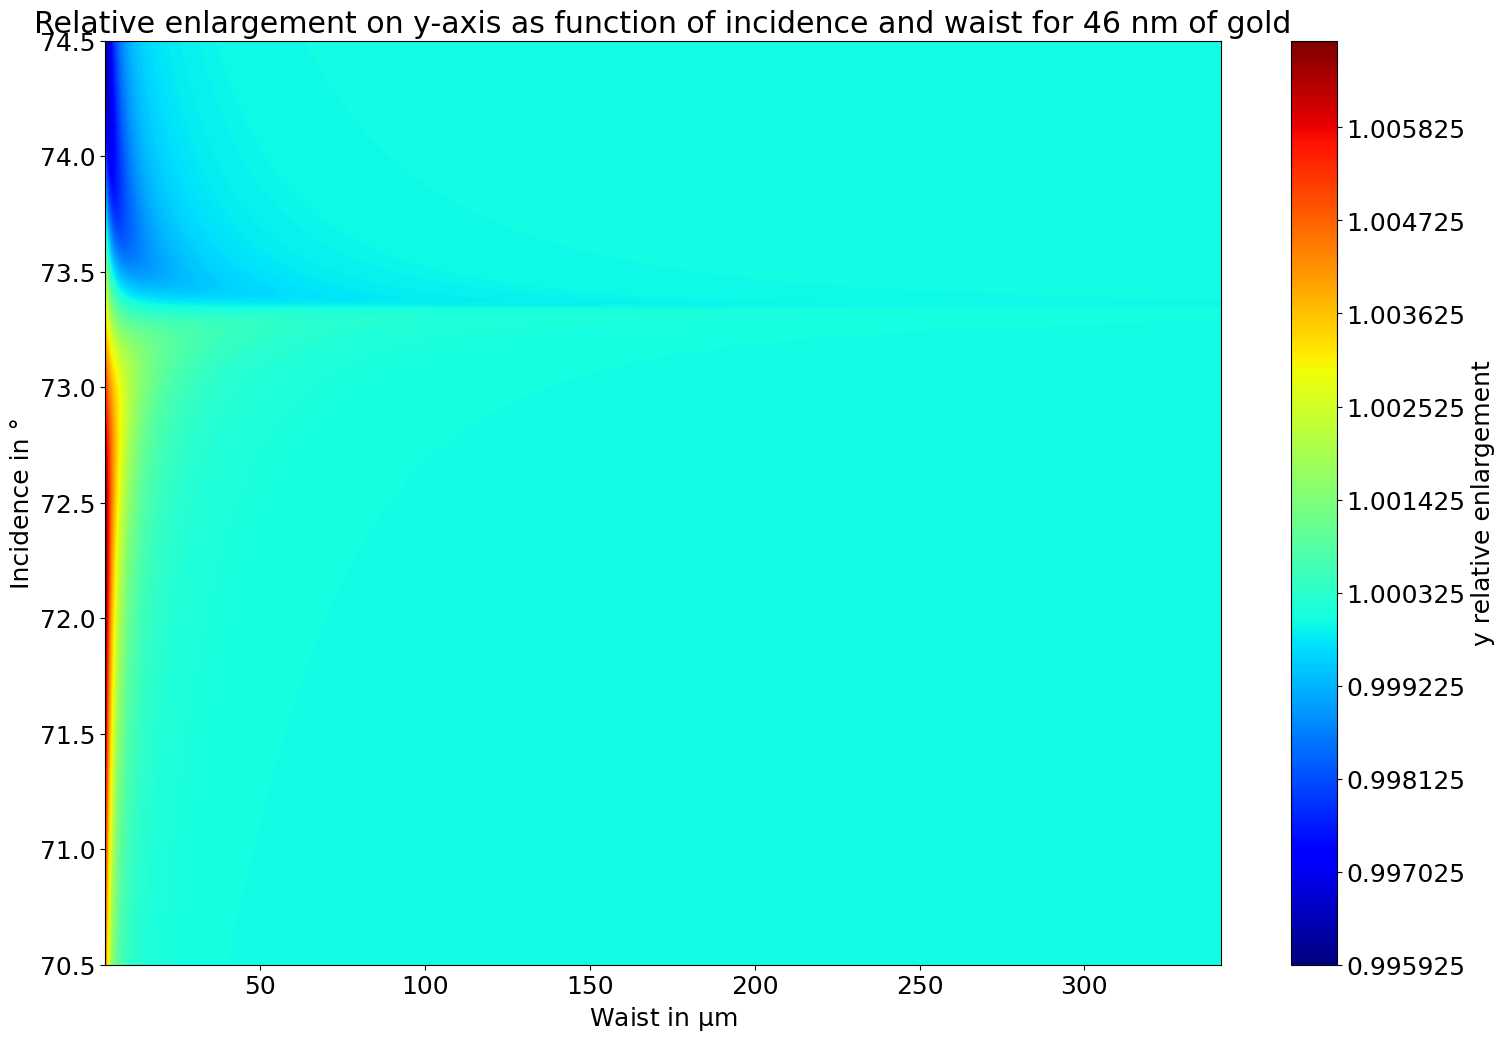

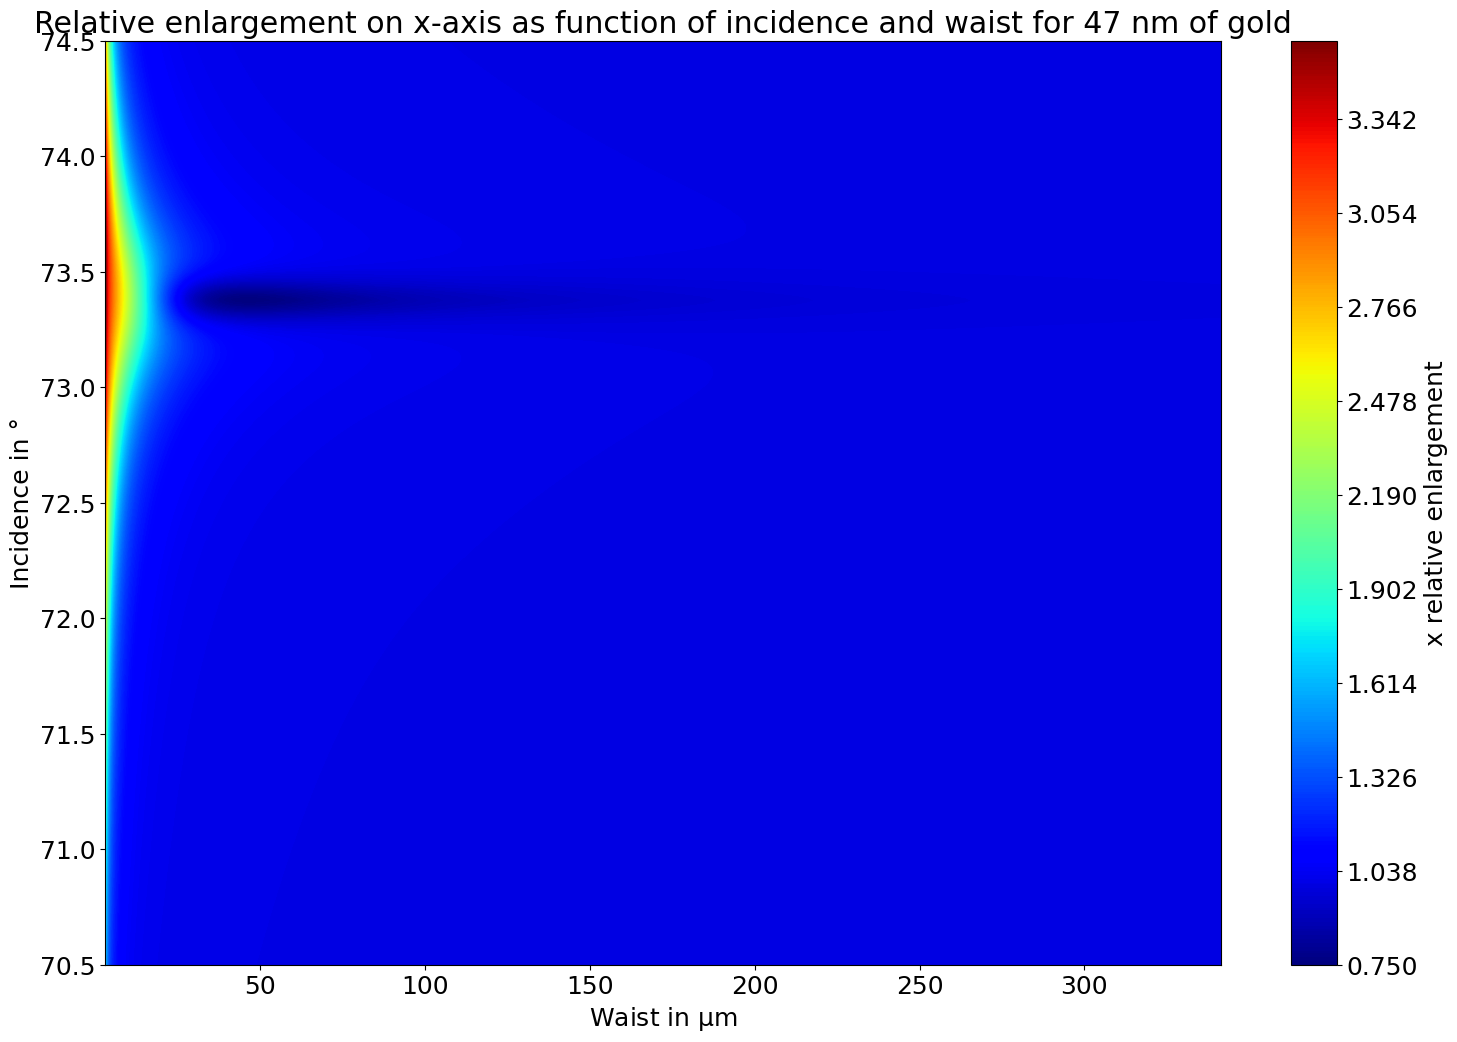

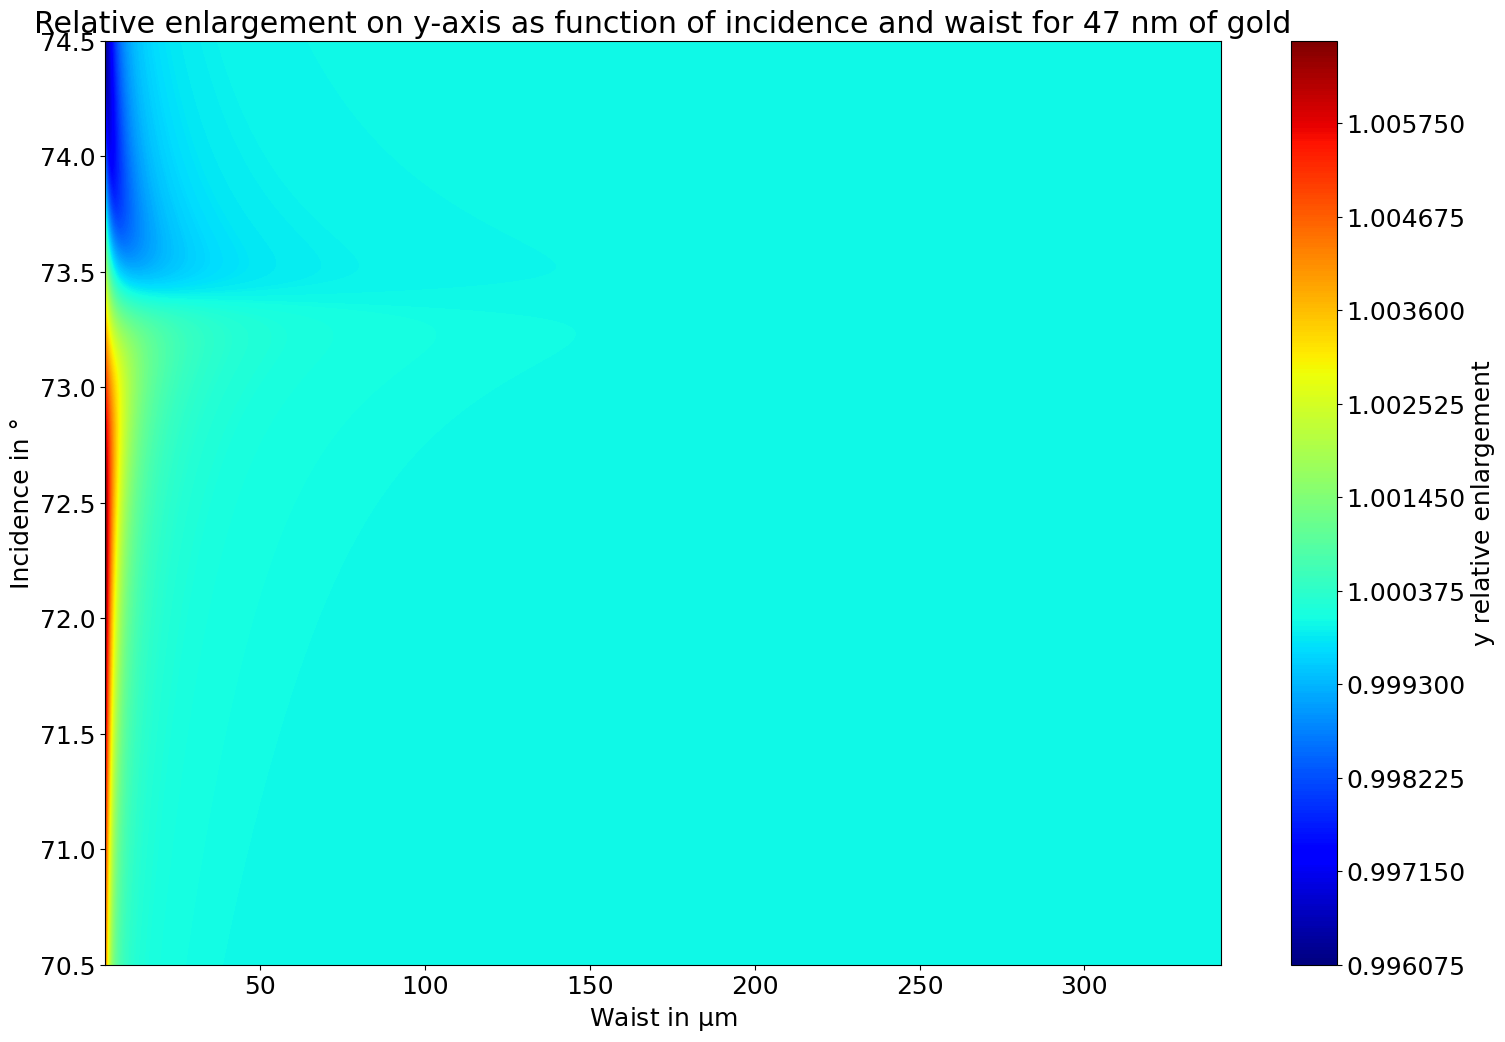

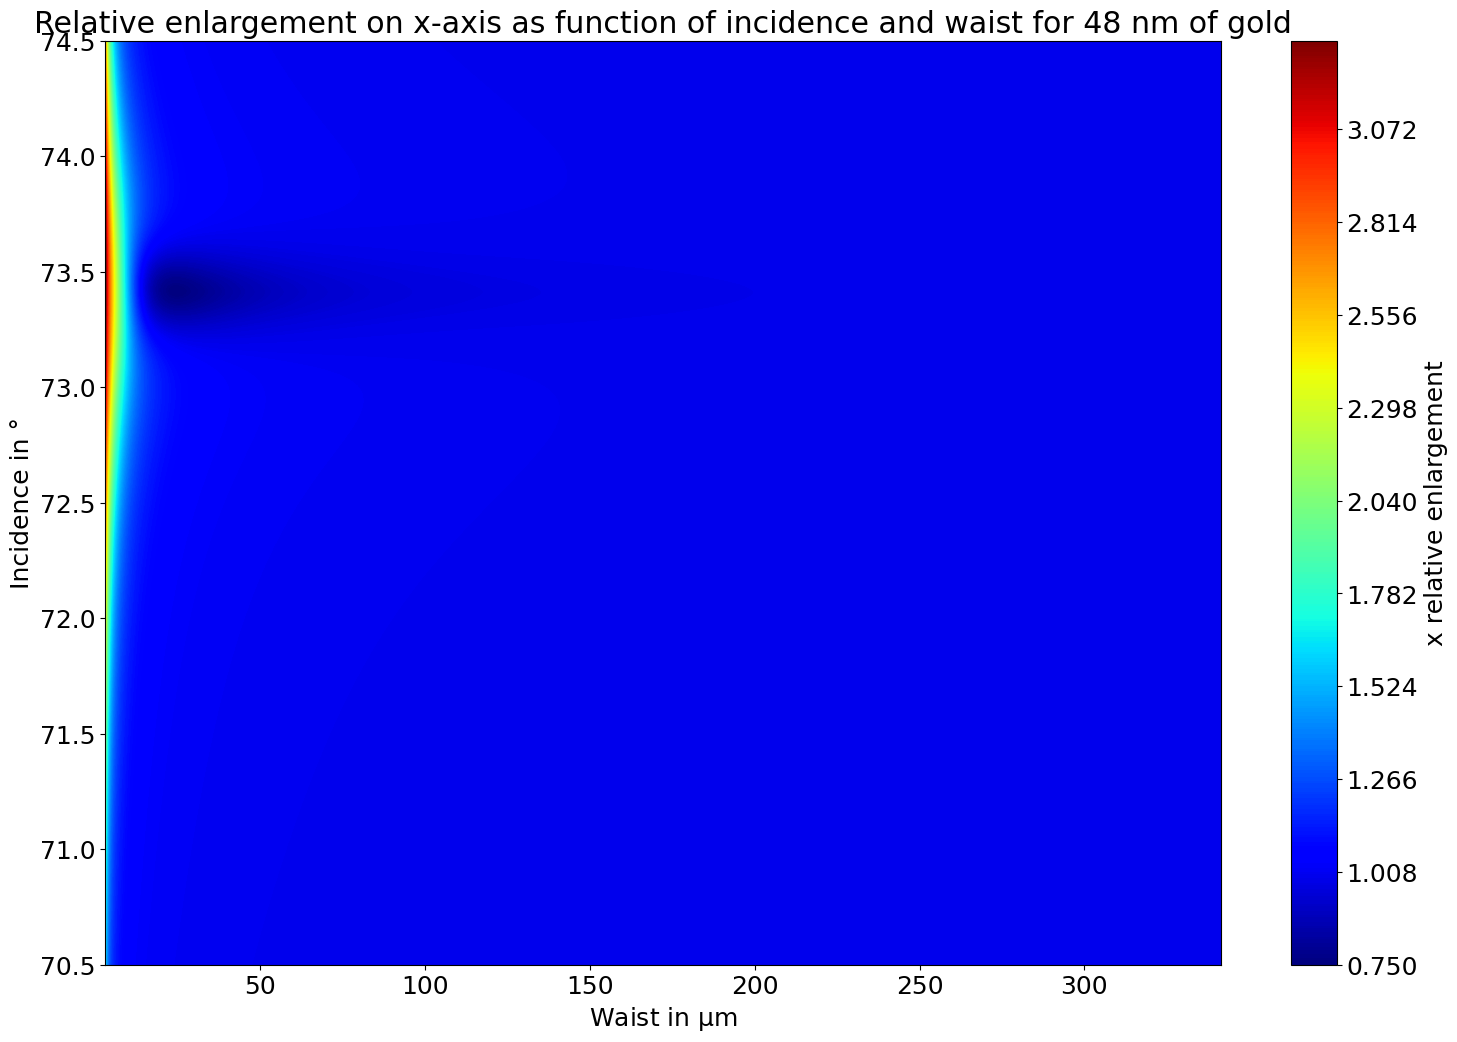

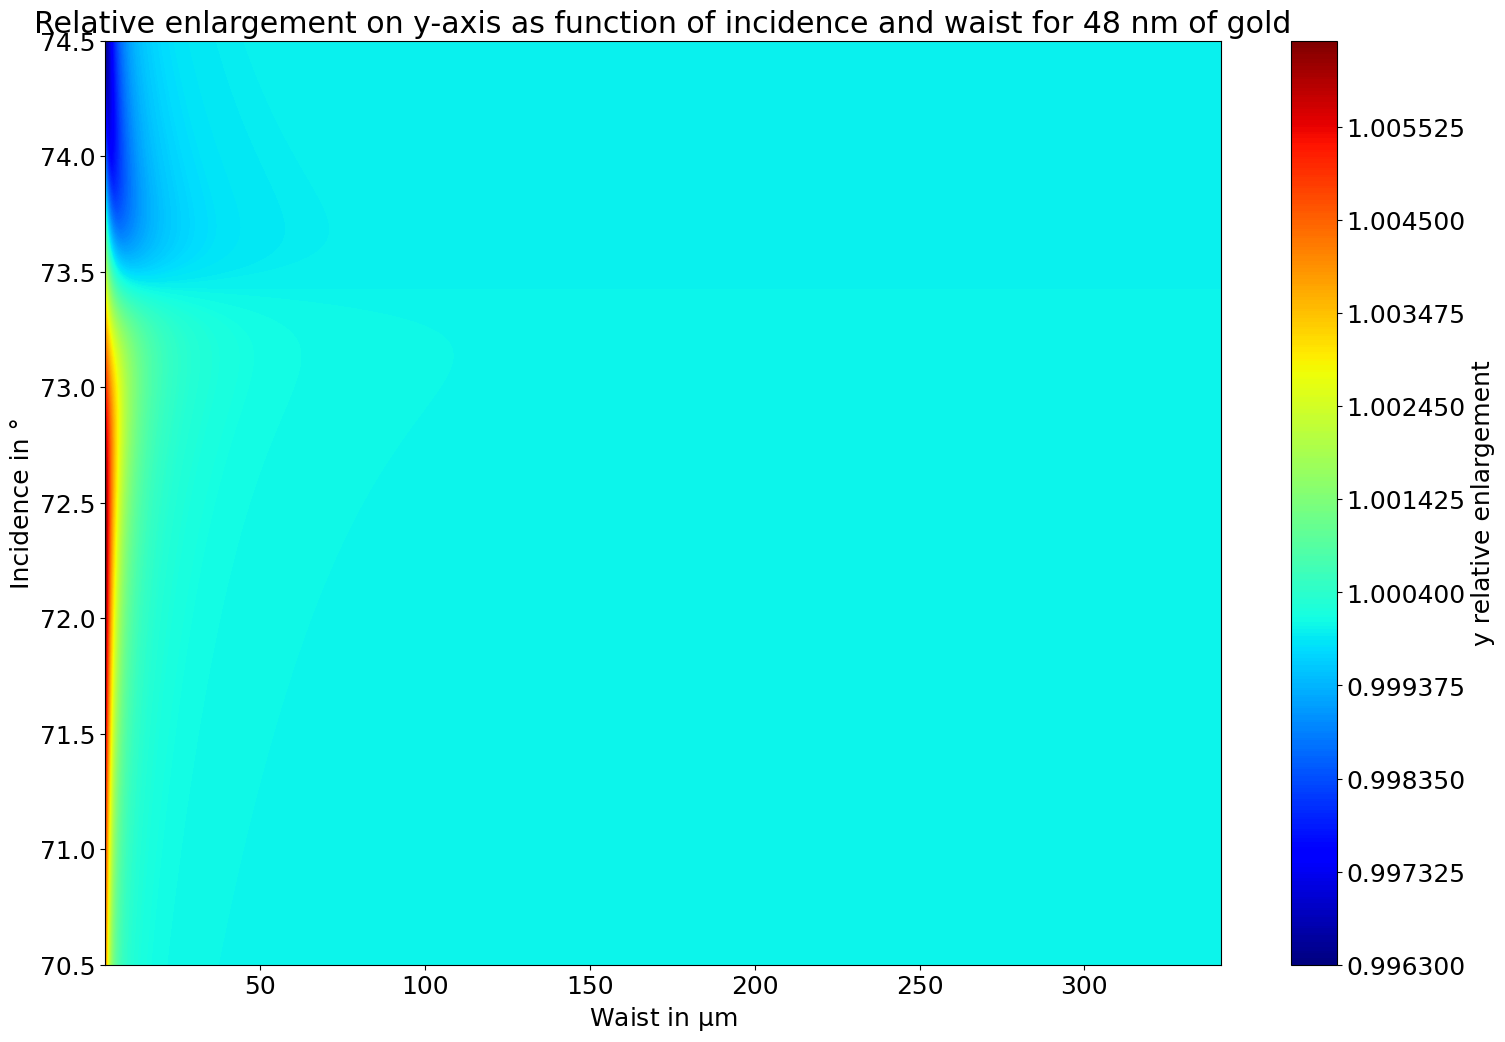

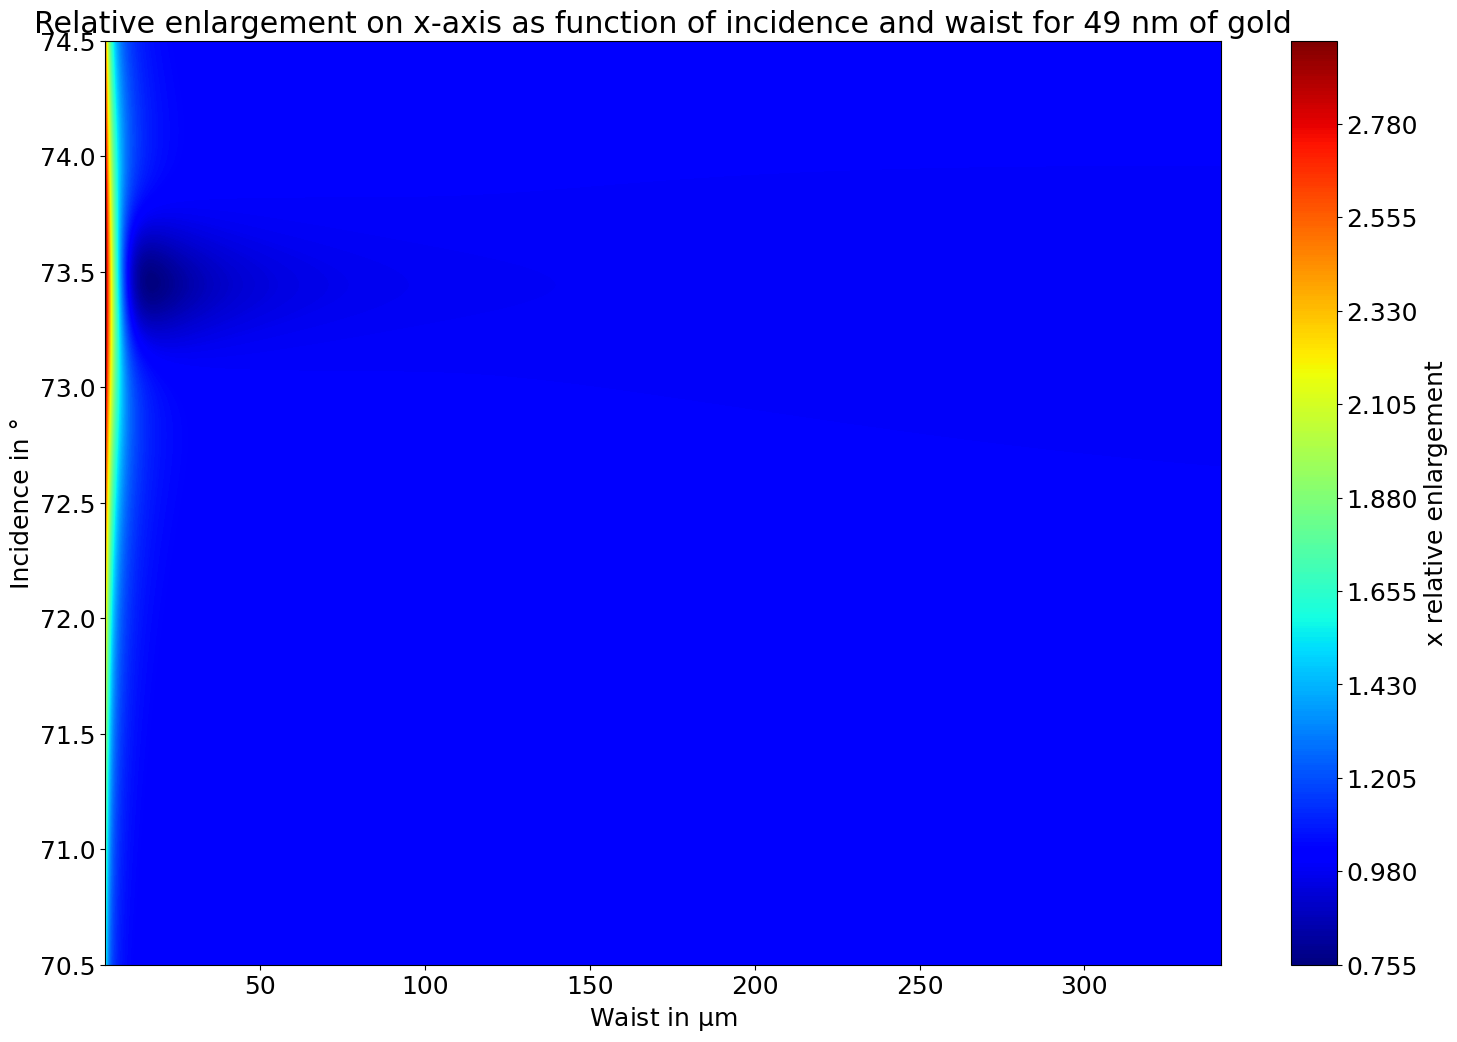

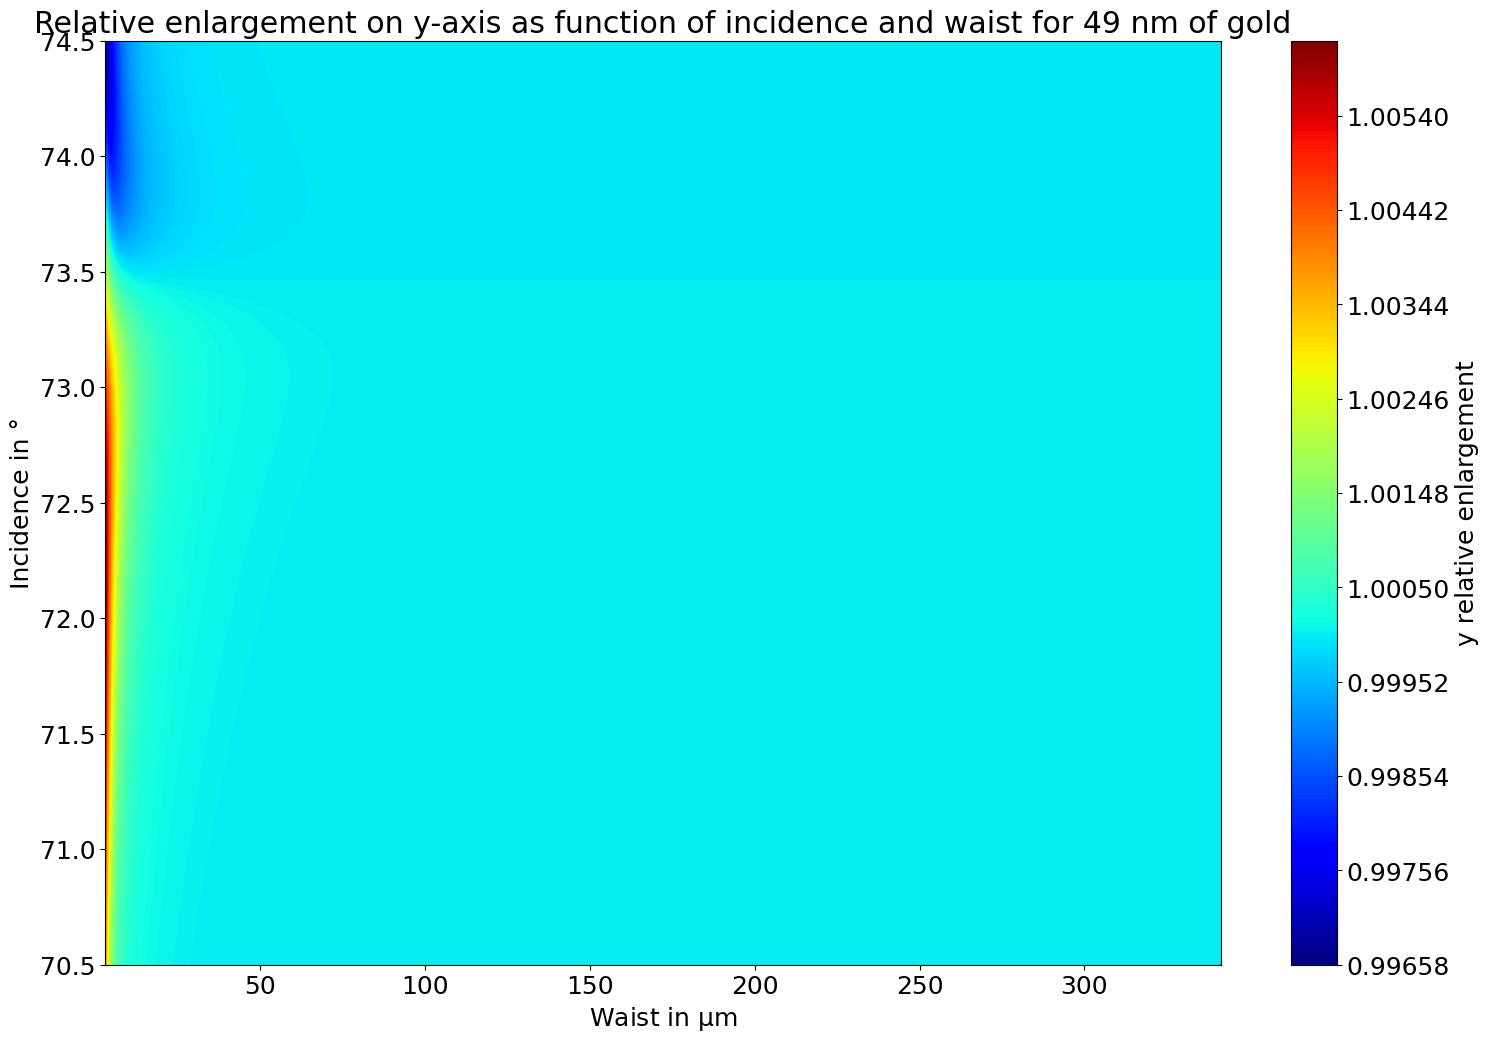

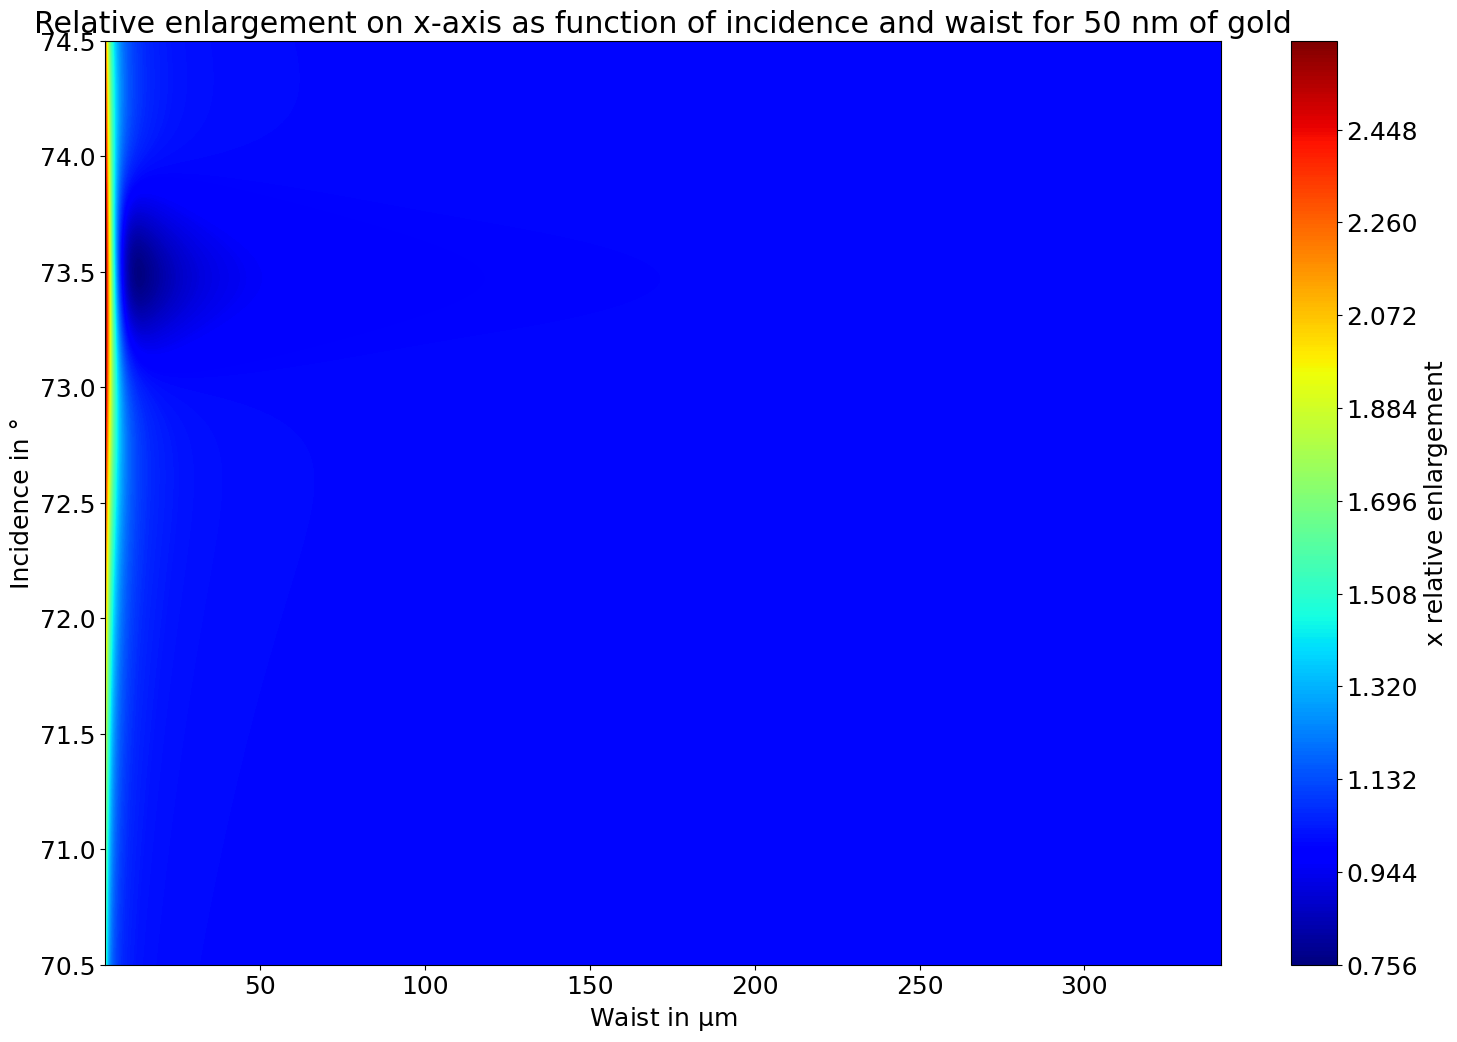

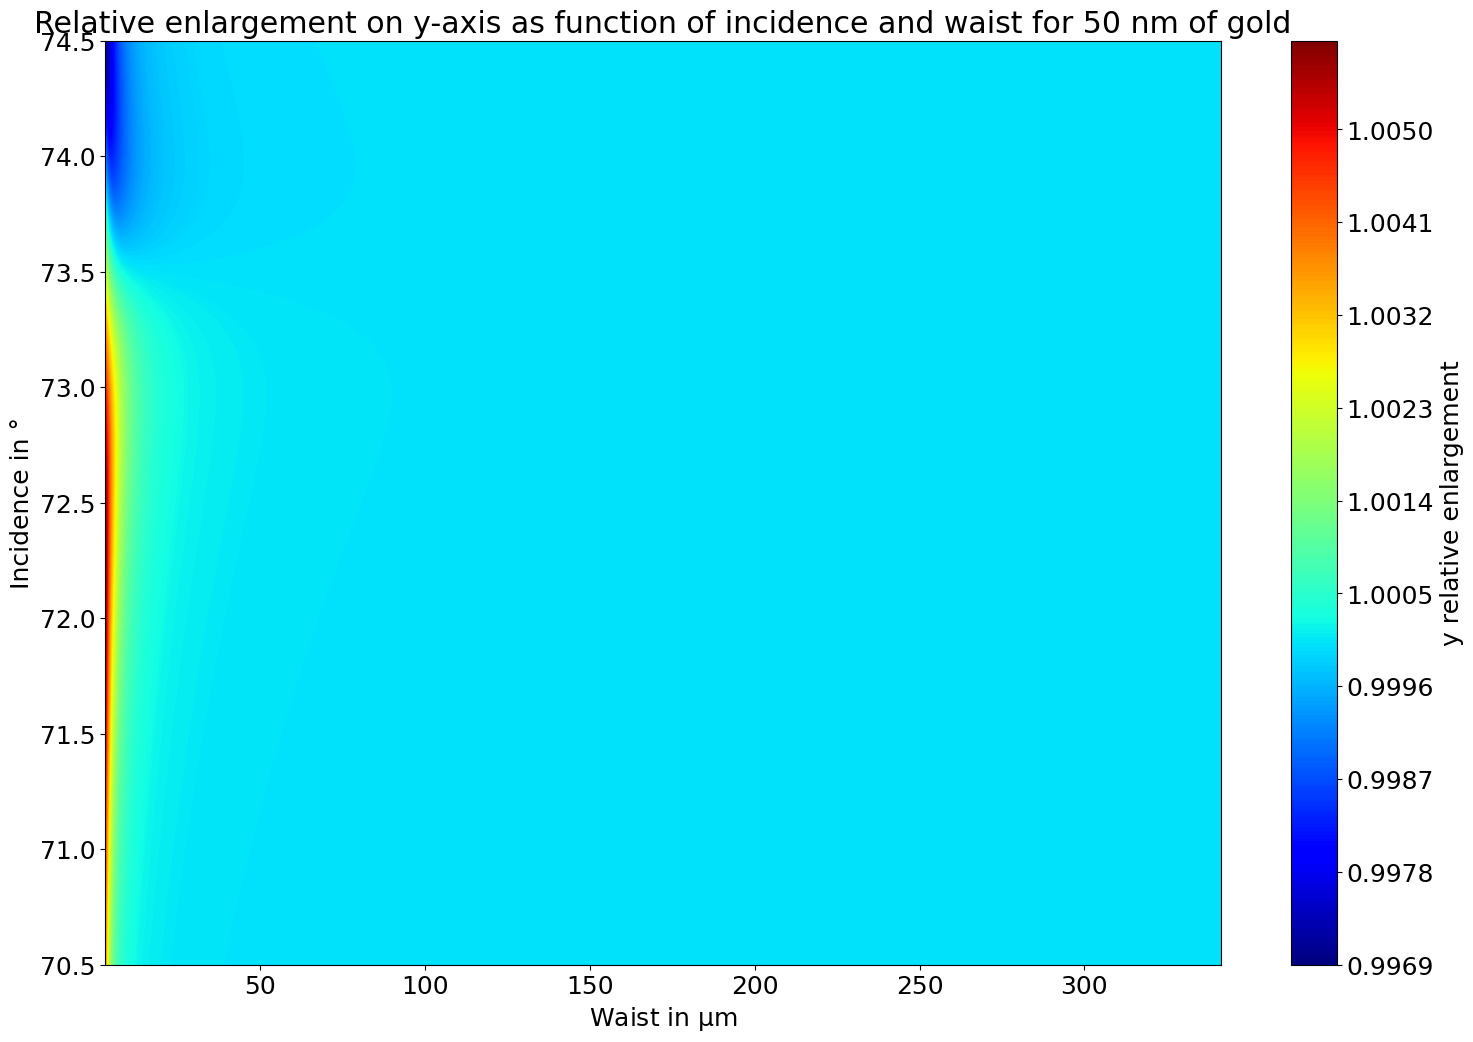

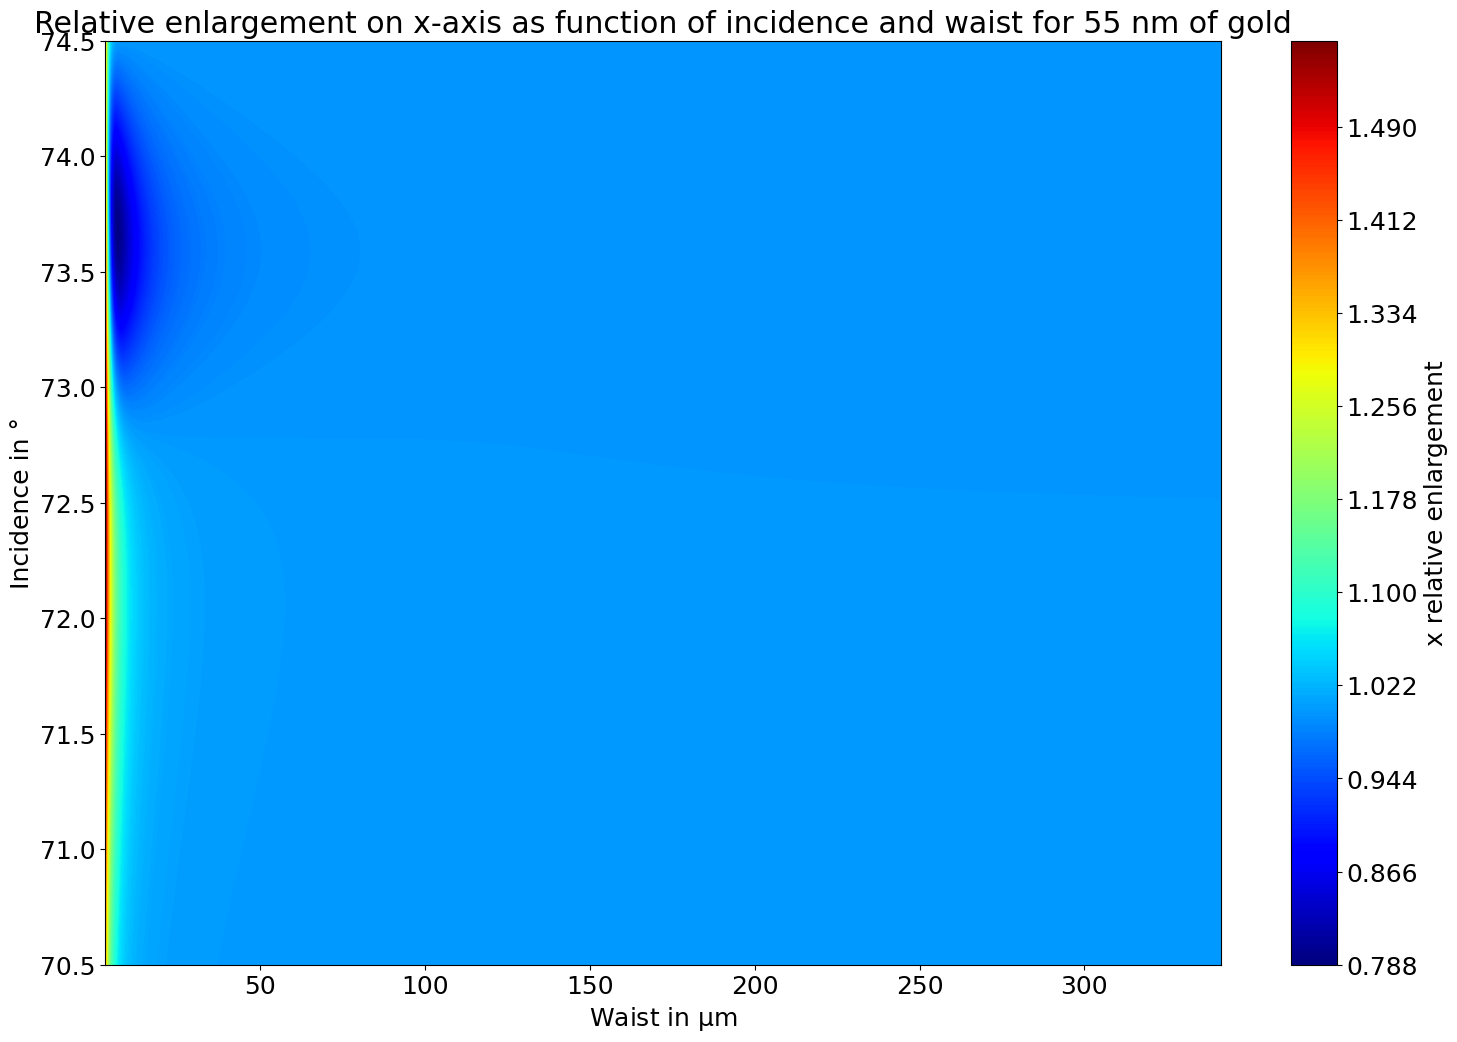

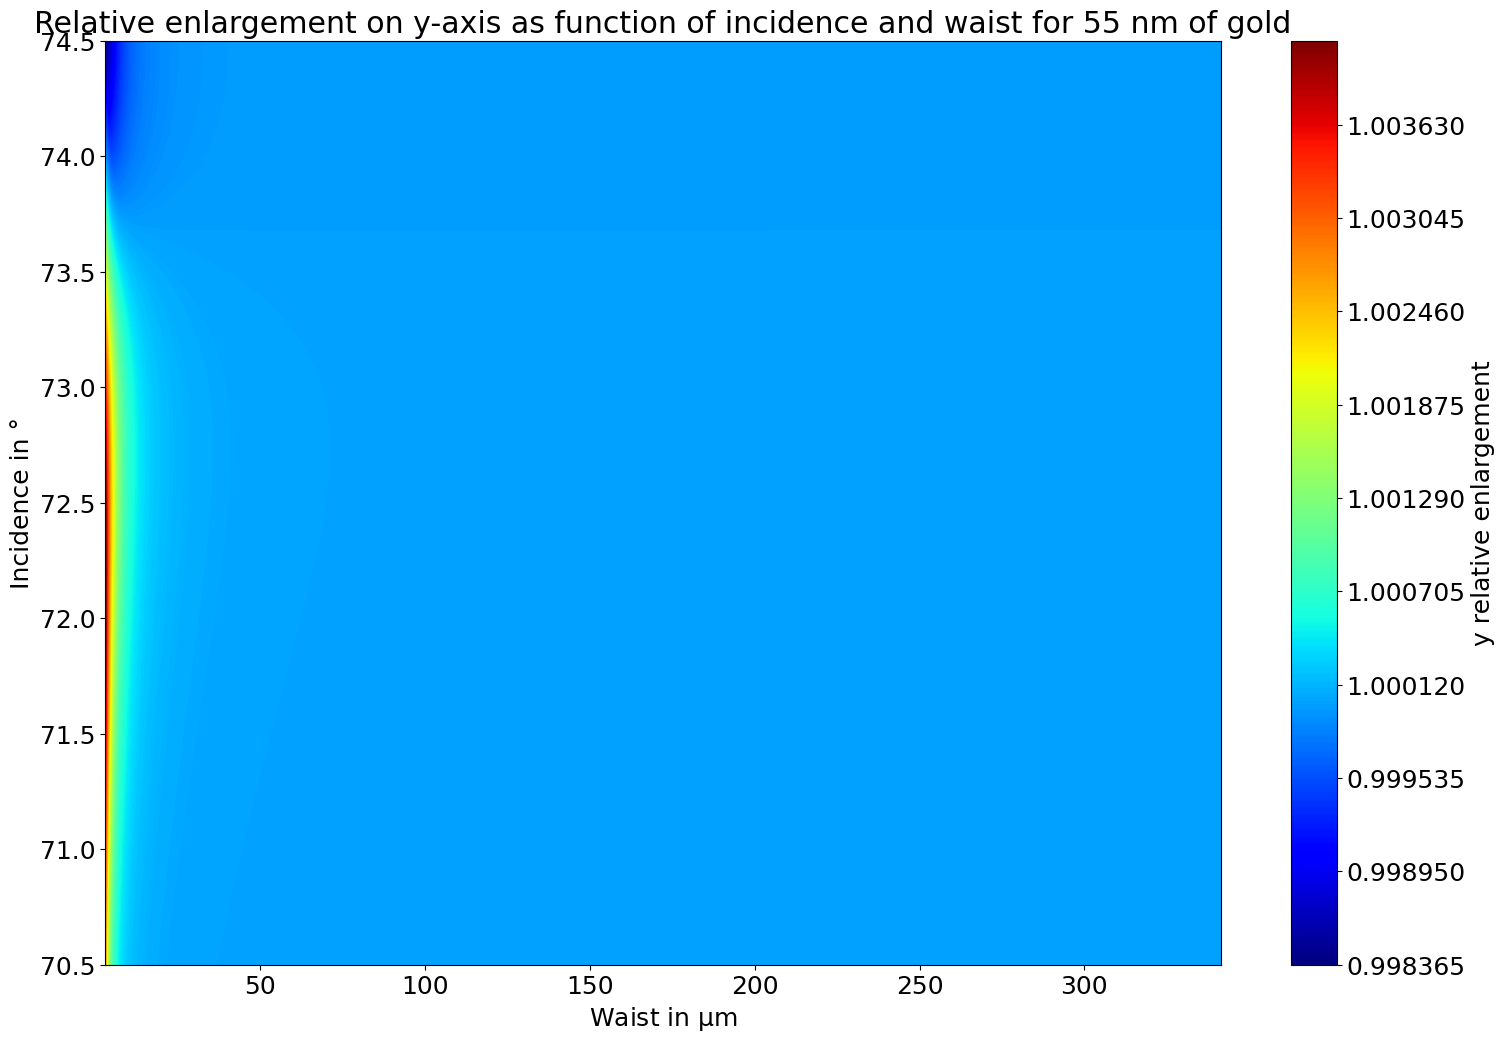

In [14]:
# function to use in multiprocessing (CPU)
def process_inc(structure, wavelength, inc, w_range, A, B, X, Y, x, y):
    k0 = 2 * np.pi / wavelength
    n2 = 1.515
    kz = np.sqrt((n2 * k0)**2 - A**2 - B**2)

    theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc)))**2 + B**2) / (n2 * k0))

    cr = np.zeros_like(A, dtype=complex)
    ELx = []
    ELy = []
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            r, t, R, T = PM.coefficient(structure, wavelength, theta[i, j], 1)
            cr[i, j] = r
    for w in w_range:
        wx=w
        wy=w
        U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0) # spatial beam before reflection
        U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
        U1ki=cr*U1k # spectral beam after reflection
        U1i=ifft2(U1ki) # spatial beam after reflection
        # determination of the barycentre of the beam on x and y for the incoming and the reflected beam
        bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
        byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
        bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
        byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
        # determination of the shift
        decx=bxU1i-bxU1
        decy=byU1i-byU1
        # determination of the enlargement (in absolute and relative form)
        elarrelatx = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
        elarrelaty = (trapezoid(trapezoid(((Y - decy)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((Y**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
        # save of the shifts and enlargements
        ELx.append(elarrelatx)
        ELy.append(elarrelaty)
        
    return inc, ELx, ELy

# initialisation of the needed parameters, other than the incidence,
n1 = 1 # air refractive index
n2 = 1.515  # glass refractive index
wavelength = 632.8
k0 = 2 * np.pi / wavelength
N = 100
alpha0 = 0
beta0 = 0
x0 = 0
y0 = 0
d = 400000

# the x and y-axes considered
x = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
y = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
# grids of the axes
X, Y = np.meshgrid(x, y)

# definition of the spectral grid
pask = 2 * np.pi / d  # definition of the spectral step
a = np.arange(-N, N + 1) * pask  # alpha (kx) range in nm-1
b = a  # beta (ky) range in nm-1
A, B = np.meshgrid(a, b)  # alpha and beta grid

ELx_best=[]
Waist_best=[]
INC_best=[]
#gold_thickness_range=np.linspace(20,55, 8) # gold thickness range to scan
gold_thickness_range=np.array([20,25,30,35,40,41,42,43,44,45,46,47,48,49,50,55]) # with more points around 45 
inc_range=np.linspace(70.5,74.5, int((74.5-70.5)/0.01)+1) # range of incidence considered
w_range = np.round(5690 * np.linspace(0.5, 60, int(np.round((60-0.5)/0.1)+1))) # range of waist considered
# gold layer thickness loop
for gold_thickness in gold_thickness_range:
    # definition of the structure on which the reflection is done
    # get the material from refractiveindex database (RII) when possible
    Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
    Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
    mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33 is for water
    stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
    thickness = [4000, 2, gold_thickness, 1000]  # thickness of each layer
    structure = PM.Structure(mat, stack, thickness, verbose=False)
    
    # parallel computation (on inc)
    results = Parallel(n_jobs=n_jobs, backend="loky")(delayed(process_inc)(structure, wavelength, inc, w_range, A, B, X, Y, x, y) for inc in tqdm(inc_range, desc="Scan of all the incidences"))
    # build the relative enlargement maps
    ELx2D = np.zeros((len(inc_range), len(w_range)))
    ELy2D = np.zeros((len(inc_range), len(w_range)))

    inc_index = {val: idx for idx, val in enumerate(inc_range)}

    for inc, ELx_row, ELy_row in results:
        i = inc_index[inc]
        ELx2D[i, :] = ELx_row
        ELy2D[i, :] = ELy_row

        
    w_grid, inc_grid = np.meshgrid(w_range, inc_range)
    fig = plt.figure(figsize=(18, 12))
    ax1 = fig.add_subplot(111)
    contour1 = ax1.contourf(w_grid/1000, inc_grid, np.array(ELx2D), levels=500, cmap="jet")
    contour1.set_edgecolor("face")
    cbar1 = fig.colorbar(contour1, ax=ax1)
    cbar1.set_label("x relative enlargement")
    ax1.set_ylabel("Incidence in °")
    ax1.set_xlabel(r"Waist in $\mathrm{\mu m}$")
    ax1.set_title(f"Relative enlargement on x-axis as function of incidence and waist for {int(gold_thickness)} nm of gold")
    if SAVE_MODE:
        for file_ext in save_formats:
            plt.savefig(f"Plots/{file_ext}/optimisation/h_Au/x_rel_enlargement_f_inc_and_w_for_h_Au_{int(gold_thickness)}.{file_ext}", bbox_inches="tight")

    fig = plt.figure(figsize=(18, 12))
    ax2 = fig.add_subplot(111)
    contour2 = ax2.contourf(w_grid/1000,inc_grid, np.array(ELy2D), levels=500, cmap="jet")
    contour2.set_edgecolor("face")
    cbar2 = fig.colorbar(contour2, ax=ax2)
    cbar2.set_label("y relative enlargement")
    ax2.set_ylabel("Incidence in °")
    ax2.set_xlabel(r"Waist in $\mathrm{\mu m}$")
    ax2.set_title(f"Relative enlargement on y-axis as function of incidence and waist for {int(gold_thickness)} nm of gold")
    if SAVE_MODE:
        for file_ext in save_formats:
            plt.savefig(f"Plots/{file_ext}/optimisation/h_Au/y_rel_enlargement_f_inc_and_w_for_h_Au_{int(gold_thickness)}.{file_ext}", bbox_inches="tight")

    index_best_inc, index_best_w = np.unravel_index(np.argmin(np.array(ELx2D)), np.array(ELx2D).shape)

    print(f"{int(gold_thickness)} nm of gold: the incidence and waist which maximize the beam narrowing are {inc_grid[index_best_inc,index_best_w]}° and {w_grid[index_best_inc,index_best_w]} nm with a relative enlargement of {np.min(ELx2D)}")
    ELx_best.append(np.min(ELx2D))
    Waist_best.append(w_grid[index_best_inc,index_best_w])
    INC_best.append(inc_grid[index_best_inc,index_best_w])



To go further in acceleration, here there is a GPU accelerated version of the previous function. As the GPU is machine related, even at the coding level we don't use this as baseline. This function is adapted to Mac ARM machines.

# equivalent function with Apple GPU acceleration (~33% faster than CPU only), at the cost to use float32 instead of float64 (this change the last digits of the results)
def process_inc_w_GPU(structure, wavelength, inc, w_range, A, B, X, Y, x, y):
    device = torch.device("mps")  # GPU Apple
    dtype = torch.float32         # MPS-compatible

    # conversion to torch tensors
    A_torch = torch.tensor(A, device=device, dtype=dtype)
    B_torch = torch.tensor(B, device=device, dtype=dtype)
    X_torch = torch.tensor(X, device=device, dtype=dtype)
    Y_torch = torch.tensor(Y, device=device, dtype=dtype)
    inc_torch = torch.tensor(inc, dtype=dtype)
    w_range = np.array(w_range, dtype=np.float32)
    W = torch.tensor(w_range[:, None, None], device=device, dtype=dtype)  # (n_w, 1, 1)
    x_np = np.array(x, dtype=np.float32)
    y_np = np.array(y, dtype=np.float32)
    k0 = torch.tensor(2 * np.pi / wavelength, dtype=dtype)
    n2 = torch.tensor(1.515, dtype=dtype)

    kz = torch.sqrt((n2 * k0)**2 - A_torch**2 - B_torch**2)
    theta = torch.arcsin(torch.sqrt((A_torch * torch.cos(torch.deg2rad(inc_torch)) +
                                     kz * torch.sin(torch.deg2rad(inc_torch)))**2 +
                                     B_torch**2) / (n2 * k0))
    theta_cpu = theta.cpu().numpy()

    cr = np.zeros_like(theta_cpu, dtype=np.complex64)
    for i in range(cr.shape[0]):
        for j in range(cr.shape[1]):
            r, _, _, _ = PM.coefficient(structure, wavelength, theta_cpu[i, j], 1)
            cr[i, j] = r
    cr_torch = torch.tensor(cr, device=device)

    # torch version of the Gaussian beam (with all the 0 quantities at 0)
    gaussians = torch.exp(-((X_torch[None, :, :]**2 + Y_torch[None, :, :]**2) / W**2))  # (n_w, H, W)
    U1k = torch.fft.fftshift(torch.fft.fftshift(torch.fft.fft2(gaussians, dim=(-2, -1)), dim=-2), dim=-1)
    cr_torch = cr_torch[None, :, :]  # (1, H, W)
    U1ki = U1k * cr_torch
    U1i = torch.fft.ifft2(U1ki, dim=(-2, -1))
    I1 = torch.abs(gaussians)**2
    I1i = torch.abs(U1i)**2

    # Transfert to CPU for integrals
    I1_np = I1.cpu().numpy()
    I1i_np = I1i.cpu().numpy()
    X_np = X_torch.cpu().numpy()
    Y_np = Y_torch.cpu().numpy()

    ELx, ELy = [], []

    for k in range(len(w_range)):
        I1k = I1_np[k]
        I1ik = I1i_np[k]
        bxU1  = trapezoid(trapezoid(X_np * I1k, x_np, axis=1), y_np) / trapezoid(trapezoid(I1k, x_np, axis=1), y_np)
        byU1  = trapezoid(trapezoid(Y_np * I1k, x_np, axis=1), y_np) / trapezoid(trapezoid(I1k, x_np, axis=1), y_np)
        bxU1i = trapezoid(trapezoid(X_np * I1ik, x_np, axis=1), y_np) / trapezoid(trapezoid(I1ik, x_np, axis=1), y_np)
        byU1i = trapezoid(trapezoid(Y_np * I1ik, x_np, axis=1), y_np) / trapezoid(trapezoid(I1ik, x_np, axis=1), y_np)
        decx = bxU1i - bxU1
        decy = byU1i - byU1
        elx = (trapezoid(trapezoid(((X_np - decx)**2) * I1ik, x_np, axis=1), y_np) /
               trapezoid(trapezoid(I1ik, x_np, axis=1), y_np)) / \
              (trapezoid(trapezoid((X_np**2) * I1k, x_np, axis=1), y_np) /
               trapezoid(trapezoid(I1k, x_np, axis=1), y_np))

        ely = (trapezoid(trapezoid(((Y_np - decy)**2) * I1ik, x_np, axis=1), y_np) /
               trapezoid(trapezoid(I1ik, x_np, axis=1), y_np)) / \
              (trapezoid(trapezoid((Y_np**2) * I1k, x_np, axis=1), y_np) /
               trapezoid(trapezoid(I1k, x_np, axis=1), y_np))
        ELx.append(elx)
        ELy.append(ely)
    return inc, ELx, ELy

Plot of the results.

The gold layer thickness that maximize the beam narrowing is 46 nm with a relative enlargement of 0.4781145917729161


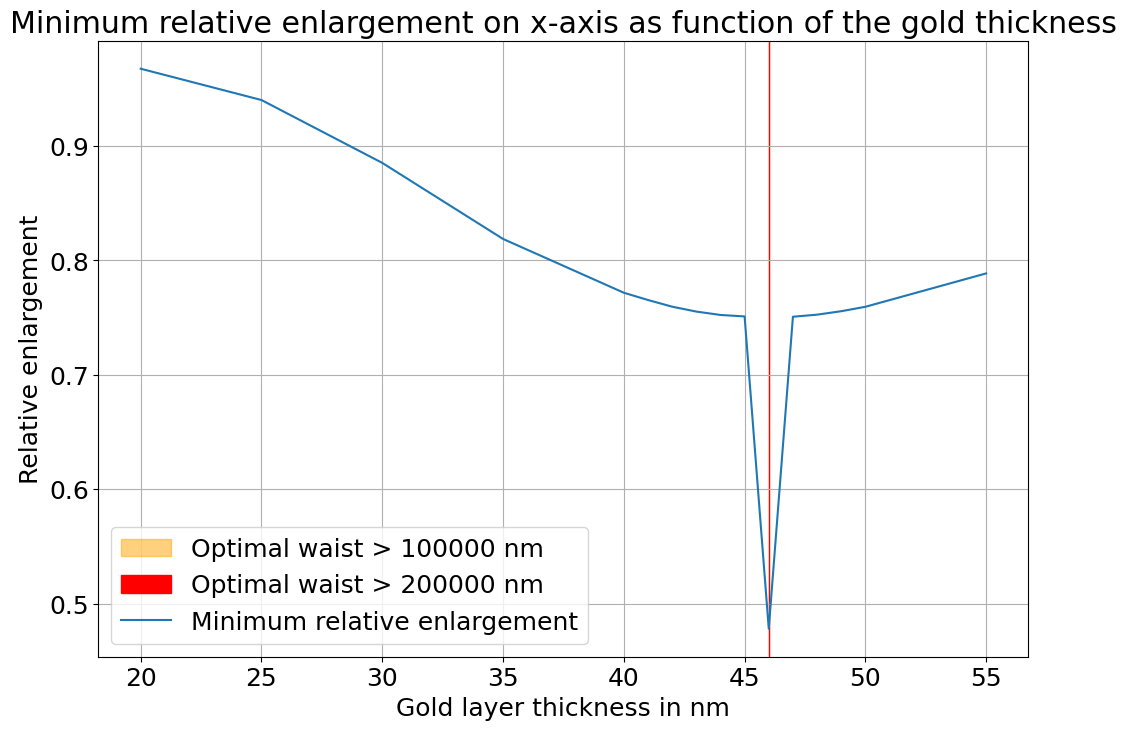

In [15]:
# to display the area where the optimal waist becomes very big
ELx_best=np.array(ELx_best)
Waist_best=np.array(Waist_best)
INC_best=np.array(INC_best)

w_over_100000_max, w_over_100000_min = np.max(gold_thickness_range[Waist_best>100000]), np.min(gold_thickness_range[Waist_best>100000])
w_over_200000_max, w_over_200000_min = np.max(gold_thickness_range[Waist_best>200000]), np.min(gold_thickness_range[Waist_best>200000])

plt.figure(figsize=(12,8))
plt.axvspan(w_over_100000_min, w_over_100000_max, color='orange', alpha=0.5, label='Optimal waist > 100000 nm')
plt.axvspan(w_over_200000_min, w_over_200000_max, color='red', alpha=1.0, label='Optimal waist > 200000 nm')
plt.plot(gold_thickness_range, ELx_best, label="Minimum relative enlargement")
plt.title(f"Minimum relative enlargement on x-axis as function of the gold thickness")
plt.xlabel("Gold layer thickness in nm")
plt.ylabel("Relative enlargement")
plt.grid()
plt.legend()
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/optimisation/x_rel_enlargement_f_h_Au.{file_ext}", bbox_inches="tight")

gold_thickness_best=gold_thickness_range[np.argmin(ELx_best)]
print(f"The gold layer thickness that maximize the beam narrowing is {gold_thickness_best} nm with a relative enlargement of {np.min(ELx_best)}")

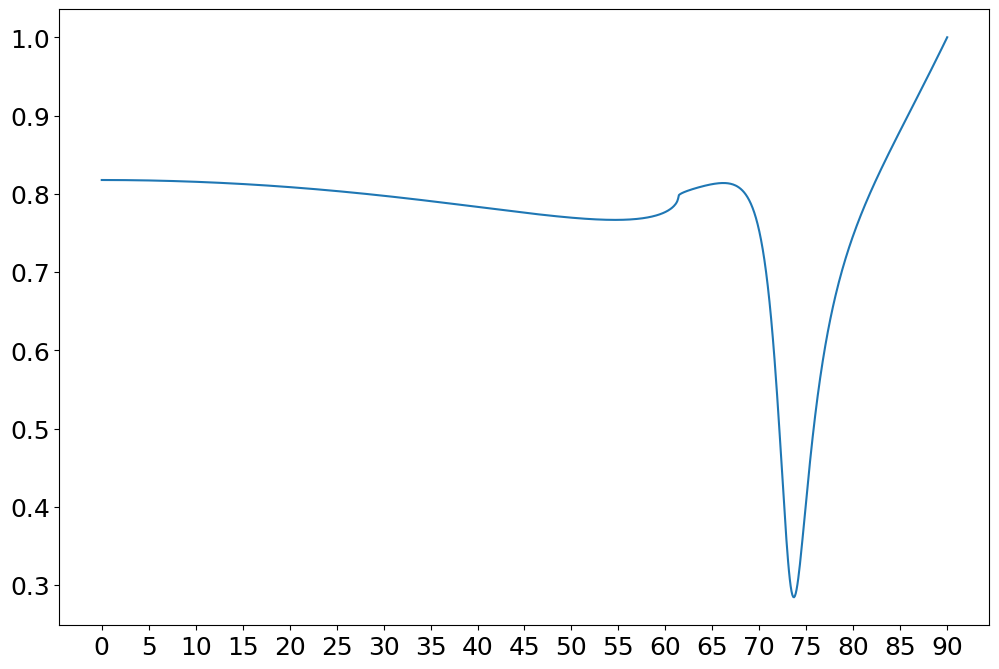

In [16]:
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, 55, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)

angle, r, t, R, T = PM.angular(structure, wavelength,1, 0, 90,1000)
plt.figure(figsize=(12,8))
plt.plot(angle, np.abs(r))
plt.xticks(np.arange(0,95,5));

# initialisation of the needed parameters, other than the incidence,
n1 = 1 # air refractive index
n2 = 1.515  # glass refractive index
wavelength = 632.8
k0 = 2 * np.pi / wavelength
N = 100
alpha0 = 0
beta0 = 0
x0 = 0
y0 = 0
d = 400000

# the x and y-axes considered
x = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
y = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
# grids of the axes
X, Y = np.meshgrid(x, y)

# definition of the spectral grid
pask = 2 * np.pi / d  # definition of the spectral step
a = np.arange(-N, N + 1) * pask  # alpha (kx) range in nm-1
b = a  # beta (ky) range in nm-1
A, B = np.meshgrid(a, b)  # alpha and beta grid

# definition of the structure on which the reflection is done
# get the material from refractiveindex database (RII) when possible
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
mat = ["BK7",Cr,Au,1]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1 is for air
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, 44, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)

inc_range=np.linspace(40,46, int((46-40)/0.05)+1) # range of incidence considered
w_range = 5690 * np.linspace(1, 50, int((50-1)/0.1)+1)  # range of waist considered
# list of the saved quantities
ELx2D=[]
ELy2D=[]

kz = ((n2 * k0) ** 2 - A**2 - B**2) ** (1 / 2)  # determination of the wave vector z component (kz or gamma) for all incident plane wave
for inc in inc_range:
    ELx=[]
    ELy=[]
    # reflection
    theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2)/ (n2 * k0))  # array with the incidence angle for all incident plane wave
    cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    # determination of the reflection coefficients for each plane wave
    for i in range(len(a)):
        for j in range(len(b)):
            r, t, R, T = PM.coefficient(structure, wavelength, theta[i,j], 1)
            cr[i, j] = r
    for w in w_range:
        wx=w
        wy=w
        U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0) # spatial beam before reflection
        U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
        U1ki=cr*U1k # spectral beam after reflection
        U1i=ifft2(U1ki) # spatial beam after reflection
        # determination of the barycentre of the beam on x and y for the incoming and the reflected beam
        bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
        byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
        bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
        byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
        # determination of the shift
        decx=bxU1i-bxU1
        decy=byU1i-byU1
        # determination of the enlargement (in absolute and relative form)
        elarrelatx = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
        elarrelaty = (trapezoid(trapezoid(((Y - decy)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((Y**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
        # save of the shifts and enlargements
        ELx.append(elarrelatx)
        ELy.append(elarrelaty)
    ELx2D.append(ELx)
    ELy2D.append(ELy)
        


w_grid, inc_grid = np.meshgrid(w_range, inc_range)

fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(111)
contour1 = ax1.contourf(w_grid, inc_grid, np.array(ELx2D), levels=500, cmap="jet")
cbar1 = fig.colorbar(contour1, ax=ax1)
cbar1.set_label("x relative enlargement")
ax1.set_ylabel("Incidence in °")
ax1.set_xlabel("Waist in nm")
ax1.set_title("Relative enlargement on x-axis as function of incidence and waist")

fig = plt.figure(figsize=(12, 8))
ax2 = fig.add_subplot(111)
contour2 = ax2.contourf(w_grid,inc_grid, np.array(ELy2D), levels=500, cmap="jet")
cbar2 = fig.colorbar(contour2, ax=ax2)
cbar2.set_label("y relative enlargement")
ax2.set_ylabel("Incidence in °")
ax2.set_xlabel("Waist in nm")
ax2.set_title("Relative enlargement on y-axis as function of incidence and waist")

index_best_w, index_best_inc = np.unravel_index(np.argmin(np.array(ELx2D)), np.array(ELx2D).shape)

print(f"The incidence and waist which maximize the beam narrowing are {inc_grid[index_best_w,index_best_inc]}° and {w_grid[index_best_w,index_best_inc]} nm with a relative enlargement of {np.min(ELx2D)}")

# initialisation of the needed parameters, other than the waists, 
n1 = 1 # air refractive index
n2 = 1.515  # glass refractive index
wavelength = 632.8
k0 = 2 * np.pi / wavelength
N = 100
alpha0 = 0
beta0 = 0
x0 = 0
y0 = 0
inc = 44.28
d = 400000

# the x and y-axes considered
x = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
y = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
# grids of the axes
X, Y = np.meshgrid(x, y)

# definition of the spectral grid
pask = 2 * np.pi / d  # definition of the spectral step
a = np.arange(-N, N + 1) * pask  # alpha (kx) range in nm-1
b = a  # beta (ky) range in nm-1
A, B = np.meshgrid(a, b)  # alpha and beta grid

# reflection
kz = ((n2 * k0) ** 2 - A**2 - B**2) ** (1 / 2)  # determination of the wave vector z component (kz or gamma) for all incident plane wave
theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2)/ (n2 * k0))  # array with the incidence angle for all incident plane wave
cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)  # initialisation of the array of reflection coefficient for all incident plane wave, with complexe numbers
# definition of the structure on which the reflection is done
# get the material from refractiveindex database (RII) when possible
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
mat = ["BK7",Cr,Au,1]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1 is for air
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, 44, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)
# determination of the reflection coefficients for each plane wave
for i in range(len(a)):
    for j in range(len(b)):
        r, t, R, T = PM.coefficient(structure, wavelength, theta[i,j], 1)
        cr[i, j] = r

angle, r, t, R, T = PM.angular(structure, wavelength,1, 0, 80,1000)
plt.figure(figsize=(12,8))
plt.plot(angle, np.abs(r))


cr1D = cr[N,:]

plt.figure(figsize=(12,8))
plt.plot(a,np.abs(cr1D))
plt.title(fr"Reflection coefficient module in $k_x$ plane (for a central incidence of {inc}°)")
plt.xlabel(r"$\alpha$ in $\mathrm{nm}^{-1}$")
plt.ylabel(fr"Module of the reflection coefficient")
plt.grid()
plt.xlim(-0.001,0.001);

fig=plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A, B, np.abs(cr), cmap='hsv', edgecolor='none',rcount=2*N+1,ccount=2*N+1,vmin=np.min(abs(cr)),vmax=np.max(abs(cr)))
col=fig.colorbar(surf)
ax.set_xlabel(r"$\alpha$ in $\mathrm{nm}^{-1}$")
ax.set_ylabel(r"$\beta$ in $\mathrm{nm}^{-1}$")
col.set_label("Module of the reflection coefficient")
ax.set_title(fr"Reflection coefficient module (for a central incidence of {inc}°)");

U1 = my_mod.gauss2D(X, Y, 50000, 50000, x0, y0, alpha0, beta0) # spatial beam before reflection
U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
U1ki=cr*U1k # spectral beam after reflection
U1i=ifft2(U1ki) # spatial beam after reflection

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)
contour = ax.contourf(X, Y, np.abs(U1), levels=500, cmap="jet")
cbar = fig.colorbar(contour)
cbar.set_label("Magnetic field module")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title("Magnetic field module before reflection")

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)
contour = ax.contourf(X, Y, np.abs(U1i), levels=500, cmap="jet")
cbar = fig.colorbar(contour)
cbar.set_label("Magnetic field module")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title("Magnetic field module after reflection");


